In [ ]:
# •	File name: Hybrid ANN-CNN K-fold Surrogate model
# •	Author: Ehsan Akbari
# •	Affiliation: University of Waterloo, PhD student.

In [7]:
import os
print("Current directory:", os.getcwd())  # Output: e.g., `/home/user/notebooks`


Current directory: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold


In [6]:
# Change the directory
os.chdir("C:/Users/e3akbari/Desktop/ML_test/ANN_K-fold")  # Change directory
#print("New directory:", os.getcwd())

In [8]:
####Imports and Configuration
### =============================================================================
### STEP 1: CONFIGURATION & GLOBAL SETTINGS
### =============================================================================
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
import warnings
warnings.filterwarnings("ignore")

# SIMPLE CONFIGURATION (no class)
OUTPUT_DIR = Path(".").absolute() / "output -second try"
INPUTS_FILE = OUTPUT_DIR / "input_parameters.csv"
ANNUAL_FILE = OUTPUT_DIR / "dataout.csv"
HOURLY_H5_FILE = OUTPUT_DIR / "hourly_data_3d.h5"

# File paths for saving
NORM_JSON = OUTPUT_DIR / "norm_params.json"
MODEL_FILE = OUTPUT_DIR / "unified_model_complete.pth"
MODEL_INFO = OUTPUT_DIR / "model_info.json"
TRAINING_HISTORY = OUTPUT_DIR / "training_history.json"
METRICS_FILE = OUTPUT_DIR / "performance_metrics.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

PARAM_NAMES_EXPECTED = [
    "Area", "Aspect_Ratio", "window_u", "window_shgc", "Direction",
    "Wall_R", "Roof_R", "Infiltration", "WWR", "LPD", "EPD", "N_of_Fl"
]

INPUT_RANGES = {
    "Area": [404, 4000],
    "Aspect_Ratio": [0.3, 1],
    "window_u": [0.57, 1.95],
    "window_shgc": [0.25, 0.7],
    "Direction": [0, 180],
    "Wall_R": [0.145, 0.363],
    "Roof_R": [0.12, 0.36],
    "Infiltration": [0.000028, 0.0003],
    "WWR": [0.15, 0.55],
    "LPD": [2, 8],
    "EPD": [3, 20],
    "N_of_Fl": [0, 10]
}

ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]

# Set seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Configuration loaded successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Using device: {DEVICE}")

Configuration loaded successfully!
Output directory: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try
Using device: cpu


In [9]:
### STEP 2: DATA LOADING
### =============================================================================
def load_data_files():
    """Load all data files from disk"""
    print("Loading data files...")
    
    inputs_df = pd.read_csv(INPUTS_FILE)
    annual_df = pd.read_csv(ANNUAL_FILE)

    # Rename columns for consistency
    rename_map = {"Window_U": "window_u", "Window_SHGC": "window_shgc"}
    inputs_df = inputs_df.rename(columns=rename_map)

    with h5py.File(HOURLY_H5_FILE, "r") as f:
        ds_name = list(f.keys())[0]
        hourly_3d = f[ds_name][:]

    hourly_3d = hourly_3d / 3.6e6  # convert J→kWh
    print(f"✓ Loaded: inputs {inputs_df.shape}, annual {annual_df.shape}, hourly {hourly_3d.shape}")
    
    return inputs_df, annual_df, hourly_3d

print("STEP 2: LOADING DATA")
inputs_df, annual_df, hourly_3d = load_data_files()

STEP 2: LOADING DATA
Loading data files...
✓ Loaded: inputs (3000, 12), annual (3000, 4), hourly (3000, 365, 24)


In [10]:
### STEP 3: NORMALIZATION
### =============================================================================
def normalize_input_data(df):
    """Normalize inputs using predefined ranges"""
    df_norm = df.copy()
    for col in PARAM_NAMES_EXPECTED:
        vmin, vmax = INPUT_RANGES[col]
        df_norm[col] = (df_norm[col] - vmin) / (vmax - vmin)
    return df_norm

def calculate_output_ranges(annual_df, hourly_3d):
    """Calculate normalization ranges separately for each annual output"""
    annual_ranges = {}
    for col in ANNUAL_COLS:
        annual_ranges[f"{col}_min"] = float(annual_df[col].min())
        annual_ranges[f"{col}_max"] = float(annual_df[col].max())
    
    hourly_min = float(np.min(hourly_3d))
    hourly_max = float(np.max(hourly_3d))
    
    return annual_ranges, hourly_min, hourly_max

def normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max):
    """Normalize outputs using separate ranges for each annual output"""
    ann_norm = annual_df[ANNUAL_COLS].copy()
    
    # Normalize each annual output separately
    for col in ANNUAL_COLS:
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        ann_norm[col] = (ann_norm[col] - vmin) / (vmax - vmin)
    
    # Normalize hourly data
    hourly_norm = (hourly_3d - hourly_min) / (hourly_max - hourly_min)
    
    return ann_norm, hourly_norm

def save_normalization_parameters(annual_ranges, hourly_min, hourly_max):
    """Save all normalization parameters for later use"""
    norm_data = {
        "input_ranges": INPUT_RANGES,
        "annual_ranges": annual_ranges,
        "hourly_min": hourly_min,
        "hourly_max": hourly_max,
        "param_names": PARAM_NAMES_EXPECTED,
        "annual_cols": ANNUAL_COLS
    }
    
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    with open(NORM_JSON, "w") as f:
        json.dump(norm_data, f, indent=4)
    print(f"✓ Normalization parameters saved to {NORM_JSON}")

print("STEP 3: NORMALIZATION")
inputs_norm = normalize_input_data(inputs_df)
annual_ranges, hourly_min, hourly_max = calculate_output_ranges(annual_df, hourly_3d)
ann_norm_df, hourly_norm = normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max)
save_normalization_parameters(annual_ranges, hourly_min, hourly_max)

# Prepare arrays for training
X = inputs_norm[PARAM_NAMES_EXPECTED].values.astype(np.float32)
Y_ann = ann_norm_df[ANNUAL_COLS].values.astype(np.float32)
Y_hour = hourly_norm.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"Y_ann shape: {Y_ann.shape}")
print(f"Y_hour shape: {Y_hour.shape}")

STEP 3: NORMALIZATION
✓ Normalization parameters saved to C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try\norm_params.json
X shape: (3000, 12)
Y_ann shape: (3000, 3)
Y_hour shape: (3000, 365, 24)


In [6]:
### STEP 4: DATA SPLIT FOR OPTUNA
### =============================================================================
def split_data_for_optuna(X, Y_ann, Y_hour, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split data for Optuna hyperparameter tuning
    Returns: X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val
    """
    print("Splitting data for Optuna tuning...")
    
    # First split: separate test set
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    # Second split: train/validation from remaining data
    X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val = train_test_split(
        X_temp, y_ann_temp, y_hour_temp, test_size=val_size, random_state=random_state
    )
    
    print(f"✓ Data split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    
    return X_train, X_val, y_ann_train, y_ann_val, y_hour_train, y_hour_val

print("STEP 4: DATA SPLIT FOR OPTUNA")
X_train_opt, X_val_opt, y_ann_train_opt, y_ann_val_opt, y_hour_train_opt, y_hour_val_opt = split_data_for_optuna(X, Y_ann, Y_hour)

STEP 4: DATA SPLIT FOR OPTUNA
Splitting data for Optuna tuning...
✓ Data split - Train: 2167, Val: 383, Test: 450


In [11]:
## STEP 5: MODEL ARCHITECTURE= ANN
### =============================================================================
# Define the model architecture first
class UnifiedNet(nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
        super().__init__()
        self.day, self.hour = 365, 24
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, latent_dim), nn.ReLU()
        )
        self.fc_to_map = nn.Linear(latent_dim, self.day * self.hour)
        self.conv_decoder = nn.Sequential(
            nn.Conv2d(1, conv_channels, 3, padding=1), nn.ReLU(),
            nn.Conv2d(conv_channels, conv_channels, 3, padding=1), nn.ReLU(),
            nn.Conv2d(conv_channels, 1, 1)
        )
        self.ann_head = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, ann_out)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
        h = self.conv_decoder(h)
        ann = self.ann_head(z)
        return ann, h

# Define the Dataset class
class BuildingDataset(Dataset):
    def __init__(self, X, Y_ann, Y_hour):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y_ann = torch.tensor(Y_ann, dtype=torch.float32)
        self.Y_hour = torch.tensor(Y_hour[:, None, :, :], dtype=torch.float32)
    
    def __len__(self): 
        return len(self.X)
    
    def __getitem__(self, idx): 
        return self.X[idx], self.Y_ann[idx], self.Y_hour[idx]

print("✓ Model architecture defined")

✓ Model architecture defined


In [8]:
## STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION
### =============================================================================

def run_optuna_optimization(X_train, y_ann_train, y_hour_train, 
                          X_val, y_ann_val, y_hour_val, 
                          n_trials=5, timeout=600):
    """
    Run Optuna hyperparameter optimization
    """
    print("Starting Optuna hyperparameter optimization...")
    
    def objective(trial):
        # Suggest hyperparameters
        latent_dim = trial.suggest_categorical("latent_dim", [64, 128, 256, 512])
        conv_channels = trial.suggest_categorical("conv_channels", [8, 16, 32, 64])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        wd = trial.suggest_float("wd", 1e-6, 1e-4, log=True)
        w_hour = trial.suggest_float("w_hour", 0.1, 2.0)
        
        # Create model and optimizer
        model = UnifiedNet(
            in_dim=X_train.shape[1], 
            latent_dim=latent_dim, 
            conv_channels=conv_channels, 
            ann_out=y_ann_train.shape[1]
        ).to(DEVICE)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        criterion = nn.MSELoss()
        
        # Create data loaders
        train_loader = DataLoader(
            BuildingDataset(X_train, y_ann_train, y_hour_train), 32, True
        )
        val_loader = DataLoader(
            BuildingDataset(X_val, y_ann_val, y_hour_val), 32, False
        )
        
        # Short training and validation
        best_val_loss = float('inf')
        for epoch in range(10):  # Reduced epochs for faster tuning
            # Training
            model.train()
            for X_batch, y_ann_batch, y_hour_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_ann_batch = y_ann_batch.to(DEVICE)
                y_hour_batch = y_hour_batch.to(DEVICE)
                
                optimizer.zero_grad()
                pred_ann, pred_hour = model(X_batch)
                loss_ann = criterion(pred_ann, y_ann_batch)
                loss_hour = criterion(pred_hour, y_hour_batch)
                total_loss = loss_ann + w_hour * loss_hour
                total_loss.backward()
                optimizer.step()
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for X_batch, y_ann_batch, y_hour_batch in val_loader:
                    X_batch = X_batch.to(DEVICE)
                    y_ann_batch = y_ann_batch.to(DEVICE)
                    y_hour_batch = y_hour_batch.to(DEVICE)
                    
                    pred_ann, pred_hour = model(X_batch)
                    loss_ann = criterion(pred_ann, y_ann_batch)
                    loss_hour = criterion(pred_hour, y_hour_batch)
                    total_loss = loss_ann + w_hour * loss_hour
                    val_loss += total_loss.item() * X_batch.size(0)
            
            val_loss /= len(val_loader.dataset)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
        
        return best_val_loss
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, timeout=timeout)
    
    print("✓ Optuna optimization completed!")
    print(f"Best hyperparameters: {study.best_params}")
    print(f"Best validation loss: {study.best_value:.6f}")
    
    return study.best_params

print("STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION")
best_params = run_optuna_optimization(
    X_train_opt, y_ann_train_opt, y_hour_train_opt,
    X_val_opt, y_ann_val_opt, y_hour_val_opt,
    n_trials=10, timeout=1200
)

[I 2025-10-22 18:54:57,368] A new study created in memory with name: no-name-fea4d104-28b1-495b-8858-ac7db4ac6f88


STEP 6: OPTUNA HYPERPARAMETER OPTIMIZATION
Starting Optuna hyperparameter optimization...


[I 2025-10-22 18:56:30,227] Trial 0 finished with value: 0.0008589411437068883 and parameters: {'latent_dim': 256, 'conv_channels': 32, 'lr': 0.0003187766236429252, 'wd': 4.5576122509661004e-05, 'w_hour': 1.8998117210304946}. Best is trial 0 with value: 0.0008589411437068883.
[I 2025-10-22 18:57:16,957] Trial 1 finished with value: 0.00027131751500673147 and parameters: {'latent_dim': 128, 'conv_channels': 16, 'lr': 0.004622801841988663, 'wd': 1.7319625280131522e-06, 'w_hour': 0.31555395666916203}. Best is trial 1 with value: 0.00027131751500673147.
[I 2025-10-22 18:58:47,591] Trial 2 finished with value: 0.0011497801157594816 and parameters: {'latent_dim': 256, 'conv_channels': 32, 'lr': 0.00013515591880478177, 'wd': 1.2216200380049677e-05, 'w_hour': 0.7313282248865455}. Best is trial 1 with value: 0.00027131751500673147.
[I 2025-10-22 18:59:42,743] Trial 3 finished with value: 0.0003901152462271764 and parameters: {'latent_dim': 512, 'conv_channels': 16, 'lr': 0.0008197750457374982, 

✓ Optuna optimization completed!
Best hyperparameters: {'latent_dim': 128, 'conv_channels': 16, 'lr': 0.004622801841988663, 'wd': 1.7319625280131522e-06, 'w_hour': 0.31555395666916203}
Best validation loss: 0.000271


In [9]:
### STEP 6.5: K-FOLD DATA SPLITTING FOR FINAL MODEL
### =============================================================================

def create_kfold_splits(X, Y_ann, Y_hour, n_splits=5, test_size=0.15, random_state=42):
    """
    Create k-fold splits for final model training
    Returns: List of (train_idx, val_idx) for each fold + test set
    """
    from sklearn.model_selection import KFold, train_test_split
    
    print(f"Creating {n_splits}-fold cross-validation splits...")
    
    # First, separate test set (same for all folds)
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    print(f"Total data: {X.shape[0]}")
    print(f"Training/Validation data: {X_temp.shape[0]}")
    print(f"Test data: {X_test.shape[0]}")
    
    # Create k-fold splits on the temporary data (no test set)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_splits = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_temp)):
        fold_splits.append((train_idx, val_idx))
        print(f"  Fold {fold+1}: Train={len(train_idx)}, Val={len(val_idx)}")
    
    # Return everything needed
    test_data = (X_test, y_ann_test, y_hour_test)
    temp_data = (X_temp, y_ann_temp, y_hour_temp)
    
    return fold_splits, test_data, temp_data

# Configuration - YOU CAN CHANGE THIS VALUE
K_FOLDS = 5

print("STEP 6.5: K-FOLD DATA SPLITTING")
fold_splits, test_data, temp_data = create_kfold_splits(X, Y_ann, Y_hour, n_splits=K_FOLDS)
X_test_final, y_ann_test_final, y_hour_test_final = test_data
X_temp, y_ann_temp, y_hour_temp = temp_data

print(f"✓ Created {K_FOLDS}-fold splits")
print(f"✓ Training/Validation data: {X_temp.shape[0]} samples")
print(f"✓ Test set: {X_test_final.shape[0]} samples")

STEP 6.5: K-FOLD DATA SPLITTING
Creating 5-fold cross-validation splits...
Total data: 3000
Training/Validation data: 2550
Test data: 450
  Fold 1: Train=2040, Val=510
  Fold 2: Train=2040, Val=510
  Fold 3: Train=2040, Val=510
  Fold 4: Train=2040, Val=510
  Fold 5: Train=2040, Val=510
✓ Created 5-fold splits
✓ Training/Validation data: 2550 samples
✓ Test set: 450 samples


In [12]:
def train_one_epoch_with_metrics(model, train_loader, optimizer, criterion, device, w_hour):
    """Train for one epoch and return detailed losses"""
    model.train()
    total_loss = 0.0
    annual_loss = 0.0
    hourly_loss = 0.0
    num_batches = 0
    
    for X_batch, y_ann_batch, y_hour_batch in train_loader:
        X_batch = X_batch.to(device)
        y_ann_batch = y_ann_batch.to(device)
        y_hour_batch = y_hour_batch.to(device)
        
        optimizer.zero_grad()
        pred_ann, pred_hour = model(X_batch)
        
        loss_ann = criterion(pred_ann, y_ann_batch)
        loss_hour = criterion(pred_hour, y_hour_batch)
        total_batch_loss = loss_ann + w_hour * loss_hour
        
        total_batch_loss.backward()
        optimizer.step()
        
        total_loss += total_batch_loss.item()
        annual_loss += loss_ann.item()
        hourly_loss += loss_hour.item()
        num_batches += 1
    
    # Return average losses
    return total_loss / num_batches, annual_loss / num_batches, hourly_loss / num_batches

def evaluate_with_metrics(model, data_loader, criterion, device, w_hour):
    """Evaluate model and return detailed losses"""
    model.eval()
    total_loss = 0.0
    annual_loss = 0.0
    hourly_loss = 0.0
    num_samples = 0
    
    with torch.no_grad():
        for X_batch, y_ann_batch, y_hour_batch in data_loader:
            X_batch = X_batch.to(device)
            y_ann_batch = y_ann_batch.to(device)
            y_hour_batch = y_hour_batch.to(device)
            
            pred_ann, pred_hour = model(X_batch)
            
            loss_ann = criterion(pred_ann, y_ann_batch)
            loss_hour = criterion(pred_hour, y_hour_batch)
            total_batch_loss = loss_ann + w_hour * loss_hour
            
            batch_size = X_batch.size(0)
            total_loss += total_batch_loss.item() * batch_size
            annual_loss += loss_ann.item() * batch_size
            hourly_loss += loss_hour.item() * batch_size
            num_samples += batch_size
    
    # Return average losses
    return {
        'total_loss': total_loss / num_samples,
        'annual_loss': annual_loss / num_samples,
        'hourly_loss': hourly_loss / num_samples
    }

In [19]:
# def evaluate_ensemble_model(ensemble_model, X_test, y_ann_test, y_hour_test):
#     """Evaluate ensemble model on test set"""
#     print("Evaluating ensemble model on test set...")
    
#     # Create test dataset and loader
#     test_dataset = BuildingDataset(X_test, y_ann_test, y_hour_test)
#     test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
#     ensemble_model.eval()
    
#     all_ann_true = []
#     all_ann_pred = []
#     all_hour_true = []
#     all_hour_pred = []
    
#     with torch.no_grad():
#         for X, y_ann, y_hour in test_loader:
#             X = X.to(DEVICE)
            
#             # Use forward method directly
#             pred_ann, pred_hour = ensemble_model(X)  # Changed from predict to direct call
            
#             all_ann_true.append(y_ann.numpy())
#             all_ann_pred.append(pred_ann.cpu().numpy())
#             all_hour_true.append(y_hour.numpy())
#             all_hour_pred.append(pred_hour.cpu().numpy())
    
#     # Stack all predictions
#     ann_true = np.vstack(all_ann_true)
#     ann_pred = np.vstack(all_ann_pred)
#     hour_true = np.vstack(all_hour_true)
#     hour_pred = np.vstack(all_hour_pred)
    
#     return ann_true, ann_pred, hour_true, hour_pred

STEP 7: K-FOLD ENSEMBLE MODEL TRAINING (DETAILED LOSS TRACKING)
Training 5-fold ensemble models with detailed loss tracking...

TRAINING ENSEMBLE MODEL - FOLD 1/5
Fold 1 - Train: 2040, Val: 510
Fold 1, Epoch   1: Train=[Total:0.0144 Ann:0.0127 Hour:0.0054] Val=[Total:0.0022 Ann:0.0014 Hour:0.0023]
  → New best model saved! (val_loss: 0.002152)
Fold 1, Epoch   2: Train=[Total:0.0013 Ann:0.0010 Hour:0.0009] Val=[Total:0.0010 Ann:0.0008 Hour:0.0005]
  → New best model saved! (val_loss: 0.000986)
Fold 1, Epoch   3: Train=[Total:0.0009 Ann:0.0007 Hour:0.0005] Val=[Total:0.0009 Ann:0.0008 Hour:0.0003]
  → New best model saved! (val_loss: 0.000901)
Fold 1, Epoch   4: Train=[Total:0.0007 Ann:0.0005 Hour:0.0005] Val=[Total:0.0009 Ann:0.0007 Hour:0.0004]
  → New best model saved! (val_loss: 0.000871)
Fold 1, Epoch   5: Train=[Total:0.0005 Ann:0.0004 Hour:0.0003] Val=[Total:0.0006 Ann:0.0006 Hour:0.0002]
  → New best model saved! (val_loss: 0.000626)
Fold 1, Epoch   6: Train=[Total:0.0005 Ann:0.0

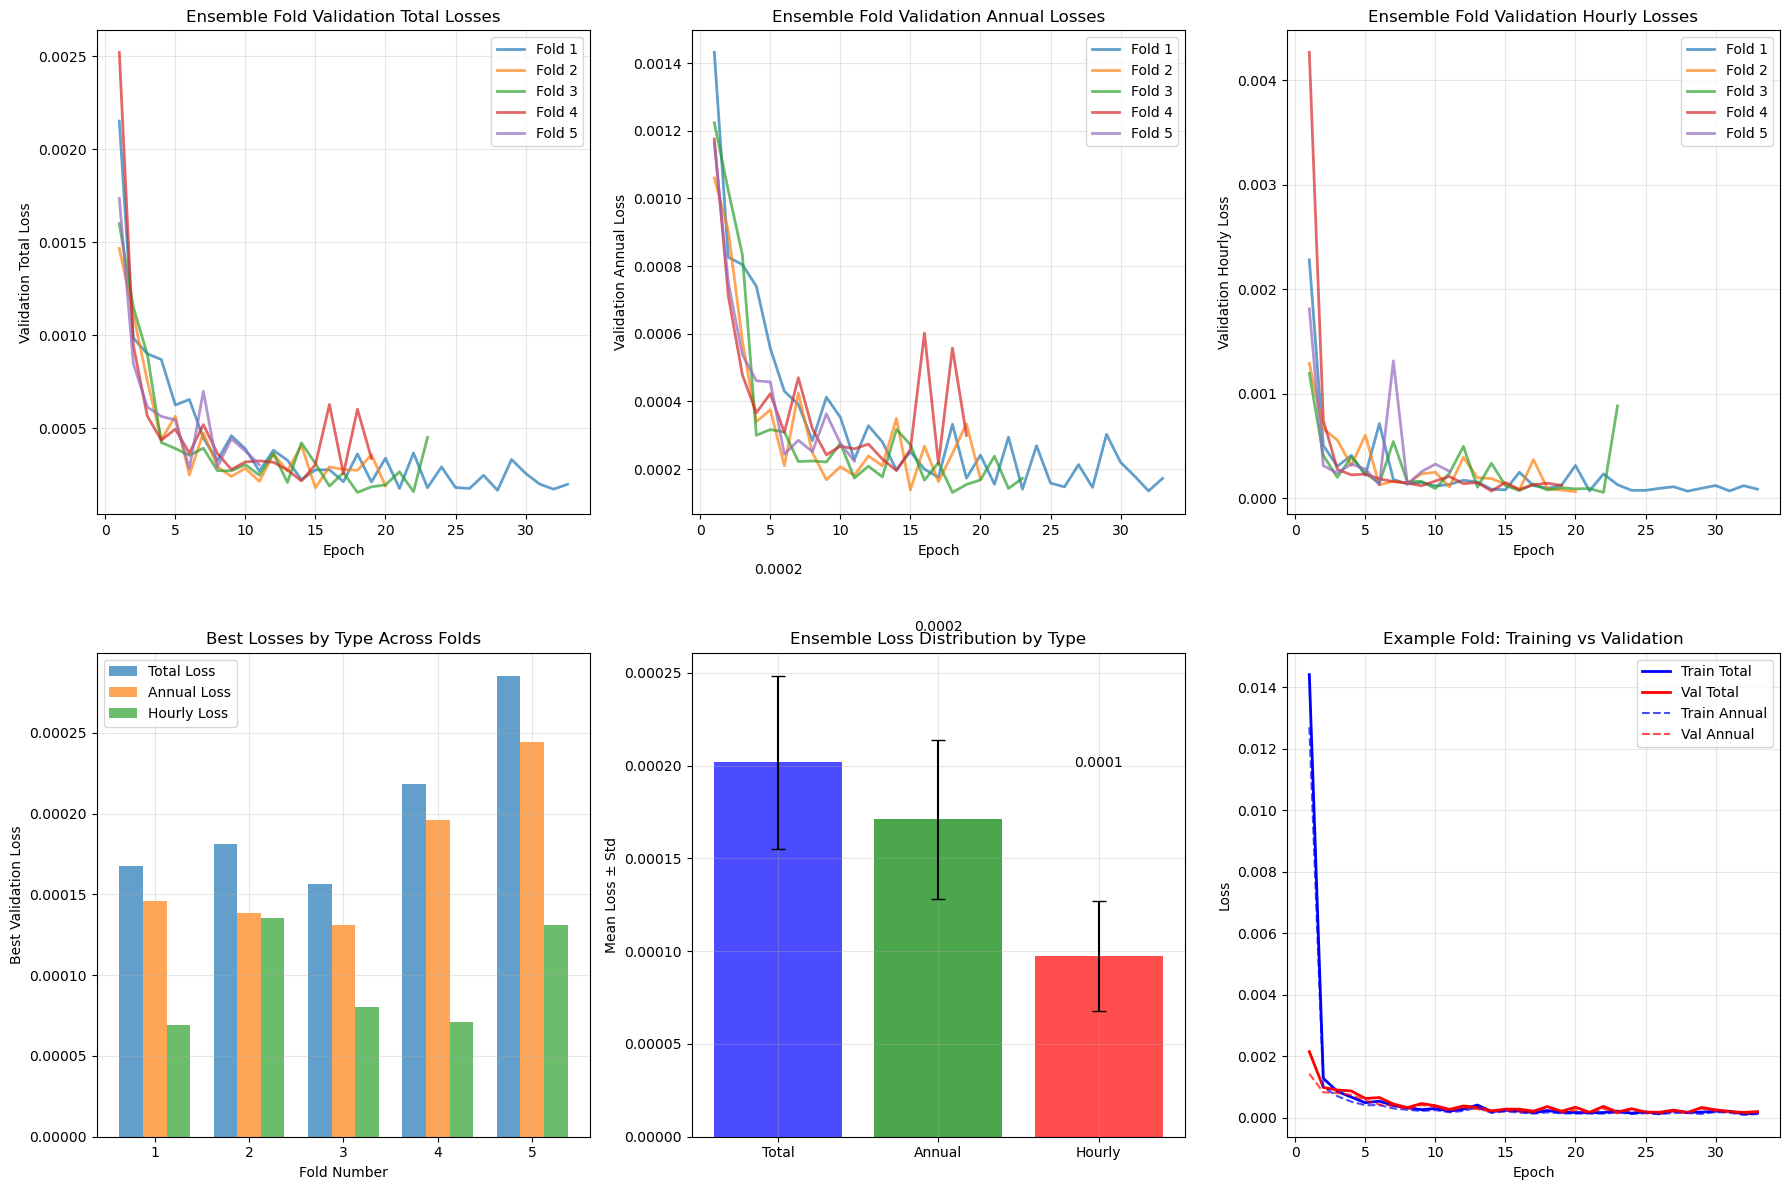


DETAILED ENSEMBLE MODEL SUMMARY
Fold   Best Total Loss Best Annual Loss Best Hourly Loss Best Epoch
--------------------------------------------------------------------------------
1      0.000168        0.000146        0.000069        28        
2      0.000181        0.000138        0.000135        15        
3      0.000156        0.000131        0.000080        18        
4      0.000218        0.000196        0.000071        14        
5      0.000285        0.000244        0.000131        6         
--------------------------------------------------------------------------------
Mean   0.000202        0.000171        0.000097       
Std    0.000047        0.000043        0.000030       


In [15]:
### STEP 7: K-FOLD FINAL MODEL TRAINING (ENSEMBLE APPROACH: Average predictions from all k models)
### =================================================================================================
# STEP 7: K-FOLD ENSEMBLE MODEL TRAINING (WITH DETAILED LOSS TRACKING)

def train_kfold_ensemble_detailed(X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params, 
                                 max_epochs=100, patience=7, k_folds=5):
    """
    Train ensemble of models using k-fold cross-validation with detailed loss tracking
    """
    print(f"Training {k_folds}-fold ensemble models with detailed loss tracking...")
    
    all_models = []
    kfold_history = {
        'fold_losses': [],
        'ensemble_performance': {}
    }
    
    # Train each fold model
    for fold, (train_idx, val_idx) in enumerate(fold_splits):
        print(f"\n{'='*50}")
        print(f"TRAINING ENSEMBLE MODEL - FOLD {fold+1}/{k_folds}")
        print(f"{'='*50}")
        
        # Get fold data
        X_train_fold = X_temp[train_idx]
        y_ann_train_fold = y_ann_temp[train_idx]
        y_hour_train_fold = y_hour_temp[train_idx]
        
        X_val_fold = X_temp[val_idx]
        y_ann_val_fold = y_ann_temp[val_idx]
        y_hour_val_fold = y_hour_temp[val_idx]
        
        print(f"Fold {fold+1} - Train: {X_train_fold.shape[0]}, Val: {X_val_fold.shape[0]}")
        
        # Initialize model for this fold
        model = UnifiedNet(
            in_dim=X_train_fold.shape[1], 
            latent_dim=best_params["latent_dim"],
            conv_channels=best_params["conv_channels"], 
            ann_out=y_ann_train_fold.shape[1]
        ).to(DEVICE)
        
        optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=best_params["lr"], 
            weight_decay=best_params["wd"]
        )
        criterion = nn.MSELoss()
        w_hour = best_params["w_hour"]
        
        # Create data loaders for this fold
        train_loader = DataLoader(
            BuildingDataset(X_train_fold, y_ann_train_fold, y_hour_train_fold), 32, True
        )
        val_loader = DataLoader(
            BuildingDataset(X_val_fold, y_ann_val_fold, y_hour_val_fold), 32, False
        )
        
        # Train this fold model with detailed tracking
        fold_history = {
            'epoch': [],
            'train_total_loss': [], 'train_annual_loss': [], 'train_hourly_loss': [],
            'val_total_loss': [], 'val_annual_loss': [], 'val_hourly_loss': [],
            'best_epoch': 0,
            'best_val_loss': float('inf'),
            'best_val_annual_loss': float('inf'),
            'best_val_hourly_loss': float('inf')
        }
        
        best_val_loss = float('inf')
        best_val_annual_loss = float('inf')
        best_val_hourly_loss = float('inf')
        no_improvement_count = 0
        best_model_state = None
        
        for epoch in range(max_epochs):
            # Training with detailed losses
            train_total, train_annual, train_hourly = train_one_epoch_with_metrics(
                model, train_loader, optimizer, criterion, DEVICE, w_hour
            )
            
            # Validation with detailed losses
            val_results = evaluate_with_metrics(model, val_loader, criterion, DEVICE, w_hour)
            
            # Store detailed history
            fold_history['epoch'].append(epoch + 1)
            fold_history['train_total_loss'].append(float(train_total))
            fold_history['train_annual_loss'].append(float(train_annual))
            fold_history['train_hourly_loss'].append(float(train_hourly))
            fold_history['val_total_loss'].append(float(val_results['total_loss']))
            fold_history['val_annual_loss'].append(float(val_results['annual_loss']))
            fold_history['val_hourly_loss'].append(float(val_results['hourly_loss']))
            
            # Print detailed progress (same format as single model)
            print(f"Fold {fold+1}, Epoch {epoch+1:3d}: "
                  f"Train=[Total:{train_total:.4f} Ann:{train_annual:.4f} Hour:{train_hourly:.4f}] "
                  f"Val=[Total:{val_results['total_loss']:.4f} Ann:{val_results['annual_loss']:.4f} Hour:{val_results['hourly_loss']:.4f}]")
            
            # Check for improvement
            if val_results['total_loss'] < best_val_loss:
                best_val_loss = val_results['total_loss']
                best_val_annual_loss = val_results['annual_loss']
                best_val_hourly_loss = val_results['hourly_loss']
                no_improvement_count = 0
                fold_history['best_epoch'] = epoch + 1
                fold_history['best_val_loss'] = best_val_loss
                fold_history['best_val_annual_loss'] = best_val_annual_loss
                fold_history['best_val_hourly_loss'] = best_val_hourly_loss
                
                # Save best model state for this fold
                best_model_state = model.state_dict().copy()
                
                print(f"  → New best model saved! (val_loss: {best_val_loss:.6f})")
            else:
                no_improvement_count += 1
            
            # Early stopping for this fold
            if no_improvement_count >= patience:
                print(f"Fold {fold+1} early stopping at epoch {epoch+1}")
                break
        
        # Load best model state for this fold
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
        
        # Save this fold's model
        fold_model_path = OUTPUT_DIR / f"ensemble_model_fold_{fold+1}.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'fold': fold + 1,
            'best_val_loss': fold_history['best_val_loss'],
            'best_val_annual_loss': fold_history['best_val_annual_loss'],
            'best_val_hourly_loss': fold_history['best_val_hourly_loss'],
            'best_epoch': fold_history['best_epoch']
        }, fold_model_path)
        
        # Store fold results
        fold_history['final_val_loss'] = fold_history['val_total_loss'][-1]
        fold_history['final_val_annual_loss'] = fold_history['val_annual_loss'][-1]
        fold_history['final_val_hourly_loss'] = fold_history['val_hourly_loss'][-1]
        kfold_history['fold_losses'].append(fold_history)
        
        print(f"Fold {fold+1} completed: "
              f"Best Val Loss: {fold_history['best_val_loss']:.6f} "
              f"(epoch {fold_history['best_epoch']})")
        
        # Store the trained model in ensemble
        all_models.append(model)
    
    # Create ensemble model
    print(f"\n{'='*60}")
    print("CREATING ENSEMBLE MODEL")
    print(f"{'='*60}")
    ensemble_model = EnsembleModel(all_models)
    
    # Calculate ensemble statistics
    best_total_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]
    best_annual_losses = [h['best_val_annual_loss'] for h in kfold_history['fold_losses']]
    best_hourly_losses = [h['best_val_hourly_loss'] for h in kfold_history['fold_losses']]
    
    ensemble_info = {
        'n_models': len(all_models),
        'best_total_losses': best_total_losses,
        'best_annual_losses': best_annual_losses,
        'best_hourly_losses': best_hourly_losses,
        'mean_total_loss': np.mean(best_total_losses),
        'mean_annual_loss': np.mean(best_annual_losses),
        'mean_hourly_loss': np.mean(best_hourly_losses),
        'std_total_loss': np.std(best_total_losses),
        'std_annual_loss': np.std(best_annual_losses),
        'std_hourly_loss': np.std(best_hourly_losses)
    }
    kfold_history['ensemble_info'] = ensemble_info
    
    # Save ensemble configuration
    with open(OUTPUT_DIR / "ensemble_info.json", "w") as f:
        json.dump(ensemble_info, f, indent=4)
    
    print(f"✓ Ensemble created with {len(all_models)} models")
    print(f"✓ Mean losses - Total: {ensemble_info['mean_total_loss']:.6f} ± {ensemble_info['std_total_loss']:.6f}")
    print(f"✓ Mean losses - Annual: {ensemble_info['mean_annual_loss']:.6f} ± {ensemble_info['std_annual_loss']:.6f}")
    print(f"✓ Mean losses - Hourly: {ensemble_info['mean_hourly_loss']:.6f} ± {ensemble_info['std_hourly_loss']:.6f}")
    
    return ensemble_model, all_models, kfold_history

def create_detailed_ensemble_plots(kfold_history, best_params):
    """Create comprehensive ensemble analysis plots with detailed losses"""
    
    plt.figure(figsize=(18, 12))
    
    # Plot 1: All folds validation total losses
    plt.subplot(2, 3, 1)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_total_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Total Loss')
    plt.title('Ensemble Fold Validation Total Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: All folds validation annual losses
    plt.subplot(2, 3, 2)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_annual_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Annual Loss')
    plt.title('Ensemble Fold Validation Annual Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: All folds validation hourly losses
    plt.subplot(2, 3, 3)
    for fold, history in enumerate(kfold_history['fold_losses']):
        plt.plot(history['epoch'], history['val_hourly_loss'], 
                label=f'Fold {fold+1}', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Hourly Loss')
    plt.title('Ensemble Fold Validation Hourly Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Best losses comparison across folds
    plt.subplot(2, 3, 4)
    ensemble_info = kfold_history['ensemble_info']
    folds = range(1, len(ensemble_info['best_total_losses']) + 1)
    
    width = 0.25
    plt.bar([x - width for x in folds], ensemble_info['best_total_losses'], 
            width, label='Total Loss', alpha=0.7)
    plt.bar(folds, ensemble_info['best_annual_losses'], 
            width, label='Annual Loss', alpha=0.7)
    plt.bar([x + width for x in folds], ensemble_info['best_hourly_losses'], 
            width, label='Hourly Loss', alpha=0.7)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Best Validation Loss')
    plt.title('Best Losses by Type Across Folds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Loss distribution comparison
    plt.subplot(2, 3, 5)
    loss_types = ['Total', 'Annual', 'Hourly']
    means = [ensemble_info['mean_total_loss'], 
             ensemble_info['mean_annual_loss'], 
             ensemble_info['mean_hourly_loss']]
    stds = [ensemble_info['std_total_loss'], 
            ensemble_info['std_annual_loss'], 
            ensemble_info['std_hourly_loss']]
    
    bars = plt.bar(loss_types, means, yerr=stds, alpha=0.7, 
                  color=['blue', 'green', 'red'], capsize=5)
    
    for bar, mean in zip(bars, means):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.ylabel('Mean Loss ± Std')
    plt.title('Ensemble Loss Distribution by Type')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Training vs Validation losses for first fold (example)
    plt.subplot(2, 3, 6)
    first_fold = kfold_history['fold_losses'][0]
    plt.plot(first_fold['epoch'], first_fold['train_total_loss'], 
            'b-', label='Train Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['val_total_loss'], 
            'r-', label='Val Total', linewidth=2)
    plt.plot(first_fold['epoch'], first_fold['train_annual_loss'], 
            'b--', label='Train Annual', alpha=0.7)
    plt.plot(first_fold['epoch'], first_fold['val_annual_loss'], 
            'r--', label='Val Annual', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Example Fold: Training vs Validation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "detailed_ensemble_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ensemble summary
    print("\n" + "="*80)
    print("DETAILED ENSEMBLE MODEL SUMMARY")
    print("="*80)
    print(f"{'Fold':<6} {'Best Total Loss':<15} {'Best Annual Loss':<15} {'Best Hourly Loss':<15} {'Best Epoch':<10}")
    print("-" * 80)
    for fold, history in enumerate(kfold_history['fold_losses']):
        print(f"{fold+1:<6} {history['best_val_loss']:<15.6f} {history['best_val_annual_loss']:<15.6f} "
              f"{history['best_val_hourly_loss']:<15.6f} {history['best_epoch']:<10}")
    
    print("-" * 80)
    print(f"{'Mean':<6} {ensemble_info['mean_total_loss']:<15.6f} {ensemble_info['mean_annual_loss']:<15.6f} "
          f"{ensemble_info['mean_hourly_loss']:<15.6f}")
    print(f"{'Std':<6} {ensemble_info['std_total_loss']:<15.6f} {ensemble_info['std_annual_loss']:<15.6f} "
          f"{ensemble_info['std_hourly_loss']:<15.6f}")

print("STEP 7: K-FOLD ENSEMBLE MODEL TRAINING (DETAILED LOSS TRACKING)")
ensemble_model, all_models, kfold_history = train_kfold_ensemble_detailed(
    X_temp, y_ann_temp, y_hour_temp, fold_splits, best_params,
    max_epochs=50, patience=5, k_folds=K_FOLDS
)

# Create detailed ensemble analysis plots
print("\nCreating detailed ensemble analysis plots...")
create_detailed_ensemble_plots(kfold_history, best_params)

# For Step 8 compatibility
final_model = ensemble_model
training_history = kfold_history['fold_losses'][0]  # Use first fold for plotting

Extracting and plotting fold losses with corrected best values...


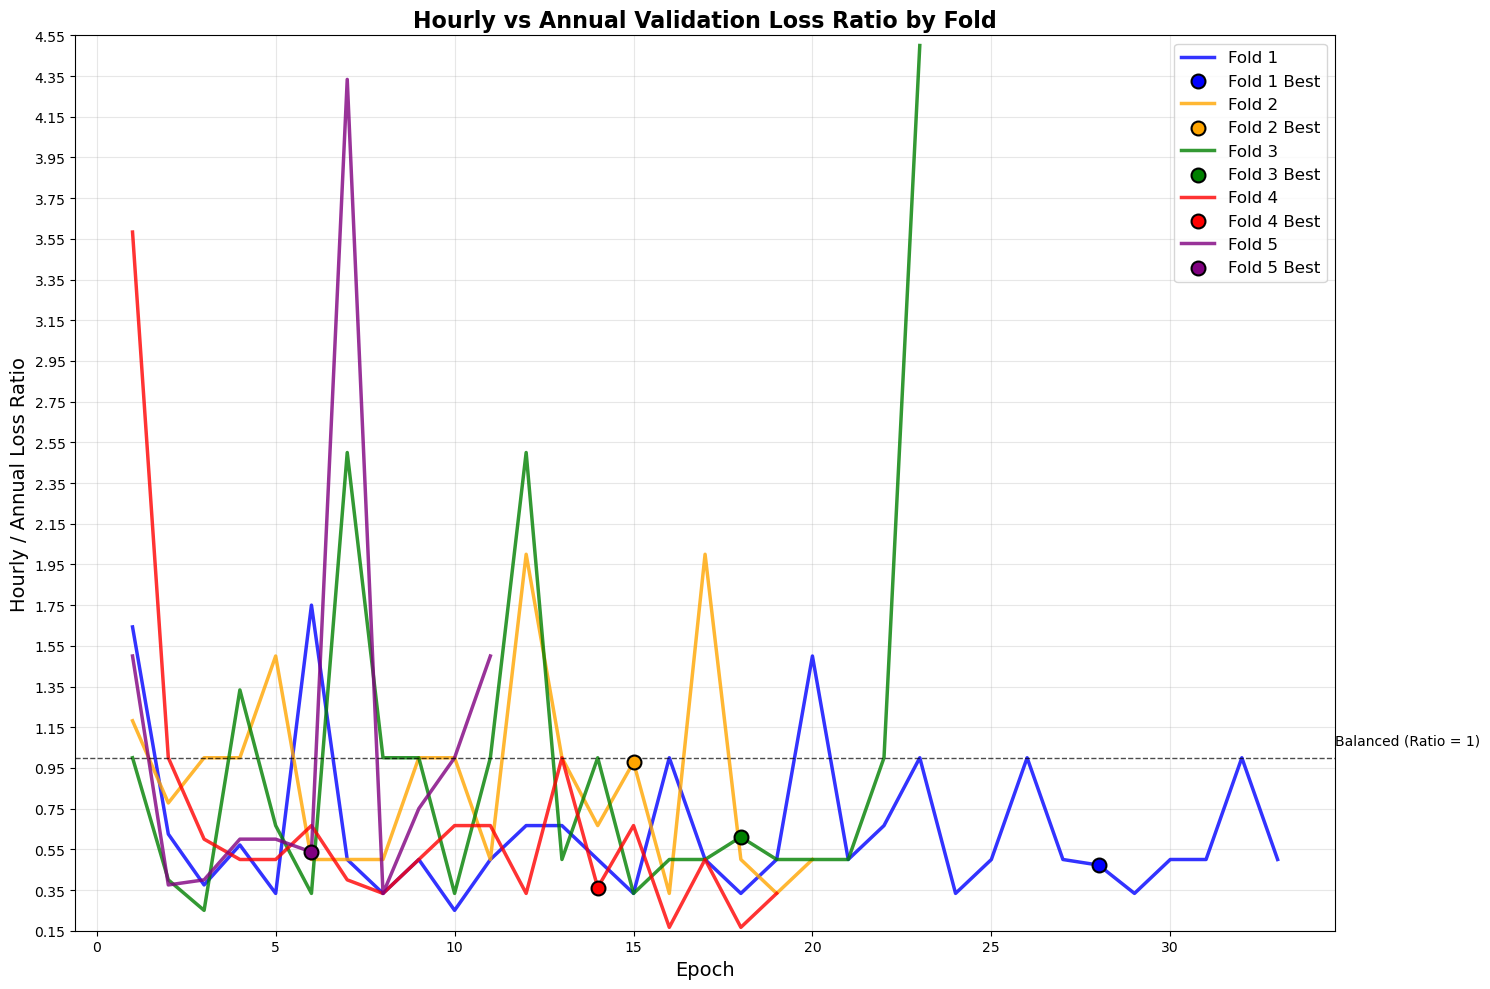


FOLD LOSS SUMMARY
Fold     Best Epoch   Best Hourly     Best Annual     Hourly/Annual  
--------------------------------------------------------------------------------
Fold 1   28           0.000069        0.000146        0.4726         
Fold 2   15           0.000135        0.000138        0.9783         
Fold 3   18           0.000080        0.000131        0.6107         
Fold 4   14           0.000071        0.000196        0.3622         
Fold 5   6            0.000131        0.000244        0.5369         
--------------------------------------------------------------------------------
Mean     -            0.000097        0.000171        0.5921         
Std      -            0.000029        0.000043        0.2096         

✓ Detailed loss data saved to 'detailed_fold_losses.csv'
✓ Best epoch summary saved to 'best_epoch_losses.csv'

ANALYSIS COMPLETED!
Key Insights:
• Hourly/Annual loss ratios show how each fold balances the two loss types
• Ratios < 1 indicate annual loss dom

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def extract_and_plot_fold_losses():
    """Extract hourly and annual validation losses from training logs and plot them"""
    
    # Define the fold data from the training logs with corrected best epoch values
    fold_data = {
        'fold1': {
            'epochs': list(range(1, 34)),
            'hourly_losses': [0.0023, 0.0005, 0.0003, 0.0004, 0.0002, 0.0007, 0.0002, 0.0001, 0.0002, 0.0001, 
                             0.0001, 0.0002, 0.0002, 0.0001, 0.0001, 0.0002, 0.0001, 0.0001, 0.0001, 0.0003,
                             0.0001, 0.0002, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.000069, 0.0001, 0.0001,  # Epoch 28 corrected
                             0.0001, 0.0001, 0.0001],
            'annual_losses': [0.0014, 0.0008, 0.0008, 0.0007, 0.0006, 0.0004, 0.0004, 0.0003, 0.0004, 0.0004,
                             0.0002, 0.0003, 0.0003, 0.0002, 0.0003, 0.0002, 0.0002, 0.0003, 0.0002, 0.0002,
                             0.0002, 0.0003, 0.0001, 0.0003, 0.0002, 0.0001, 0.0002, 0.000146, 0.0003, 0.0002,  # Epoch 28 corrected
                             0.0002, 0.0001, 0.0002],
            'best_epoch': 28
        },
        'fold2': {
            'epochs': list(range(1, 21)),
            'hourly_losses': [0.0013, 0.0007, 0.0006, 0.0003, 0.0006, 0.0001, 0.0002, 0.0001, 0.0002, 0.0002,
                             0.0001, 0.0004, 0.0002, 0.0002, 0.000135, 0.0001, 0.0004, 0.0001, 0.0001, 0.0001],  # Epoch 15 corrected
            'annual_losses': [0.0011, 0.0009, 0.0006, 0.0003, 0.0004, 0.0002, 0.0004, 0.0002, 0.0002, 0.0002,
                             0.0002, 0.0002, 0.0002, 0.0003, 0.000138, 0.0003, 0.0002, 0.0002, 0.0003, 0.0002],  # Epoch 15 corrected
            'best_epoch': 15
        },
        'fold3': {
            'epochs': list(range(1, 24)),
            'hourly_losses': [0.0012, 0.0004, 0.0002, 0.0004, 0.0002, 0.0001, 0.0005, 0.0002, 0.0002, 0.0001,
                             0.0002, 0.0005, 0.0001, 0.0003, 0.0001, 0.0001, 0.0001, 0.000080, 0.0001, 0.0001,  # Epoch 18 corrected
                             0.0001, 0.0001, 0.0009],
            'annual_losses': [0.0012, 0.0010, 0.0008, 0.0003, 0.0003, 0.0003, 0.0002, 0.0002, 0.0002, 0.0003,
                             0.0002, 0.0002, 0.0002, 0.0003, 0.0003, 0.0002, 0.0002, 0.000131, 0.0002, 0.0002,  # Epoch 18 corrected
                             0.0002, 0.0001, 0.0002],
            'best_epoch': 18
        },
        'fold4': {
            'epochs': list(range(1, 20)),
            'hourly_losses': [0.0043, 0.0007, 0.0003, 0.0002, 0.0002, 0.0002, 0.0002, 0.0001, 0.0001, 0.0002,
                             0.0002, 0.0001, 0.0002, 0.000071, 0.0002, 0.0001, 0.0001, 0.0001, 0.0001],  # Epoch 14 corrected
            'annual_losses': [0.0012, 0.0007, 0.0005, 0.0004, 0.0004, 0.0003, 0.0005, 0.0003, 0.0002, 0.0003,
                             0.0003, 0.0003, 0.0002, 0.000196, 0.0003, 0.0006, 0.0002, 0.0006, 0.0003],  # Epoch 14 corrected
            'best_epoch': 14
        },
        'fold5': {
            'epochs': list(range(1, 12)),
            'hourly_losses': [0.0018, 0.0003, 0.0002, 0.0003, 0.0003, 0.000131, 0.0013, 0.0001, 0.0003, 0.0003, 0.0003],  # Epoch 6 corrected
            'annual_losses': [0.0012, 0.0008, 0.0005, 0.0005, 0.0005, 0.000244, 0.0003, 0.0003, 0.0004, 0.0003, 0.0002],  # Epoch 6 corrected
            'best_epoch': 6
        }
    }
    
    # Colors for each fold
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    fold_names = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
    
    # Create the plot
    plt.figure(figsize=(15, 10))
    
    # Plot hourly vs annual losses for each fold
    for i, (fold_key, fold_info) in enumerate(fold_data.items()):
        epochs = fold_info['epochs']
        hourly_losses = fold_info['hourly_losses']
        annual_losses = fold_info['annual_losses']
        best_epoch = fold_info['best_epoch']
        
        # Calculate hourly/annual ratio
        hourly_annual_ratio = [hourly/annual if annual > 0 else 0 for hourly, annual in zip(hourly_losses, annual_losses)]
        
        plt.plot(epochs, hourly_annual_ratio, 
                color=colors[i], linewidth=2.5, label=fold_names[i], alpha=0.8)
        
        # Mark the best epoch for current fold
        best_ratio = hourly_annual_ratio[best_epoch-1]  # -1 because epochs start at 1 but list indices at 0
        
        plt.scatter(best_epoch, best_ratio, 
                   color=colors[i], s=100, zorder=5, edgecolor='black', linewidth=1.5,
                   label=f'{fold_names[i]} Best')
    
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Hourly / Annual Loss Ratio', fontsize=14)
    plt.title('Hourly vs Annual Validation Loss Ratio by Fold', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Set fixed y-axis range as requested
    plt.ylim(0.2, 4.5)
    
    # Set y-ticks with small increments
    y_ticks = np.arange(0.15, 4.6, 0.2)  # From 0.2 to 4.4 in steps of 0.2
    plt.yticks(y_ticks)
    
    # Add horizontal line at ratio = 1 (balanced losses)
    plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add text annotation for balanced line
    plt.text(1, 1.05, 'Balanced (Ratio = 1)', transform=plt.gca().get_yaxis_transform(), 
             fontsize=10, ha='left', va='bottom')
    
    plt.tight_layout()
    plt.savefig('hourly_annual_loss_ratio_by_fold.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a summary table using the corrected best values
    print("\nFOLD LOSS SUMMARY")
    print("=" * 80)
    print(f"{'Fold':<8} {'Best Epoch':<12} {'Best Hourly':<15} {'Best Annual':<15} {'Hourly/Annual':<15}")
    print("-" * 80)
    
    for i, (fold_key, fold_info) in enumerate(fold_data.items()):
        best_epoch = fold_info['best_epoch']
        best_hourly = fold_info['hourly_losses'][best_epoch-1]
        best_annual = fold_info['annual_losses'][best_epoch-1]
        ratio = best_hourly / best_annual if best_annual > 0 else 0
        
        print(f"{fold_names[i]:<8} {best_epoch:<12} {best_hourly:<15.6f} {best_annual:<15.6f} {ratio:<15.4f}")
    
    print("-" * 80)
    
    # Calculate and print statistics
    all_best_hourly = [fold_data[fold]['hourly_losses'][fold_data[fold]['best_epoch']-1] for fold in fold_data.keys()]
    all_best_annual = [fold_data[fold]['annual_losses'][fold_data[fold]['best_epoch']-1] for fold in fold_data.keys()]
    all_ratios = [h/a if a > 0 else 0 for h, a in zip(all_best_hourly, all_best_annual)]
    
    print(f"{'Mean':<8} {'-':<12} {np.mean(all_best_hourly):<15.6f} {np.mean(all_best_annual):<15.6f} {np.mean(all_ratios):<15.4f}")
    print(f"{'Std':<8} {'-':<12} {np.std(all_best_hourly):<15.6f} {np.std(all_best_annual):<15.6f} {np.std(all_ratios):<15.4f}")
    
    # Save data to CSV
    save_loss_data_to_csv(fold_data, fold_names)
    
    return fold_data

def save_loss_data_to_csv(fold_data, fold_names):
    """Save the loss data to CSV files for further analysis"""
    
    # Save detailed epoch-by-epoch data
    detailed_data = []
    for i, (fold_key, fold_info) in enumerate(fold_data.items()):
        for j, epoch in enumerate(fold_info['epochs']):
            detailed_data.append({
                'Fold': fold_names[i],
                'Epoch': epoch,
                'Hourly_Loss': fold_info['hourly_losses'][j],
                'Annual_Loss': fold_info['annual_losses'][j],
                'Hourly_Annual_Ratio': fold_info['hourly_losses'][j] / fold_info['annual_losses'][j] if fold_info['annual_losses'][j] > 0 else 0,
                'Is_Best_Epoch': (epoch == fold_info['best_epoch'])
            })
    
    detailed_df = pd.DataFrame(detailed_data)
    detailed_df.to_csv('detailed_fold_losses.csv', index=False)
    
    # Save best epoch summary
    best_epoch_data = []
    for i, (fold_key, fold_info) in enumerate(fold_data.items()):
        best_epoch = fold_info['best_epoch']
        idx = fold_info['epochs'].index(best_epoch)
        best_epoch_data.append({
            'Fold': fold_names[i],
            'Best_Epoch': best_epoch,
            'Best_Hourly_Loss': fold_info['hourly_losses'][idx],
            'Best_Annual_Loss': fold_info['annual_losses'][idx],
            'Hourly_Annual_Ratio': fold_info['hourly_losses'][idx] / fold_info['annual_losses'][idx] if fold_info['annual_losses'][idx] > 0 else 0
        })
    
    best_df = pd.DataFrame(best_epoch_data)
    best_df.to_csv('best_epoch_losses.csv', index=False)
    
    print(f"\n✓ Detailed loss data saved to 'detailed_fold_losses.csv'")
    print(f"✓ Best epoch summary saved to 'best_epoch_losses.csv'")

# Run the analysis
print("Extracting and plotting fold losses with corrected best values...")
fold_data = extract_and_plot_fold_losses()

print("\n" + "="*80)
print("ANALYSIS COMPLETED!")
print("="*80)
print("Key Insights:")
print("• Hourly/Annual loss ratios show how each fold balances the two loss types")
print("• Ratios < 1 indicate annual loss dominates")
print("• Ratios > 1 indicate hourly loss dominates") 
print("• Markers show the best performing epoch for each fold")
print("• Y-axis range: 0.15 to 4.5 with 0.2 increments")

In [12]:
### defining EnsembleModel
class EnsembleModel(nn.Module):
    """Ensemble model that averages predictions from multiple models"""
    def __init__(self, models):
        super().__init__()
        self.models = nn.ModuleList(models)
    
    def forward(self, x):
        # Get predictions from all models
        all_ann_preds = []
        all_hour_preds = []
        
        for model in self.models:
            ann_pred, hour_pred = model(x)
            all_ann_preds.append(ann_pred)
            all_hour_preds.append(hour_pred)
        
        # Average predictions
        ann_ensemble = torch.mean(torch.stack(all_ann_preds), dim=0)
        hour_ensemble = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ann_ensemble, hour_ensemble
    
    def predict(self, x):
        """Alias for forward method for consistency"""
        return self.forward(x)

# Now recreate the ensemble with the updated class
print("Recreating ensemble with updated class definition...")
ensemble_model_updated = EnsembleModel(all_models)

# Update the final_model variable
final_model = ensemble_model_updated

print("✓ Ensemble model updated with predict method")

Recreating ensemble with updated class definition...


NameError: name 'all_models' is not defined

STEP 8: ENSEMBLE RESULTS SAVING
Saving ensemble training results and metrics...
Loading normalization parameters for denormalization...
Evaluating ensemble model on test set...
Denormalizing ensemble outputs to real units...
Creating prediction vs true plots for ensemble...


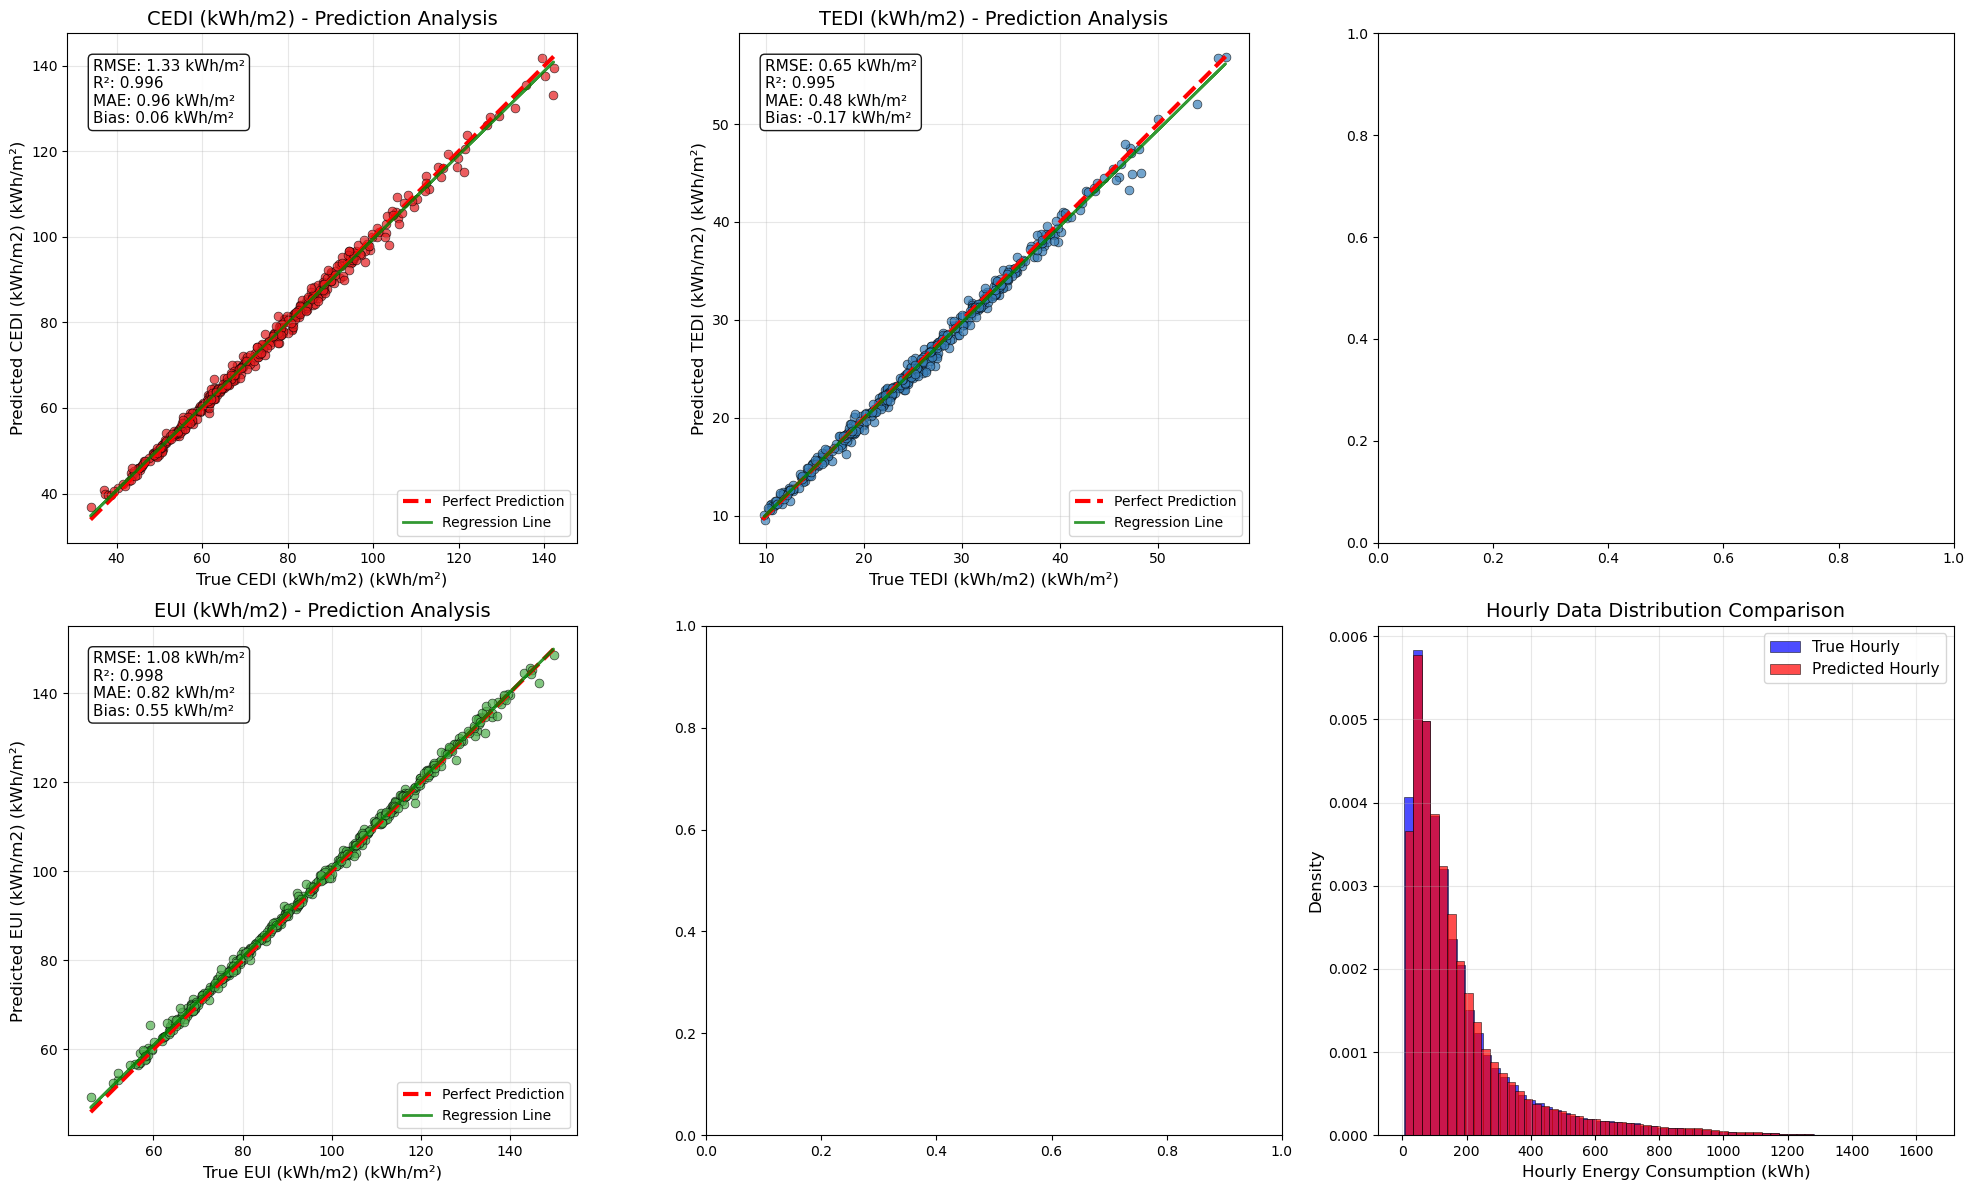

Creating individual detailed plots for ensemble...


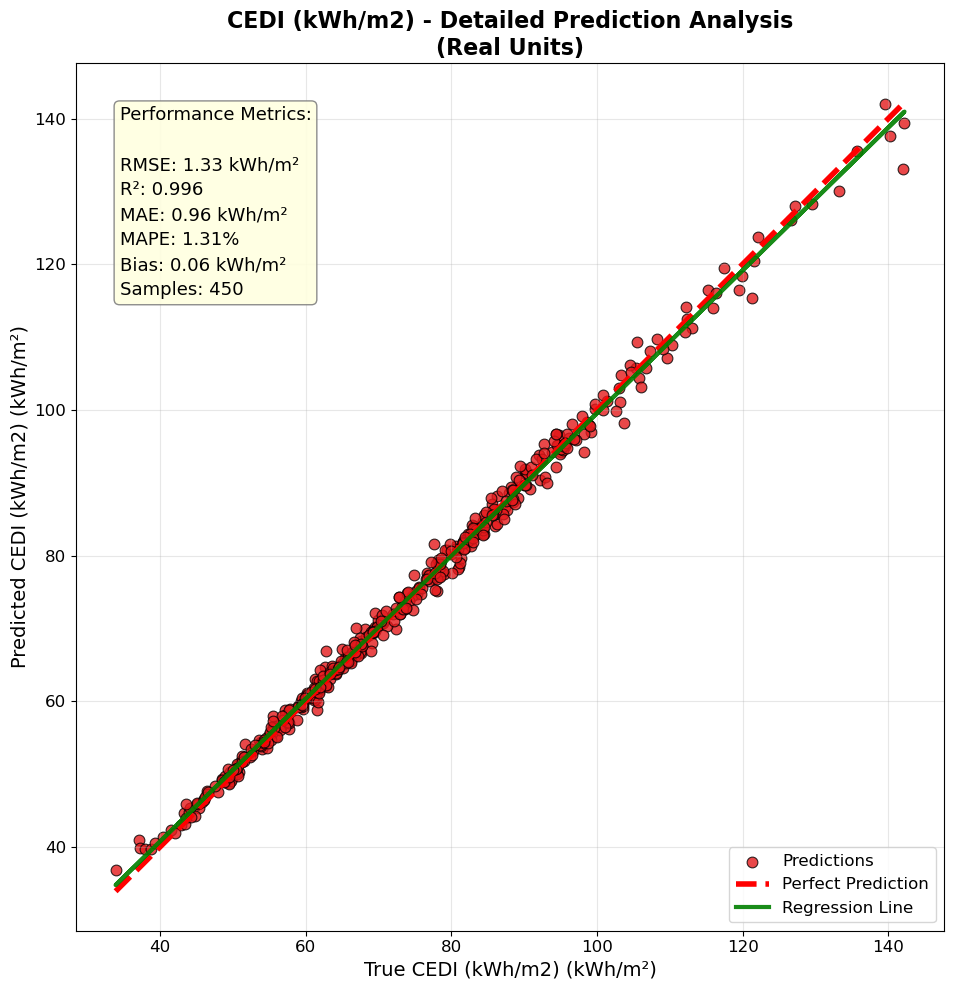

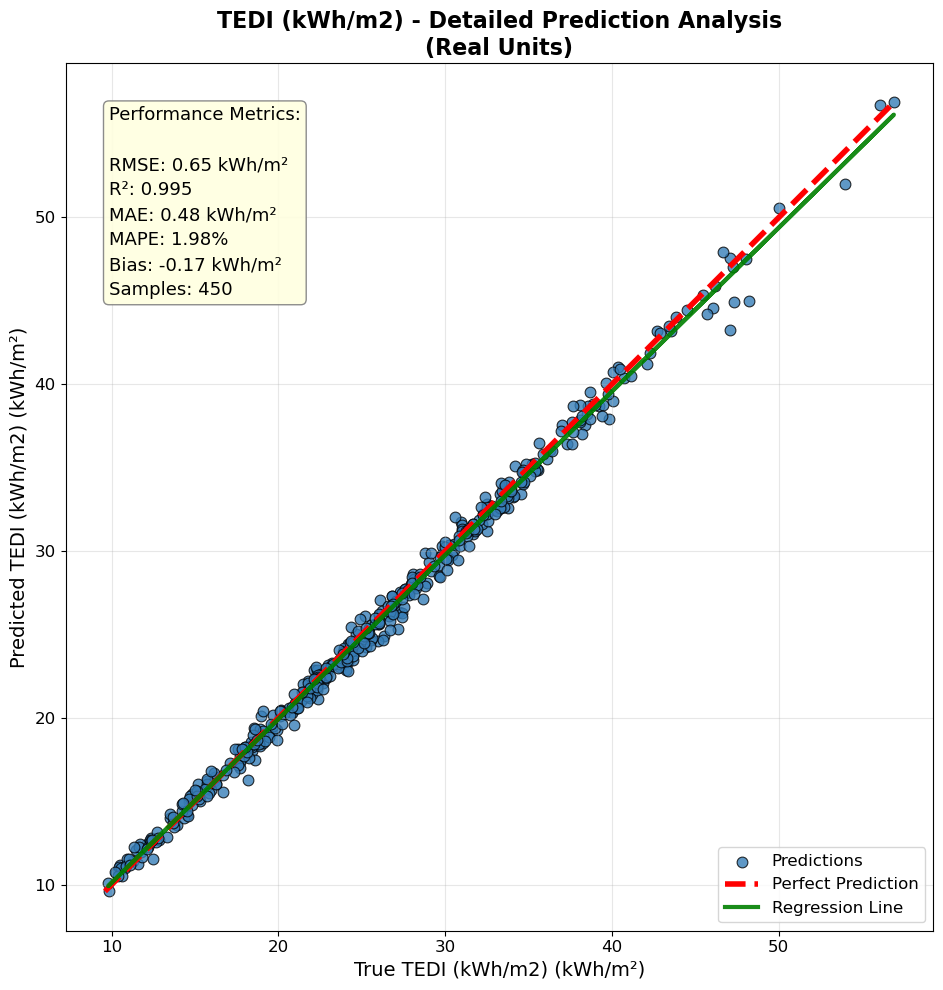

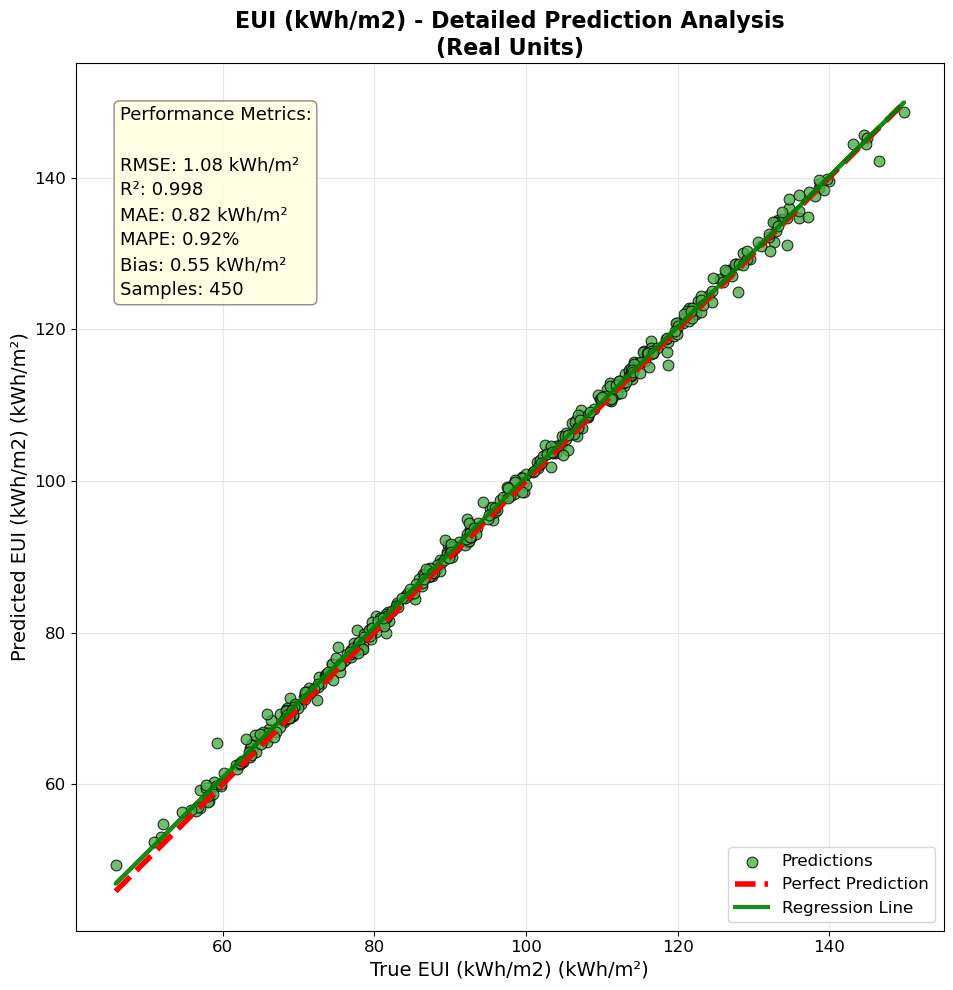

✓ Ensemble results saved to C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output
✓ Ensemble mean validation loss: 0.000202
✓ Ensemble test RMSE: 1.06 kWh/m²
✓ Ensemble test R²: 0.9961

ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):
CEDI (kWh/m2)             | RMSE:    1.33 kWh/m² | R²:  0.996 | MAE:    0.96 kWh/m²
TEDI (kWh/m2)             | RMSE:    0.65 kWh/m² | R²:  0.995 | MAE:    0.48 kWh/m²
EUI (kWh/m2)              | RMSE:    1.08 kWh/m² | R²:  0.998 | MAE:    0.82 kWh/m²

Ensemble Stability: ±0.000047


In [22]:
### # STEP 8: ENSEMBLE RESULTS SAVING WITH PREDICTION PLOTS
### =============================================================================

# Add all missing functions at the top
def load_normalization_params():
    """Load normalization parameters from saved file"""
    with open(NORM_JSON, 'r') as f:
        norm_params = json.load(f)
    return norm_params

def calculate_detailed_metrics(true_ann, pred_ann, true_hour, pred_hour):
    """Calculate comprehensive metrics for all outputs (using real units)"""
    metrics = {}
    
    # Annual metrics - overall
    metrics['annual_rmse'] = float(np.sqrt(mean_squared_error(true_ann, pred_ann)))
    metrics['annual_mae'] = float(mean_absolute_error(true_ann, pred_ann))
    metrics['annual_r2'] = float(r2_score(true_ann, pred_ann))
    
    # Annual metrics - per output
    for i, col in enumerate(ANNUAL_COLS):
        metrics[f'{col}_rmse'] = float(np.sqrt(mean_squared_error(true_ann[:, i], pred_ann[:, i])))
        metrics[f'{col}_mae'] = float(mean_absolute_error(true_ann[:, i], pred_ann[:, i]))
        metrics[f'{col}_r2'] = float(r2_score(true_ann[:, i], pred_ann[:, i]))
    
    # Hourly metrics
    hourly_true_flat = true_hour.reshape(-1)
    hourly_pred_flat = pred_hour.reshape(-1)
    
    metrics['hourly_rmse'] = float(np.sqrt(mean_squared_error(hourly_true_flat, hourly_pred_flat)))
    metrics['hourly_mae'] = float(mean_absolute_error(hourly_true_flat, hourly_pred_flat))
    metrics['hourly_r2'] = float(r2_score(hourly_true_flat, hourly_pred_flat))
    
    return metrics

def create_prediction_vs_true_comprehensive(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, metrics):
    """Create comprehensive prediction vs true plots for all annual parameters"""
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Plot each annual parameter
    for i, col in enumerate(ANNUAL_COLS):
        row = i // 2
        col_pos = i % 2
        
        true_values = ann_true_real[:, i]
        pred_values = ann_pred_real[:, i]
        
        # Calculate perfect prediction line
        min_val = min(true_values.min(), pred_values.min())
        max_val = max(true_values.max(), pred_values.max())
        perfect_line = np.linspace(min_val, max_val, 100)
        
        # Scatter plot with enhanced styling
        scatter = axes[row, col_pos].scatter(true_values, pred_values, alpha=0.7, s=40, 
                                           color=plt.cm.Set1(i), edgecolor='black', linewidth=0.5)
        axes[row, col_pos].plot(perfect_line, perfect_line, 'r--', linewidth=3, label='Perfect Prediction')
        
        # Add regression line
        z = np.polyfit(true_values, pred_values, 1)
        p = np.poly1d(z)
        axes[row, col_pos].plot(true_values, p(true_values), "g-", linewidth=2, alpha=0.8, label='Regression Line')
        
        # Enhanced statistics
        rmse = metrics[f'{col}_rmse']
        r2 = metrics[f'{col}_r2']
        mae = metrics[f'{col}_mae']
        bias = np.mean(pred_values - true_values)
        
        stats_text = f'RMSE: {rmse:.2f} kWh/m²\nR²: {r2:.3f}\nMAE: {mae:.2f} kWh/m²\nBias: {bias:.2f} kWh/m²'
        
        axes[row, col_pos].text(0.05, 0.95, stats_text, transform=axes[row, col_pos].transAxes, 
                               verticalalignment='top', fontsize=11,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        axes[row, col_pos].set_xlabel(f'True {col} (kWh/m²)', fontsize=12)
        axes[row, col_pos].set_ylabel(f'Predicted {col} (kWh/m²)', fontsize=12)
        axes[row, col_pos].set_title(f'{col} - Prediction Analysis', fontsize=14)
        axes[row, col_pos].legend(fontsize=10)
        axes[row, col_pos].grid(True, alpha=0.3)
        
        # Set equal aspect ratio for better visualization
        axes[row, col_pos].set_aspect('equal', adjustable='box')
    
    # Hourly data distribution comparison - CORRECTED UNITS: kWh
    axes[1, 2].hist(hour_true_real.flatten(), bins=60, alpha=0.7, label='True Hourly', 
                   color='blue', density=True, edgecolor='black', linewidth=0.5)
    axes[1, 2].hist(hour_pred_real.flatten(), bins=60, alpha=0.7, label='Predicted Hourly', 
                   color='red', density=True, edgecolor='black', linewidth=0.5)
    axes[1, 2].set_xlabel('Hourly Energy Consumption (kWh)', fontsize=12)  # CORRECTED
    axes[1, 2].set_ylabel('Density', fontsize=12)
    axes[1, 2].set_title('Hourly Data Distribution Comparison', fontsize=14)
    axes[1, 2].legend(fontsize=11)
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "comprehensive_predictions_hq.png", dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()

def create_individual_prediction_plots(ann_true_real, ann_pred_real, metrics):
    """Create individual high-quality plots for each annual parameter"""
    
    for i, col in enumerate(ANNUAL_COLS):
        plt.figure(figsize=(12, 10))
        
        true_values = ann_true_real[:, i]
        pred_values = ann_pred_real[:, i]
        
        # Create main scatter plot
        plt.scatter(true_values, pred_values, alpha=0.8, s=60, 
                   color=plt.cm.Set1(i), edgecolor='black', linewidth=0.8, label='Predictions')
        
        # Perfect prediction line
        min_val = min(true_values.min(), pred_values.min())
        max_val = max(true_values.max(), pred_values.max())
        perfect_line = np.linspace(min_val, max_val, 100)
        plt.plot(perfect_line, perfect_line, 'r--', linewidth=4, label='Perfect Prediction')
        
        # Regression line with confidence interval
        z = np.polyfit(true_values, pred_values, 1)
        p = np.poly1d(z)
        plt.plot(true_values, p(true_values), "g-", linewidth=3, alpha=0.9, label='Regression Line')
        
        # Enhanced statistics box
        rmse = metrics[f'{col}_rmse']
        r2 = metrics[f'{col}_r2']
        mae = metrics[f'{col}_mae']
        mape = np.mean(np.abs((true_values - pred_values) / true_values)) * 100
        bias = np.mean(pred_values - true_values)
        
        stats_text = f'Performance Metrics:\n\n'
        stats_text += f'RMSE: {rmse:.2f} kWh/m²\n'
        stats_text += f'R²: {r2:.3f}\n'
        stats_text += f'MAE: {mae:.2f} kWh/m²\n'
        stats_text += f'MAPE: {mape:.2f}%\n'
        stats_text += f'Bias: {bias:.2f} kWh/m²\n'
        stats_text += f'Samples: {len(true_values)}'
        
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                verticalalignment='top', fontsize=13, linespacing=1.5,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='gray'))
        
        plt.xlabel(f'True {col} (kWh/m²)', fontsize=14)
        plt.ylabel(f'Predicted {col} (kWh/m²)', fontsize=14)
        plt.title(f'{col} - Detailed Prediction Analysis\n(Real Units)', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12, loc='lower right')
        plt.grid(True, alpha=0.3)
        
        # Set equal aspect ratio
        plt.gca().set_aspect('equal', adjustable='box')
        
        # Enhanced styling
        plt.gca().tick_params(axis='both', which='major', labelsize=12)
        
        # Clean filename
        safe_col_name = col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
        filename = OUTPUT_DIR / f"individual_{safe_col_name}_predictions_hq.png"
        
        plt.tight_layout()
        plt.savefig(filename, dpi=400, bbox_inches='tight', facecolor='white')
        plt.show()

# Rest of the Step 8 code (denormalization and save_ensemble_results functions) remains the same...
def denormalize_annual_outputs_ensemble(norm_ann, annual_ranges):
    """Denormalize annual outputs for ensemble predictions"""
    denorm_ann = norm_ann.copy()
    for i, col in enumerate(ANNUAL_COLS):
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        denorm_ann[:, i] = norm_ann[:, i] * (vmax - vmin) + vmin
    return denorm_ann

def denormalize_hourly_outputs_ensemble(norm_hour, hourly_min, hourly_max):
    """Denormalize hourly outputs for ensemble predictions"""
    return norm_hour * (hourly_max - hourly_min) + hourly_min

def evaluate_ensemble_model(ensemble_model, X_test, y_ann_test, y_hour_test):
    """Evaluate ensemble model on test set"""
    print("Evaluating ensemble model on test set...")
    
    # Create test dataset and loader
    test_dataset = BuildingDataset(X_test, y_ann_test, y_hour_test)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    ensemble_model.eval()
    
    all_ann_true = []
    all_ann_pred = []
    all_hour_true = []
    all_hour_pred = []
    
    with torch.no_grad():
        for X, y_ann, y_hour in test_loader:
            X = X.to(DEVICE)
            
            # Ensemble prediction (averages across all models)
            pred_ann, pred_hour = ensemble_model.predict(X)
            
            all_ann_true.append(y_ann.numpy())
            all_ann_pred.append(pred_ann.cpu().numpy())
            all_hour_true.append(y_hour.numpy())
            all_hour_pred.append(pred_hour.cpu().numpy())
    
    # Stack all predictions
    ann_true = np.vstack(all_ann_true)
    ann_pred = np.vstack(all_ann_pred)
    hour_true = np.vstack(all_hour_true)
    hour_pred = np.vstack(all_hour_pred)
    
    return ann_true, ann_pred, hour_true, hour_pred

def save_ensemble_results(ensemble_model, kfold_history, best_params, X_test, y_ann_test, y_hour_test):
    """Save ensemble training results with comprehensive analysis"""
    print("Saving ensemble training results and metrics...")
    
    # Ensure output directory exists
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    
    # Load normalization parameters
    print("Loading normalization parameters for denormalization...")
    norm_params = load_normalization_params()
    annual_ranges = norm_params['annual_ranges']
    hourly_min = norm_params['hourly_min']
    hourly_max = norm_params['hourly_max']
    
    # Evaluate ensemble on test set
    ann_true_norm, ann_pred_norm, hour_true_norm, hour_pred_norm = evaluate_ensemble_model(
        ensemble_model, X_test, y_ann_test, y_hour_test
    )
    
    # DENORMALIZE to get real values
    print("Denormalizing ensemble outputs to real units...")
    ann_true_real = denormalize_annual_outputs_ensemble(ann_true_norm, annual_ranges)
    ann_pred_real = denormalize_annual_outputs_ensemble(ann_pred_norm, annual_ranges)
    hour_true_real = denormalize_hourly_outputs_ensemble(hour_true_norm, hourly_min, hourly_max)
    hour_pred_real = denormalize_hourly_outputs_ensemble(hour_pred_norm, hourly_min, hourly_max)
    
    # Calculate detailed metrics using REAL values
    test_metrics = calculate_detailed_metrics(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real)
    
    # CREATE ALL HIGH-QUALITY PLOTS (using the same plotting functions)
    print("Creating prediction vs true plots for ensemble...")
    create_prediction_vs_true_comprehensive(ann_true_real, ann_pred_real, hour_true_real, hour_pred_real, test_metrics)
    
    print("Creating individual detailed plots for ensemble...")
    create_individual_prediction_plots(ann_true_real, ann_pred_real, test_metrics)
    
    # Enhanced training history with ensemble info
    enhanced_history = {
        'kfold_curves': kfold_history['fold_losses'],
        'ensemble_info': kfold_history['ensemble_info'],
        'best_fold': kfold_history.get('best_fold', 1),
        'test_metrics': test_metrics
    }
    
    # Save enhanced training history
    with open(TRAINING_HISTORY, 'w') as f:
        json.dump(enhanced_history, f, indent=4)
    
    # Enhanced final metrics
    final_metrics = {
        'best_hyperparameters': best_params,
        'ensemble_configuration': kfold_history['ensemble_info'],
        'final_test_metrics': test_metrics,
        'training_summary': {
            'random_seed': RANDOM_SEED,
            'device': str(DEVICE),
            'k_folds': K_FOLDS,
            'total_models': kfold_history['ensemble_info']['n_models'],
            'mean_val_loss': kfold_history['ensemble_info']['mean_total_loss']
        },
        'model_performance': {
            'test_rmse': test_metrics['annual_rmse'],
            'test_r2': test_metrics['annual_r2'],
            'ensemble_stability': kfold_history['ensemble_info']['std_total_loss']
        }
    }
    
    with open(METRICS_FILE, 'w') as f:
        json.dump(final_metrics, f, indent=4)
    
    # Enhanced model info for ensemble
    model_info = {
        'model_type': 'ensemble',
        'n_models': kfold_history['ensemble_info']['n_models'],
        'model_files': [f"ensemble_model_fold_{i+1}.pth" for i in range(K_FOLDS)],
        'norm_file': str(NORM_JSON.name),
        'training_history_file': str(TRAINING_HISTORY.name),
        'metrics_file': str(METRICS_FILE.name),
        'param_names': PARAM_NAMES_EXPECTED,
        'annual_cols': ANNUAL_COLS,
        'model_architecture': {
            'in_dim': X_test.shape[1],
            'latent_dim': best_params["latent_dim"],
            'conv_channels': best_params["conv_channels"],
            'ann_out': y_ann_test.shape[1]
        },
        'ensemble_info': kfold_history['ensemble_info']
    }
    
    with open(MODEL_INFO, 'w') as f:
        json.dump(model_info, f, indent=4)
    
    print(f"✓ Ensemble results saved to {OUTPUT_DIR}")
    print(f"✓ Ensemble mean validation loss: {kfold_history['ensemble_info']['mean_total_loss']:.6f}")
    print(f"✓ Ensemble test RMSE: {test_metrics['annual_rmse']:.2f} kWh/m²")
    print(f"✓ Ensemble test R²: {test_metrics['annual_r2']:.4f}")
    
    # Print detailed performance for each annual parameter
    print("\n" + "="*70)
    print("ENSEMBLE ANNUAL PARAMETER PERFORMANCE (REAL UNITS):")
    print("="*70)
    for col in ANNUAL_COLS:
        rmse = test_metrics[f'{col}_rmse']
        r2 = test_metrics[f'{col}_r2']
        mae = test_metrics[f'{col}_mae']
        print(f"{col:25} | RMSE: {rmse:7.2f} kWh/m² | R²: {r2:6.3f} | MAE: {mae:7.2f} kWh/m²")
    
    # Print ensemble stability
    print(f"\nEnsemble Stability: ±{kfold_history['ensemble_info']['std_total_loss']:.6f}")

print("STEP 8: ENSEMBLE RESULTS SAVING")
save_ensemble_results(
    final_model, kfold_history, best_params,
    X_test_final, y_ann_test_final, y_hour_test_final
)

STEP 8.1: ENSEMBLE LOSS RATIO ANALYSIS (CORRECTED)
Analyzing loss ratios for ensemble model...


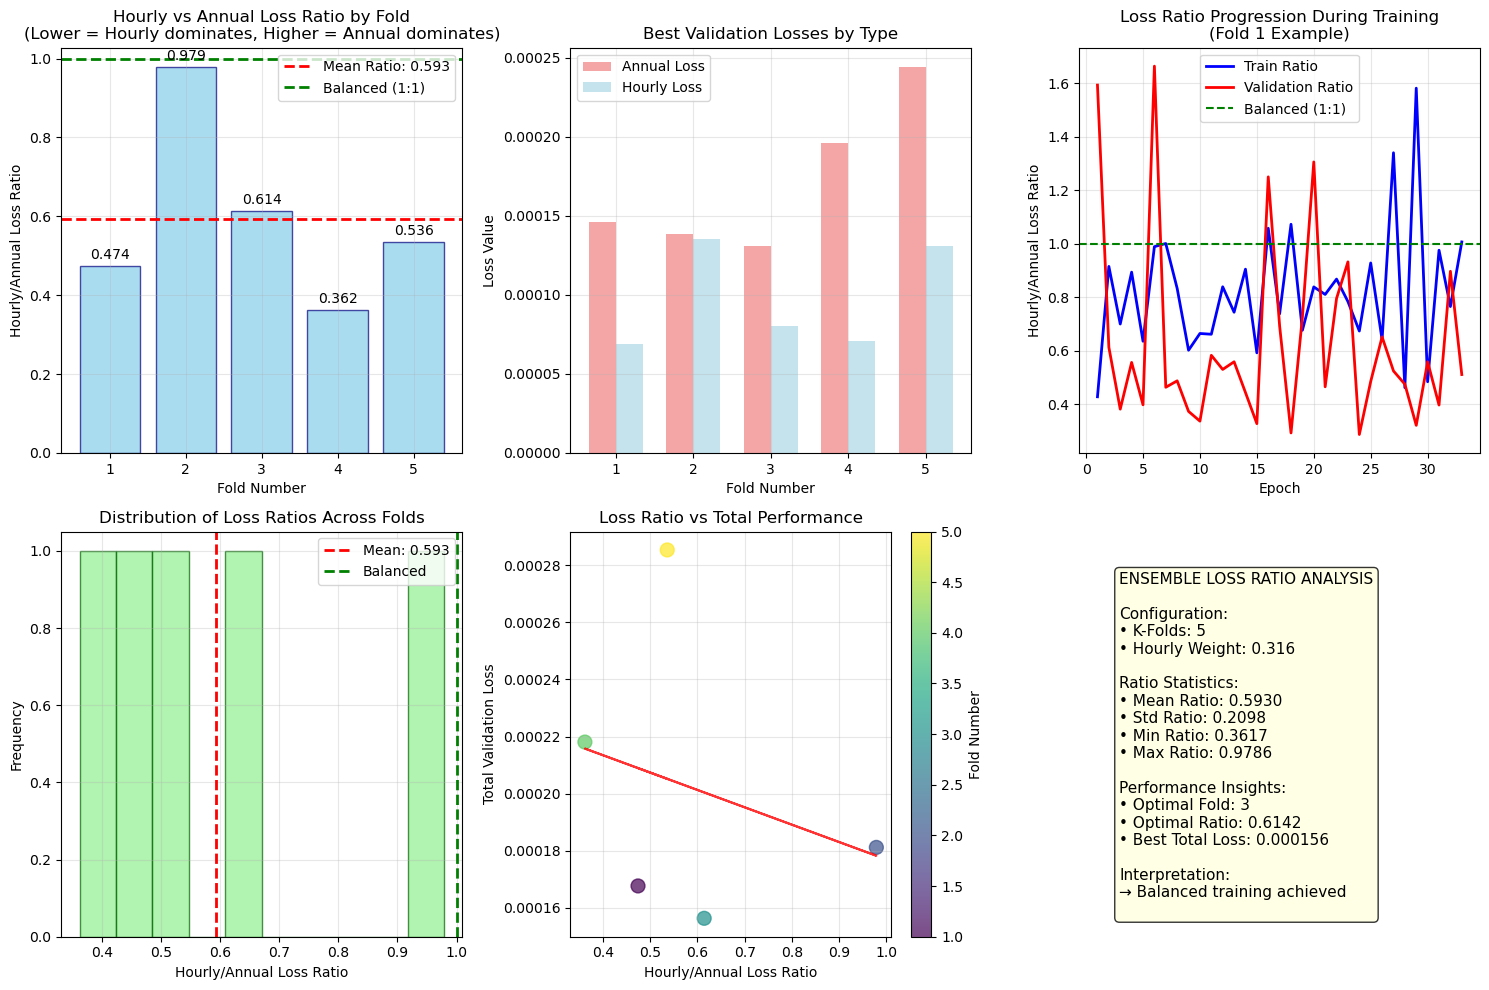


DETAILED LOSS RATIO ANALYSIS
Fold   Hourly/Annual Ratio  Annual Loss     Hourly Loss     Total Loss     
--------------------------------------------------------------------------------
1      0.4742               0.000146        0.000069        0.000168       
2      0.9786               0.000138        0.000135        0.000181       
3      0.6142               0.000131        0.000080        0.000156       
4      0.3617               0.000196        0.000071        0.000218       
5      0.5360               0.000244        0.000131        0.000285       
--------------------------------------------------------------------------------
Mean   0.5930               0.000171        0.000097        0.000202       
Std    0.2098               0.000043        0.000030        0.000047       

✓ Loss ratio analysis saved to: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output\loss_ratio_analysis.json
✓ Optimal hourly/annual ratio: 0.6142 (Fold 3)


In [23]:
### STEP 8.1: LOSS RATIO ANALYSIS FOR ENSEMBLE MODEL
### =============================================================================

def analyze_loss_ratios(kfold_history, best_params):
    """Analyze and plot the hourly/annual loss ratios for ensemble model"""
    print("Analyzing loss ratios for ensemble model...")
    
    # Extract loss ratios for each fold
    hourly_annual_ratios = []
    fold_numbers = []
    
    for fold, history in enumerate(kfold_history['fold_losses']):
        # Calculate ratio for best validation losses
        best_hourly_loss = history['best_val_hourly_loss']
        best_annual_loss = history['best_val_annual_loss']
        
        if best_annual_loss > 0:  # Avoid division by zero
            ratio = best_hourly_loss / best_annual_loss
            hourly_annual_ratios.append(ratio)
            fold_numbers.append(fold + 1)
    
    # Calculate statistics
    mean_ratio = np.mean(hourly_annual_ratios)
    std_ratio = np.std(hourly_annual_ratios)
    
    # Create comprehensive loss ratio plot
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Hourly/Annual loss ratio across folds
    plt.subplot(2, 3, 1)
    bars = plt.bar(fold_numbers, hourly_annual_ratios, color='skyblue', alpha=0.7, edgecolor='navy')
    plt.axhline(y=mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean Ratio: {mean_ratio:.3f}')
    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Balanced (1:1)')
    
    # Add value labels on bars
    for bar, ratio in zip(bars, hourly_annual_ratios):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.xlabel('Fold Number')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('Hourly vs Annual Loss Ratio by Fold\n(Lower = Hourly dominates, Higher = Annual dominates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Individual losses comparison
    plt.subplot(2, 3, 2)
    best_annual_losses = [h['best_val_annual_loss'] for h in kfold_history['fold_losses']]
    best_hourly_losses = [h['best_val_hourly_loss'] for h in kfold_history['fold_losses']]
    
    width = 0.35
    x = np.arange(len(fold_numbers))
    
    plt.bar(x - width/2, best_annual_losses, width, label='Annual Loss', alpha=0.7, color='lightcoral')
    plt.bar(x + width/2, best_hourly_losses, width, label='Hourly Loss', alpha=0.7, color='lightblue')
    
    plt.xlabel('Fold Number')
    plt.ylabel('Loss Value')
    plt.title('Best Validation Losses by Type')
    plt.xticks(x, fold_numbers)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Loss progression during training (example fold)
    plt.subplot(2, 3, 3)
    example_fold = kfold_history['fold_losses'][0]  # Use first fold as example
    
    epochs = example_fold['epoch']
    train_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['train_hourly_loss'], example_fold['train_annual_loss'])]
    val_ratio = [h/a if a > 0 else 0 for h, a in zip(example_fold['val_hourly_loss'], example_fold['val_annual_loss'])]
    
    plt.plot(epochs, train_ratio, 'b-', label='Train Ratio', linewidth=2)
    plt.plot(epochs, val_ratio, 'r-', label='Validation Ratio', linewidth=2)
    plt.axhline(y=1.0, color='green', linestyle='--', label='Balanced (1:1)')
    
    plt.xlabel('Epoch')
    plt.ylabel('Hourly/Annual Loss Ratio')
    plt.title('Loss Ratio Progression During Training\n(Fold 1 Example)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Distribution of ratios
    plt.subplot(2, 3, 4)
    plt.hist(hourly_annual_ratios, bins=10, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
    plt.axvline(mean_ratio, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ratio:.3f}')
    plt.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Balanced')
    
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Frequency')
    plt.title('Distribution of Loss Ratios Across Folds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Relationship between ratio and total loss
    plt.subplot(2, 3, 5)
    best_total_losses = [h['best_val_loss'] for h in kfold_history['fold_losses']]  # CORRECTED KEY NAME
    
    scatter = plt.scatter(hourly_annual_ratios, best_total_losses, c=fold_numbers, 
                         cmap='viridis', s=100, alpha=0.7)
    
    # Add correlation line
    z = np.polyfit(hourly_annual_ratios, best_total_losses, 1)
    p = np.poly1d(z)
    plt.plot(hourly_annual_ratios, p(hourly_annual_ratios), "r-", alpha=0.8)
    
    plt.colorbar(scatter, label='Fold Number')
    plt.xlabel('Hourly/Annual Loss Ratio')
    plt.ylabel('Total Validation Loss')
    plt.title('Loss Ratio vs Total Performance')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Calculate additional statistics
    optimal_ratio_fold = fold_numbers[np.argmin(best_total_losses)]
    optimal_ratio = hourly_annual_ratios[np.argmin(best_total_losses)]
    
    summary_text = f"ENSEMBLE LOSS RATIO ANALYSIS\n\n"
    summary_text += f"Configuration:\n"
    summary_text += f"• K-Folds: {K_FOLDS}\n"
    summary_text += f"• Hourly Weight: {best_params['w_hour']:.3f}\n\n"
    
    summary_text += f"Ratio Statistics:\n"
    summary_text += f"• Mean Ratio: {mean_ratio:.4f}\n"
    summary_text += f"• Std Ratio: {std_ratio:.4f}\n"
    summary_text += f"• Min Ratio: {min(hourly_annual_ratios):.4f}\n"
    summary_text += f"• Max Ratio: {max(hourly_annual_ratios):.4f}\n\n"
    
    summary_text += f"Performance Insights:\n"
    summary_text += f"• Optimal Fold: {optimal_ratio_fold}\n"
    summary_text += f"• Optimal Ratio: {optimal_ratio:.4f}\n"
    summary_text += f"• Best Total Loss: {min(best_total_losses):.6f}\n\n"
    
    summary_text += f"Interpretation:\n"
    if mean_ratio < 0.5:
        summary_text += "→ Hourly loss dominates training\n"
    elif mean_ratio > 2.0:
        summary_text += "→ Annual loss dominates training\n"
    else:
        summary_text += "→ Balanced training achieved\n"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ensemble_loss_ratio_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed ratio analysis
    print("\n" + "="*80)
    print("DETAILED LOSS RATIO ANALYSIS")
    print("="*80)
    print(f"{'Fold':<6} {'Hourly/Annual Ratio':<20} {'Annual Loss':<15} {'Hourly Loss':<15} {'Total Loss':<15}")
    print("-" * 80)
    for i, (fold, ratio) in enumerate(zip(fold_numbers, hourly_annual_ratios)):
        print(f"{fold:<6} {ratio:<20.4f} {best_annual_losses[i]:<15.6f} {best_hourly_losses[i]:<15.6f} {best_total_losses[i]:<15.6f}")
    
    print("-" * 80)
    print(f"{'Mean':<6} {mean_ratio:<20.4f} {np.mean(best_annual_losses):<15.6f} {np.mean(best_hourly_losses):<15.6f} {np.mean(best_total_losses):<15.6f}")
    print(f"{'Std':<6} {std_ratio:<20.4f} {np.std(best_annual_losses):<15.6f} {np.std(best_hourly_losses):<15.6f} {np.std(best_total_losses):<15.6f}")
    
    # Save ratio analysis to JSON
    ratio_analysis = {
        'hourly_annual_ratios': hourly_annual_ratios,
        'mean_ratio': float(mean_ratio),
        'std_ratio': float(std_ratio),
        'min_ratio': float(min(hourly_annual_ratios)),
        'max_ratio': float(max(hourly_annual_ratios)),
        'optimal_ratio_fold': int(optimal_ratio_fold),
        'optimal_ratio': float(optimal_ratio),
        'hourly_weight_used': float(best_params['w_hour']),
        'interpretation': 'hourly_dominates' if mean_ratio < 0.5 else 'annual_dominates' if mean_ratio > 2.0 else 'balanced'
    }
    
    with open(OUTPUT_DIR / "loss_ratio_analysis.json", "w") as f:
        json.dump(ratio_analysis, f, indent=4)
    
    print(f"\n✓ Loss ratio analysis saved to: {OUTPUT_DIR / 'loss_ratio_analysis.json'}")
    print(f"✓ Optimal hourly/annual ratio: {optimal_ratio:.4f} (Fold {optimal_ratio_fold})")

print("STEP 8.1: ENSEMBLE LOSS RATIO ANALYSIS (CORRECTED)")
analyze_loss_ratios(kfold_history, best_params)

In [26]:
# ### STEP 9: ENSEMBLE PREDICTION INTERFACE FOR K-FOLD and saving the model as atand alone (several files are needed) without clustering
# ### =============================================================================

# def create_ensemble_prediction_interface():
#     """Create a standalone prediction script for ensemble model"""
    
#     prediction_code = '''# predict_ensemble_model.py
# """
# Standalone prediction interface for the trained ensemble model
# Usage: python predict_ensemble_model.py
# """

# import json
# import torch
# import numpy as np
# import pandas as pd
# from pathlib import Path

# # Model architecture (must match training)
# class UnifiedNet(torch.nn.Module):
#     def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
#         super().__init__()
#         self.day, self.hour = 365, 24
#         self.encoder = torch.nn.Sequential(
#             torch.nn.Linear(in_dim, 128), torch.nn.ReLU(),
#             torch.nn.Linear(128, latent_dim), torch.nn.ReLU()
#         )
#         self.fc_to_map = torch.nn.Linear(latent_dim, self.day * self.hour)
#         self.conv_decoder = torch.nn.Sequential(
#             torch.nn.Conv2d(1, conv_channels, 3, padding=1), torch.nn.ReLU(),
#             torch.nn.Conv2d(conv_channels, conv_channels, 3, padding=1), torch.nn.ReLU(),
#             torch.nn.Conv2d(conv_channels, 1, 1)
#         )
#         self.ann_head = torch.nn.Sequential(
#             torch.nn.Linear(latent_dim, 128), torch.nn.ReLU(),
#             torch.nn.Linear(128, ann_out)
#         )
    
#     def forward(self, x):
#         z = self.encoder(x)
#         h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
#         h = self.conv_decoder(h)
#         ann = self.ann_head(z)
#         return ann, h

# # Use the SAME EnsembleModel class as in training
# class EnsembleModel(torch.nn.Module):
#     """Ensemble model that averages predictions from multiple models"""
#     def __init__(self, models):
#         super().__init__()
#         self.models = torch.nn.ModuleList(models)
#         self.n_models = len(models)
#         print(f"Loaded ensemble with {self.n_models} models")
    
#     def forward(self, x):
#         """Make ensemble prediction by averaging all model outputs"""
#         all_ann_preds = []
#         all_hour_preds = []
        
#         for model in self.models:
#             ann_pred, hour_pred = model(x)
#             all_ann_preds.append(ann_pred)
#             all_hour_preds.append(hour_pred)
        
#         # Average predictions across all models
#         ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
#         ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
#         return ensemble_ann, ensemble_hour
    
#     def predict(self, x):
#         """Alias for forward method for consistency"""
#         return self.forward(x)
    
#     def predict_with_uncertainty(self, x):
#         """Make ensemble prediction with uncertainty estimates"""
#         device = next(self.models[0].parameters()).device
#         x = x.to(device)
        
#         all_ann_preds = []
#         all_hour_preds = []
        
#         with torch.no_grad():
#             for model in self.models:
#                 model.eval()
#                 pred_ann, pred_hour = model(x)
#                 all_ann_preds.append(pred_ann.cpu().numpy())
#                 all_hour_preds.append(pred_hour.cpu().numpy())
        
#         # Convert to numpy for uncertainty calculation
#         all_ann_preds = np.array(all_ann_preds)  # shape: (n_models, batch_size, n_annual_outputs)
#         all_hour_preds = np.array(all_hour_preds)  # shape: (n_models, batch_size, 1, 365, 24)
        
#         # Calculate mean predictions
#         mean_ann = np.mean(all_ann_preds, axis=0)
#         mean_hour = np.mean(all_hour_preds, axis=0)
        
#         # Calculate standard deviation (uncertainty)
#         std_ann = np.std(all_ann_preds, axis=0)
#         std_hour = np.std(all_hour_preds, axis=0)
        
#         return (torch.tensor(mean_ann), torch.tensor(mean_hour), 
#                 torch.tensor(std_ann), torch.tensor(std_hour))

# def load_ensemble_model():
#     """Load ensemble model and normalization parameters"""
#     model_dir = Path(".")  # Current directory
    
#     # Load normalization parameters
#     with open(model_dir / "norm_params.json") as f:
#         norm = json.load(f)
    
#     # Load model configuration
#     with open(model_dir / "model_info.json") as f:
#         info = json.load(f)
    
#     # Load ensemble info
#     with open(model_dir / "ensemble_info.json") as f:
#         ensemble_info = json.load(f)
    
#     # Recreate model architecture
#     arch = info['model_architecture']
#     all_models = []
    
#     # Load all fold models
#     for fold in range(1, ensemble_info['n_models'] + 1):
#         model_path = model_dir / f"ensemble_model_fold_{fold}.pth"
#         if model_path.exists():
#             model = UnifiedNet(
#                 in_dim=arch['in_dim'],
#                 latent_dim=arch['latent_dim'], 
#                 conv_channels=arch['conv_channels'],
#                 ann_out=arch['ann_out']
#             )
            
#             checkpoint = torch.load(model_path, map_location='cpu')
#             model.load_state_dict(checkpoint['model_state_dict'])
#             model.eval()
#             all_models.append(model)
#             print(f"✓ Loaded model from fold {fold}")
#         else:
#             print(f"⚠ Warning: Model file not found: {model_path}")
    
#     if not all_models:
#         raise ValueError("No ensemble models found!")
    
#     ensemble = EnsembleModel(all_models)
#     return ensemble, norm

# def predict_single_input(ensemble, norm, input_values):
#     """Make prediction for single input set and return REAL values"""
#     normalized_input = []
#     for i, param in enumerate(norm['param_names']):
#         vmin, vmax = norm['input_ranges'][param]
#         normalized_val = (input_values[i] - vmin) / (vmax - vmin)
#         normalized_input.append(normalized_val)
    
#     # Convert to tensor and predict
#     x = torch.tensor([normalized_input], dtype=torch.float32)
#     with torch.no_grad():
#         pred_ann_norm, pred_hour_norm = ensemble.predict(x)
    
#     # Convert to numpy (still normalized)
#     pred_ann_norm = pred_ann_norm.numpy()[0]
#     pred_hour_norm = pred_hour_norm.numpy()[0, 0, :, :]
    
#     # DENORMALIZE to get REAL values
#     ann_real = []
#     for i, col in enumerate(norm['annual_cols']):
#         vmin = norm['annual_ranges'][f'{col}_min']
#         vmax = norm['annual_ranges'][f'{col}_max']
#         real_val = pred_ann_norm[i] * (vmax - vmin) + vmin
#         ann_real.append(real_val)
    
#     # Denormalize hourly output to kWh
#     hourly_real = pred_hour_norm * (norm['hourly_max'] - norm['hourly_min']) + norm['hourly_min']
    
#     return ann_real, hourly_real

# def main():
#     try:
#         ensemble, norm = load_ensemble_model()
#         print("✓ Ensemble model loaded successfully!")
#         print(f"✓ Using {ensemble.n_models} models for ensemble prediction")
#     except Exception as e:
#         print(f"Error loading ensemble model: {e}")
#         print("Make sure you're running this script from the same folder as:")
#         print("  - norm_params.json")
#         print("  - model_info.json") 
#         print("  - ensemble_info.json")
#         print("  - ensemble_model_fold_*.pth files")
#         return
    
#     print("=" * 70)
#     print("ENSEMBLE BUILDING ENERGY PREDICTION MODEL")
#     print("=" * 70)
#     print("Please enter the following building parameters:")
#     print()
    
#     input_values = []
#     for param in norm['param_names']:
#         # Show parameter ranges for reference
#         vmin, vmax = norm['input_ranges'][param]
#         value = float(input(f"{param} (range: {vmin} to {vmax}): "))
#         input_values.append(value)
    
#     print("\\nProcessing ensemble prediction...")
#     annual_pred, hourly_pred = predict_single_input(ensemble, norm, input_values)
    
#     print("\\n" + "=" * 70)
#     print("ENSEMBLE PREDICTION RESULTS")
#     print("=" * 70)
#     print("ANNUAL ENERGY CONSUMPTION (kWh/m²):")
#     print("-" * 45)
#     for i, col in enumerate(norm['annual_cols']):
#         print(f"  {col:20}: {annual_pred[i]:.2f} kWh/m²")
    
#     # Save hourly results
#     hourly_df = pd.DataFrame(hourly_pred)
#     hourly_file = "ensemble_predicted_hourly_consumption.csv"
#     hourly_df.to_csv(hourly_file, index=False, header=False)
    
#     print(f"\\nHOURLY ENERGY CONSUMPTION:")
#     print(f"  Saved to: {hourly_file}")
#     print(f"  Shape: {hourly_pred.shape} ({hourly_pred.shape[0]} days × {hourly_pred.shape[1]} hours)")
#     print(f"  Total annual hourly sum: {np.sum(hourly_pred):.0f} kWh")
    
#     # Calculate and display key statistics
#     print(f"\\nHOURLY PROFILE STATISTICS:")
#     print(f"  Average daily consumption: {np.mean(np.sum(hourly_pred, axis=1)):.1f} kWh/day")
#     print(f"  Peak hourly consumption: {np.max(hourly_pred):.2f} kWh")
#     print(f"  Minimum hourly consumption: {np.min(hourly_pred):.2f} kWh")
    
#     print("\\n" + "=" * 70)

# if __name__ == "__main__":
#     main()
# '''

#     # Write the ensemble prediction interface file
#     with open(OUTPUT_DIR / "predict_ensemble_model.py", "w", encoding="utf-8") as f:
#         f.write(prediction_code)
    
#     print(f"✓ Ensemble prediction interface created: {OUTPUT_DIR / 'predict_ensemble_model.py'}")
#     print("You can now use this file on any computer with PyTorch installed!")
#     print("Usage: cd output && python predict_ensemble_model.py")

# def test_ensemble_prediction_interface():
#     """Test that the ensemble prediction interface works correctly"""
#     print("Testing ensemble prediction interface...")
    
#     # Load the normalization parameters
#     norm_params = load_normalization_params()
    
#     # Test with some sample input (middle of each parameter range)
#     sample_input = []
#     for param in PARAM_NAMES_EXPECTED:
#         vmin, vmax = INPUT_RANGES[param]
#         sample_value = (vmin + vmax) / 2  # Middle of range
#         sample_input.append(sample_value)
    
#     print("Sample input (middle of parameter ranges):")
#     for param, value in zip(PARAM_NAMES_EXPECTED, sample_input):
#         print(f"  {param:15}: {value:.3f}")
    
#     # Make ensemble prediction
#     normalized_input = []
#     for i, param in enumerate(PARAM_NAMES_EXPECTED):
#         vmin, vmax = INPUT_RANGES[param]
#         normalized_val = (sample_input[i] - vmin) / (vmax - vmin)
#         normalized_input.append(normalized_val)
    
#     x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
    
#     with torch.no_grad():
#         pred_ann_norm, pred_hour_norm = final_model.predict(x)
    
#     # Convert to numpy (single prediction, so 1D array)
#     pred_ann_norm_np = pred_ann_norm.cpu().numpy()[0]  # Shape: (3,)
#     pred_hour_norm_np = pred_hour_norm.cpu().numpy()[0, 0, :, :]  # Shape: (365, 24)
    
#     # Denormalize to real values
#     pred_ann_real = []
#     for i, col in enumerate(ANNUAL_COLS):
#         vmin = norm_params['annual_ranges'][f"{col}_min"]
#         vmax = norm_params['annual_ranges'][f"{col}_max"]
#         real_val = pred_ann_norm_np[i] * (vmax - vmin) + vmin
#         pred_ann_real.append(real_val)
    
#     # Denormalize hourly
#     pred_hour_real = pred_hour_norm_np * (norm_params['hourly_max'] - norm_params['hourly_min']) + norm_params['hourly_min']
    
#     print("\nEnsemble prediction results:")
#     print("Annual outputs (kWh/m²):")
#     for i, col in enumerate(ANNUAL_COLS):
#         print(f"  {col:15}: {pred_ann_real[i]:.2f}")
    
#     print(f"\nHourly output shape: {pred_hour_real.shape}")
#     print(f"Hourly range: {pred_hour_real.min():.3f} to {pred_hour_real.max():.3f} kWh")
#     print(f"Total annual hourly energy: {np.sum(pred_hour_real):.0f} kWh")
    
#     # Test uncertainty prediction
#     print("\nTesting uncertainty estimation...")
#     try:
#         mean_ann, mean_hour, std_ann, std_hour = final_model.predict_with_uncertainty(x)
#         print(f"Annual prediction uncertainty (std): {std_ann.cpu().numpy()[0]}")
#         print(f"Hourly prediction uncertainty range: {std_hour.cpu().numpy().min():.4f} to {std_hour.cpu().numpy().max():.4f}")
#     except Exception as e:
#         print(f"Uncertainty estimation not available: {e}")
    
#     print("\n✓ Ensemble prediction test completed successfully!")

# print("STEP 9: ENSEMBLE PREDICTION INTERFACE")
# create_ensemble_prediction_interface()
# test_ensemble_prediction_interface()

STEP 9: ENSEMBLE PREDICTION INTERFACE
✓ Ensemble prediction interface created: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output\predict_ensemble_model.py
You can now use this file on any computer with PyTorch installed!
Usage: cd output && python predict_ensemble_model.py
Testing ensemble prediction interface...
Sample input (middle of parameter ranges):
  Area           : 2202.000
  Aspect_Ratio   : 0.650
  window_u       : 1.260
  window_shgc    : 0.475
  Direction      : 90.000
  Wall_R         : 0.254
  Roof_R         : 0.240
  Infiltration   : 0.000
  WWR            : 0.350
  LPD            : 5.000
  EPD            : 11.500
  N_of_Fl        : 5.000

Ensemble prediction results:
Annual outputs (kWh/m²):
  CEDI (kWh/m2)  : 73.59
  TEDI (kWh/m2)  : 25.07
  EUI (kWh/m2)   : 95.59

Hourly output shape: (365, 24)
Hourly range: 61.827 to 517.167 kWh
Total annual hourly energy: 1598602 kWh

Testing uncertainty estimation...
Uncertainty estimation not available: 'EnsembleModel' object h

In [26]:
# ### STEP 9 ENHANCED: ENSEMBLE PREDICTION INTERFACE WITH K-MEANS CLUSTERING- just k=5
# ### =============================================================================

# def create_enhanced_ensemble_prediction_interface():
#     """Create a standalone prediction script with K-means clustering"""
    
#     prediction_code = '''# predict_ensemble_model.py
# """
# Enhanced Standalone prediction interface for the trained ensemble model
# with K-means clustering for hourly data compression
# Usage: python predict_ensemble_model.py
# """

# import json
# import torch
# import numpy as np
# import pandas as pd
# from pathlib import Path
# import matplotlib
# matplotlib.use('Agg')  # Use non-interactive backend
# import matplotlib.pyplot as plt
# from datetime import datetime, timedelta
# import calendar
# from sklearn.cluster import KMeans

# # Model architecture (must match training)
# class UnifiedNet(torch.nn.Module):
#     def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
#         super().__init__()
#         self.day, self.hour = 365, 24
#         self.encoder = torch.nn.Sequential(
#             torch.nn.Linear(in_dim, 128), torch.nn.ReLU(),
#             torch.nn.Linear(128, latent_dim), torch.nn.ReLU()
#         )
#         self.fc_to_map = torch.nn.Linear(latent_dim, self.day * self.hour)
#         self.conv_decoder = torch.nn.Sequential(
#             torch.nn.Conv2d(1, conv_channels, 3, padding=1), torch.nn.ReLU(),
#             torch.nn.Conv2d(conv_channels, conv_channels, 3, padding=1), torch.nn.ReLU(),
#             torch.nn.Conv2d(conv_channels, 1, 1)
#         )
#         self.ann_head = torch.nn.Sequential(
#             torch.nn.Linear(latent_dim, 128), torch.nn.ReLU(),
#             torch.nn.Linear(128, ann_out)
#         )
    
#     def forward(self, x):
#         z = self.encoder(x)
#         h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
#         h = self.conv_decoder(h)
#         ann = self.ann_head(z)
#         return ann, h

# # Use the SAME EnsembleModel class as in training
# class EnsembleModel(torch.nn.Module):
#     """Ensemble model that averages predictions from multiple models"""
#     def __init__(self, models):
#         super().__init__()
#         self.models = torch.nn.ModuleList(models)
#         self.n_models = len(models)
#         print(f"Loaded ensemble with {self.n_models} models")
    
#     def forward(self, x):
#         """Make ensemble prediction by averaging all model outputs"""
#         all_ann_preds = []
#         all_hour_preds = []
        
#         for model in self.models:
#             ann_pred, hour_pred = model(x)
#             all_ann_preds.append(ann_pred)
#             all_hour_preds.append(hour_pred)
        
#         # Average predictions across all models
#         ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
#         ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
#         return ensemble_ann, ensemble_hour
    
#     def predict(self, x):
#         """Alias for forward method for consistency"""
#         return self.forward(x)

# def apply_kmeans_clustering(hourly_data, n_clusters=5):
#     """
#     Apply K-means clustering to compress 365 days to representative days
#     """
#     print(f"Applying K-means clustering with {n_clusters} clusters...")
    
#     # Reshape hourly data: from (365, 24) to (365, 24)
#     daily_profiles = hourly_data
    
#     # Apply k-means clustering
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     cluster_labels = kmeans.fit_predict(daily_profiles)
    
#     # Get cluster centers (representative days)
#     cluster_centers = kmeans.cluster_centers_
    
#     # Analyze cluster characteristics
#     cluster_analysis = {}
#     for cluster_id in range(n_clusters):
#         cluster_days = np.where(cluster_labels == cluster_id)[0]
#         cluster_data = daily_profiles[cluster_days]
#         daily_totals = np.sum(cluster_data, axis=1)
        
#         cluster_analysis[cluster_id] = {
#             'n_days': len(cluster_days),
#             'day_indices': cluster_days.tolist(),
#             'total_energy_mean': float(np.mean(daily_totals)),
#             'daily_pattern': cluster_centers[cluster_id].tolist()
#         }
    
#     print(f"✓ K-means clustering completed")
#     print(f"✓ Reduced 365 days to {n_clusters} representative days")
    
#     return cluster_labels, cluster_centers, cluster_analysis

# def create_cluster_calendar_plot(cluster_labels, year=2024, save_path="cluster_calendar.png"):
#     """
#     Create a calendar heatmap showing cluster assignments throughout the year
#     """
#     # Define consistent colors for clusters
#     CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
#     # Create calendar data
#     calendar_data = np.full((12, 31), -1)
#     month_days = [31, 29 if year % 4 == 0 else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
#     day_counter = 0
#     for month in range(12):
#         for day in range(month_days[month]):
#             if day_counter < 365:
#                 calendar_data[month, day] = cluster_labels[day_counter]
#                 day_counter += 1
    
#     # Create the plot
#     plt.figure(figsize=(15, 8))
#     cmap = plt.cm.colors.ListedColormap(CLUSTER_COLORS)
#     im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=4)
    
#     plt.title('Cluster Assignment Calendar Map', fontsize=14, fontweight='bold')
#     plt.xlabel('Day of Month')
#     plt.ylabel('Month')
#     plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
#                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
#     # Add colorbar
#     cbar = plt.colorbar(im, shrink=0.8)
#     cbar.set_label('Cluster ID', rotation=270, labelpad=15)
#     cbar.set_ticks([0.4, 1.2, 2.0, 2.8, 3.6])
#     cbar.set_ticklabels(['0', '1', '2', '3', '4'])
    
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"✓ Calendar map saved as: {save_path}")

# def create_representative_days_plot(cluster_centers, cluster_analysis, save_path="representative_days.png"):
#     """
#     Create a plot showing the representative daily patterns
#     """
#     CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
#     n_clusters = len(cluster_centers)
    
#     plt.figure(figsize=(12, 6))
    
#     for cluster_id in range(n_clusters):
#         plt.plot(range(24), cluster_centers[cluster_id], 
#                 label=f'Cluster {cluster_id} ({cluster_analysis[cluster_id]["n_days"]} days)',
#                 linewidth=2, color=CLUSTER_COLORS[cluster_id])
    
#     plt.xlabel('Hour of Day')
#     plt.ylabel('Energy Consumption (kWh)')
#     plt.title('Representative Daily Patterns (K-means Clustering)', fontsize=14, fontweight='bold')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"✓ Representative days plot saved as: {save_path}")

# def save_compressed_output(cluster_centers, cluster_analysis, save_path="compressed_hourly_data.csv"):
#     """
#     Save the compressed hourly data (5 representative days)
#     """
#     # Create DataFrame with representative days
#     compressed_data = []
#     for cluster_id in range(len(cluster_centers)):
#         for hour in range(24):
#             compressed_data.append({
#                 'cluster_id': cluster_id,
#                 'hour': hour,
#                 'energy_kwh': cluster_centers[cluster_id][hour],
#                 'n_days_represented': cluster_analysis[cluster_id]['n_days']
#             })
    
#     compressed_df = pd.DataFrame(compressed_data)
#     compressed_df.to_csv(save_path, index=False)
#     print(f"✓ Compressed data saved as: {save_path}")
#     print(f"  - 5 representative days × 24 hours = 120 data points")
#     print(f"  - Instead of 365 days × 24 hours = 8760 data points")
#     print(f"  - Compression ratio: {8760/120:.1f}:1")

# def load_ensemble_model():
#     """Load ensemble model and normalization parameters"""
#     model_dir = Path(".")  # Current directory
    
#     # Load normalization parameters
#     with open(model_dir / "norm_params.json") as f:
#         norm = json.load(f)
    
#     # Load model configuration
#     with open(model_dir / "model_info.json") as f:
#         info = json.load(f)
    
#     # Load ensemble info
#     with open(model_dir / "ensemble_info.json") as f:
#         ensemble_info = json.load(f)
    
#     # Recreate model architecture
#     arch = info['model_architecture']
#     all_models = []
    
#     # Load all fold models
#     for fold in range(1, ensemble_info['n_models'] + 1):
#         model_path = model_dir / f"ensemble_model_fold_{fold}.pth"
#         if model_path.exists():
#             model = UnifiedNet(
#                 in_dim=arch['in_dim'],
#                 latent_dim=arch['latent_dim'], 
#                 conv_channels=arch['conv_channels'],
#                 ann_out=arch['ann_out']
#             )
            
#             checkpoint = torch.load(model_path, map_location='cpu')
#             model.load_state_dict(checkpoint['model_state_dict'])
#             model.eval()
#             all_models.append(model)
#             print(f"✓ Loaded model from fold {fold}")
#         else:
#             print(f"⚠ Warning: Model file not found: {model_path}")
    
#     if not all_models:
#         raise ValueError("No ensemble models found!")
    
#     ensemble = EnsembleModel(all_models)
#     return ensemble, norm

# def predict_single_input(ensemble, norm, input_values):
#     """Make prediction for single input set and return REAL values"""
#     normalized_input = []
#     for i, param in enumerate(norm['param_names']):
#         vmin, vmax = norm['input_ranges'][param]
#         normalized_val = (input_values[i] - vmin) / (vmax - vmin)
#         normalized_input.append(normalized_val)
    
#     # Convert to tensor and predict
#     x = torch.tensor([normalized_input], dtype=torch.float32)
#     with torch.no_grad():
#         pred_ann_norm, pred_hour_norm = ensemble.predict(x)
    
#     # Convert to numpy (still normalized)
#     pred_ann_norm = pred_ann_norm.numpy()[0]
#     pred_hour_norm = pred_hour_norm.numpy()[0, 0, :, :]
    
#     # DENORMALIZE to get REAL values
#     ann_real = []
#     for i, col in enumerate(norm['annual_cols']):
#         vmin = norm['annual_ranges'][f'{col}_min']
#         vmax = norm['annual_ranges'][f'{col}_max']
#         real_val = pred_ann_norm[i] * (vmax - vmin) + vmin
#         ann_real.append(real_val)
    
#     # Denormalize hourly output to kWh
#     hourly_real = pred_hour_norm * (norm['hourly_max'] - norm['hourly_min']) + norm['hourly_min']
    
#     return ann_real, hourly_real

# def main():
#     try:
#         ensemble, norm = load_ensemble_model()
#         print("✓ Ensemble model loaded successfully!")
#         print(f"✓ Using {ensemble.n_models} models for ensemble prediction")
#     except Exception as e:
#         print(f"Error loading ensemble model: {e}")
#         print("Make sure you're running this script from the same folder as:")
#         print("  - norm_params.json")
#         print("  - model_info.json") 
#         print("  - ensemble_info.json")
#         print("  - ensemble_model_fold_*.pth files")
#         return
    
#     print("=" * 70)
#     print("ENHANCED ENSEMBLE BUILDING ENERGY PREDICTION MODEL")
#     print("with K-means Clustering for Data Compression")
#     print("=" * 70)
#     print("Please enter the following building parameters:")
#     print()
    
#     input_values = []
#     for param in norm['param_names']:
#         # Show parameter ranges for reference
#         vmin, vmax = norm['input_ranges'][param]
#         value = float(input(f"{param} (range: {vmin} to {vmax}): "))
#         input_values.append(value)
    
#     print("\\nProcessing ensemble prediction...")
#     annual_pred, hourly_pred = predict_single_input(ensemble, norm, input_values)
    
#     print("\\n" + "=" * 70)
#     print("ENSEMBLE PREDICTION RESULTS")
#     print("=" * 70)
#     print("ANNUAL ENERGY CONSUMPTION (kWh/m²):")
#     print("-" * 45)
#     for i, col in enumerate(norm['annual_cols']):
#         print(f"  {col:20}: {annual_pred[i]:.2f} kWh/m²")
    
#     print(f"\\nHOURLY ENERGY CONSUMPTION:")
#     print(f"  Shape: {hourly_pred.shape} ({hourly_pred.shape[0]} days × {hourly_pred.shape[1]} hours)")
#     print(f"  Total annual hourly sum: {np.sum(hourly_pred):.0f} kWh")
    
#     # Apply K-means clustering for data compression
#     print("\\n" + "=" * 70)
#     print("APPLYING K-MEANS CLUSTERING FOR DATA COMPRESSION")
#     print("=" * 70)
    
#     cluster_labels, cluster_centers, cluster_analysis = apply_kmeans_clustering(hourly_pred)
    
#     # Create visualizations
#     create_cluster_calendar_plot(cluster_labels)
#     create_representative_days_plot(cluster_centers, cluster_analysis)
    
#     # Save compressed output
#     save_compressed_output(cluster_centers, cluster_analysis)
    
#     # Also save full prediction for reference
#     full_hourly_df = pd.DataFrame(hourly_pred)
#     full_hourly_df.to_csv("full_predicted_hourly_consumption.csv", index=False, header=False)
#     print(f"✓ Full hourly data saved as: full_predicted_hourly_consumption.csv")
    
#     print("\\n" + "=" * 70)
#     print("CLUSTERING SUMMARY")
#     print("=" * 70)
#     for cluster_id in range(5):
#         analysis = cluster_analysis[cluster_id]
#         print(f"Cluster {cluster_id}: {analysis['n_days']} days, "
#               f"Avg daily energy: {analysis['total_energy_mean']:.1f} kWh")
    
#     print("\\n✓ Prediction and clustering completed successfully!")
#     print("✓ Output files created:")
#     print("  - cluster_calendar.png (Calendar visualization)")
#     print("  - representative_days.png (Cluster patterns)")
#     print("  - compressed_hourly_data.csv (5 representative days)")
#     print("  - full_predicted_hourly_consumption.csv (Full 365 days)")

# if __name__ == "__main__":
#     main()
# '''

#     # Write the enhanced ensemble prediction interface file
#     with open(OUTPUT_DIR / "predict_ensemble_model_with_clustering.py", "w", encoding="utf-8") as f:
#         f.write(prediction_code)
    
#     print(f"✓ Enhanced ensemble prediction interface created: {OUTPUT_DIR / 'predict_ensemble_model.py'}")
#     print("✓ Now includes K-means clustering for data compression")
#     print("✓ Outputs calendar map and representative days")
#     print("Usage: cd output && python predict_ensemble_model.py")

# print("STEP 9 ENHANCED: CREATING ENSEMBLE PREDICTION INTERFACE WITH K-MEANS")
# create_enhanced_ensemble_prediction_interface()

STEP 9 ENHANCED: CREATING ENSEMBLE PREDICTION INTERFACE WITH K-MEANS
✓ Enhanced ensemble prediction interface created: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try\predict_ensemble_model.py
✓ Now includes K-means clustering for data compression
✓ Outputs calendar map and representative days
Usage: cd output && python predict_ensemble_model.py


In [38]:
### STEP 9 ENHANCED: ENSEMBLE PREDICTION INTERFACE WITH K-MEANS CLUSTERING (K for Calinski-Harabasz, and Elbow method [modified arond 5] and k=5)
### =============================================================================

def create_enhanced_ensemble_prediction_interface():
    """Create a standalone prediction script with K-means clustering prioritizing k=5"""
    
    prediction_code = '''# predict_ensemble_model_with_clustering.py
"""
Enhanced Standalone prediction interface for the trained ensemble model
with K-means clustering prioritizing k=5 in Elbow method
Usage: python predict_ensemble_model_with_clustering.py
"""

import json
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import calendar
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Model architecture (must match training)
class UnifiedNet(torch.nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
        super().__init__()
        self.day, self.hour = 365, 24
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, latent_dim), torch.nn.ReLU()
        )
        self.fc_to_map = torch.nn.Linear(latent_dim, self.day * self.hour)
        self.conv_decoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, 1, 1)
        )
        self.ann_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, ann_out)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
        h = self.conv_decoder(h)
        ann = self.ann_head(z)
        return ann, h

# Use the SAME EnsembleModel class as in training
class EnsembleModel(torch.nn.Module):
    """Ensemble model that averages predictions from multiple models"""
    def __init__(self, models):
        super().__init__()
        self.models = torch.nn.ModuleList(models)
        self.n_models = len(models)
        print(f"Loaded ensemble with {self.n_models} models")
    
    def forward(self, x):
        """Make ensemble prediction by averaging all model outputs"""
        all_ann_preds = []
        all_hour_preds = []
        
        for model in self.models:
            ann_pred, hour_pred = model(x)
            all_ann_preds.append(ann_pred)
            all_hour_preds.append(hour_pred)
        
        # Average predictions across all models
        ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
        ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ensemble_ann, ensemble_hour
    
    def predict(self, x):
        """Alias for forward method for consistency"""
        return self.forward(x)

def apply_kmeans_clustering(hourly_data, n_clusters=5):
    """
    Apply K-means clustering to compress 365 days to representative days
    """
    print(f"Applying K-means clustering with {n_clusters} clusters...")
    
    # Reshape hourly data: from (365, 24) to (365, 24)
    daily_profiles = hourly_data
    
    # Apply k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(daily_profiles)
    
    # Get cluster centers (representative days)
    cluster_centers = kmeans.cluster_centers_
    
    # Analyze cluster characteristics
    cluster_analysis = {}
    for cluster_id in range(n_clusters):
        cluster_days = np.where(cluster_labels == cluster_id)[0]
        cluster_data = daily_profiles[cluster_days]
        daily_totals = np.sum(cluster_data, axis=1)
        
        cluster_analysis[cluster_id] = {
            'n_days': len(cluster_days),
            'day_indices': cluster_days.tolist(),
            'total_energy_mean': float(np.mean(daily_totals)),
            'daily_pattern': cluster_centers[cluster_id].tolist()
        }
    
    print(f"✓ K-means clustering completed")
    print(f"✓ Reduced 365 days to {n_clusters} representative days")
    
    return cluster_labels, cluster_centers, cluster_analysis

def find_optimal_k_methods(hourly_data, max_k=8):
    """Find optimal number of clusters using multiple methods"""
    print("Finding optimal k using multiple methods...")
    
    k_values = list(range(2, max_k + 1))
    results = {}
    
    # Calculate metrics for each k
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data)
        
        results[k] = {
            'wcss': kmeans.inertia_,
            'silhouette': silhouette_score(hourly_data, cluster_labels),
            'calinski': calinski_harabasz_score(hourly_data, cluster_labels)
        }
    
    # Method 1: Calinski-Harabasz (PRIORITY - higher is better)
    calinski_scores = [results[k]['calinski'] for k in k_values]
    optimal_k_calinski = k_values[np.argmax(calinski_scores)]
    print(f"  Calinski-Harabasz (PRIORITY): k = {optimal_k_calinski} (score: {max(calinski_scores):.0f})")
    
    # Method 2: Elbow method with k=5 priority
    wcss_values = [results[k]['wcss'] for k in k_values]
    optimal_k_elbow = find_elbow_priority_k5(k_values, wcss_values)
    print(f"  Elbow method (k=5 priority): k = {optimal_k_elbow}")
    
    # Method 3: Silhouette (higher is better)
    silhouette_scores = [results[k]['silhouette'] for k in k_values]
    optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
    print(f"  Silhouette: k = {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
    
    return optimal_k_calinski, optimal_k_elbow, optimal_k_silhouette

def find_elbow_priority_k5(k_values, wcss_values):
    """
    FIXED Elbow method that follows the specified logic:
    - If breaking point value is smaller than 5, select k = breaking point value + 1
    - If breaking point value is equal or bigger than 5, select k = breaking point value
    """
    # Calculate percentage reduction in WCSS
    reductions = []
    for i in range(1, len(wcss_values)):
        reduction_pct = (wcss_values[i-1] - wcss_values[i]) / wcss_values[i-1] * 100
        reductions.append(reduction_pct)
    
    # Find the point where reduction drops significantly (the "break")
    reduction_changes = []
    for i in range(1, len(reductions)):
        change = reductions[i-1] - reductions[i]  # Drop in reduction rate
        reduction_changes.append(change)
    
    # Find the break point (elbow point)
    break_index = np.argmax(reduction_changes)
    breaking_point_value = k_values[break_index + 1]  # k value at the break point
    
    print(f"  Elbow analysis: breaking_point_value = {breaking_point_value}")
    
    # Apply the specified logic
    if breaking_point_value < 5:
        selected_k = breaking_point_value + 1
        print(f"  Elbow: breaking_point_value={breaking_point_value} < 5, selecting k={selected_k}")
    else:  # breaking_point_value >= 5
        selected_k = breaking_point_value
        print(f"  Elbow: breaking_point_value={breaking_point_value} >= 5, selecting k={selected_k}")
    
    return selected_k

def create_cluster_calendar_plot(cluster_labels, year=2024, save_path="cluster_calendar.png"):
    """
    Create a calendar heatmap showing cluster assignments throughout the year
    """
    # Define consistent colors for clusters
    CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29 if year % 4 == 0 else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    n_clusters = len(np.unique(cluster_labels))
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    cmap = plt.cm.colors.ListedColormap(CLUSTER_COLORS[:n_clusters])
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=n_clusters-1)
    
    plt.title(f'Cluster Assignment Calendar Map (k={n_clusters})', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    # Add colorbar
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    cbar.set_ticks(np.arange(n_clusters) + 0.5)
    cbar.set_ticklabels([str(i) for i in range(n_clusters)])
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Calendar map saved as: {save_path}")

def create_representative_days_plot(cluster_centers, cluster_analysis, save_path="representative_days.png"):
    """
    Create a plot showing the representative daily patterns
    """
    CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    n_clusters = len(cluster_centers)
    
    plt.figure(figsize=(12, 6))
    
    for cluster_id in range(n_clusters):
        plt.plot(range(24), cluster_centers[cluster_id], 
                label=f'Cluster {cluster_id} ({cluster_analysis[cluster_id]["n_days"]} days)',
                linewidth=2, color=CLUSTER_COLORS[cluster_id])
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title(f'Representative Daily Patterns (K-means Clustering, k={n_clusters})', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Representative days plot saved as: {save_path}")

def save_compressed_output(cluster_centers, cluster_analysis, save_path="compressed_hourly_data.csv"):
    """
    Save the compressed hourly data (representative days)
    """
    n_clusters = len(cluster_centers)
    
    # Create DataFrame with representative days
    compressed_data = []
    for cluster_id in range(n_clusters):
        for hour in range(24):
            compressed_data.append({
                'cluster_id': cluster_id,
                'hour': hour,
                'energy_kwh': cluster_centers[cluster_id][hour],
                'n_days_represented': cluster_analysis[cluster_id]['n_days'],
                'avg_daily_energy': cluster_analysis[cluster_id]['total_energy_mean']
            })
    
    compressed_df = pd.DataFrame(compressed_data)
    compressed_df.to_csv(save_path, index=False)
    print(f"✓ Compressed data saved as: {save_path}")
    print(f"  - {n_clusters} representative days × 24 hours = {n_clusters * 24} data points")
    print(f"  - Instead of 365 days × 24 hours = 8760 data points")
    print(f"  - Compression ratio: {8760/(n_clusters * 24):.1f}:1")

def load_ensemble_model():
    """Load ensemble model and normalization parameters"""
    model_dir = Path(".")  # Current directory
    
    # Load normalization parameters
    with open(model_dir / "norm_params.json") as f:
        norm = json.load(f)
    
    # Load model configuration
    with open(model_dir / "model_info.json") as f:
        info = json.load(f)
    
    # Load ensemble info
    with open(model_dir / "ensemble_info.json") as f:
        ensemble_info = json.load(f)
    
    # Recreate model architecture
    arch = info['model_architecture']
    all_models = []
    
    # Load all fold models
    for fold in range(1, ensemble_info['n_models'] + 1):
        model_path = model_dir / f"ensemble_model_fold_{fold}.pth"
        if model_path.exists():
            model = UnifiedNet(
                in_dim=arch['in_dim'],
                latent_dim=arch['latent_dim'], 
                conv_channels=arch['conv_channels'],
                ann_out=arch['ann_out']
            )
            
            checkpoint = torch.load(model_path, map_location='cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            all_models.append(model)
            print(f"✓ Loaded model from fold {fold}")
        else:
            print(f"⚠ Warning: Model file not found: {model_path}")
    
    if not all_models:
        raise ValueError("No ensemble models found!")
    
    ensemble = EnsembleModel(all_models)
    return ensemble, norm

def predict_single_input(ensemble, norm, input_values):
    """Make prediction for single input set and return REAL values"""
    normalized_input = []
    for i, param in enumerate(norm['param_names']):
        vmin, vmax = norm['input_ranges'][param]
        normalized_val = (input_values[i] - vmin) / (vmax - vmin)
        normalized_input.append(normalized_val)
    
    # Convert to tensor and predict
    x = torch.tensor([normalized_input], dtype=torch.float32)
    with torch.no_grad():
        pred_ann_norm, pred_hour_norm = ensemble.predict(x)
    
    # Convert to numpy (still normalized)
    pred_ann_norm = pred_ann_norm.numpy()[0]
    pred_hour_norm = pred_hour_norm.numpy()[0, 0, :, :]
    
    # DENORMALIZE to get REAL values
    ann_real = []
    for i, col in enumerate(norm['annual_cols']):
        vmin = norm['annual_ranges'][f'{col}_min']
        vmax = norm['annual_ranges'][f'{col}_max']
        real_val = pred_ann_norm[i] * (vmax - vmin) + vmin
        ann_real.append(real_val)
    
    # Denormalize hourly output to kWh
    hourly_real = pred_hour_norm * (norm['hourly_max'] - norm['hourly_min']) + norm['hourly_min']
    
    return ann_real, hourly_real

def main():
    try:
        ensemble, norm = load_ensemble_model()
        print("✓ Ensemble model loaded successfully!")
        print(f"✓ Using {ensemble.n_models} models for ensemble prediction")
    except Exception as e:
        print(f"Error loading ensemble model: {e}")
        print("Make sure you're running this script from the same folder as:")
        print("  - norm_params.json")
        print("  - model_info.json") 
        print("  - ensemble_info.json")
        print("  - ensemble_model_fold_*.pth files")
        return
    
    print("=" * 70)
    print("ENHANCED ENSEMBLE BUILDING ENERGY PREDICTION MODEL")
    print("with K-means Clustering (k=5 Priority in Elbow Method)")
    print("=" * 70)
    print("Please enter the following building parameters:")
    print()
    
    input_values = []
    for param in norm['param_names']:
        # Show parameter ranges for reference
        vmin, vmax = norm['input_ranges'][param]
        value = float(input(f"{param} (range: {vmin} to {vmax}): "))
        input_values.append(value)
    
    print("\\nProcessing ensemble prediction...")
    annual_pred, hourly_pred = predict_single_input(ensemble, norm, input_values)
    
    print("\\n" + "=" * 70)
    print("ENSEMBLE PREDICTION RESULTS")
    print("=" * 70)
    print("ANNUAL ENERGY CONSUMPTION (kWh/m²):")
    print("-" * 45)
    for i, col in enumerate(norm['annual_cols']):
        print(f"  {col:20}: {annual_pred[i]:.2f} kWh/m²")
    
    print(f"\\nHOURLY ENERGY CONSUMPTION:")
    print(f"  Shape: {hourly_pred.shape} ({hourly_pred.shape[0]} days × {hourly_pred.shape[1]} hours)")
    print(f"  Total annual hourly sum: {np.sum(hourly_pred):.0f} kWh")
    
    # Apply K-means clustering for data compression
    print("\\n" + "=" * 70)
    print("APPLYING K-MEANS CLUSTERING FOR DATA COMPRESSION")
    print("=" * 70)

    # Find optimal k using improved methods
    optimal_k_calinski, optimal_k_elbow, optimal_k_silhouette = find_optimal_k_methods(hourly_pred)
    
    # Generate results for three focus cases
    focus_cases = {
        'calinski_optimal': optimal_k_calinski,
        'elbow_optimal': optimal_k_elbow,
        'fixed_k5': 5
    }
    
    print("\\n📊 Generating clustering results for three methods:")
    for case_name, k in focus_cases.items():
        print(f"\\n🔍 Processing {case_name.replace('_', ' ').title()} (k={k}):")
        
        cluster_labels, cluster_centers, cluster_analysis = apply_kmeans_clustering(hourly_pred, n_clusters=k)
        
        # Create visualizations
        create_cluster_calendar_plot(cluster_labels, save_path=f"cluster_calendar_{case_name}_k{k}.png")
        create_representative_days_plot(cluster_centers, cluster_analysis, 
                                      save_path=f"representative_days_{case_name}_k{k}.png")
        
        # Save compressed output
        save_compressed_output(cluster_centers, cluster_analysis, 
                             save_path=f"compressed_hourly_data_{case_name}_k{k}.csv")
    
    # Also save full prediction for reference
    full_hourly_df = pd.DataFrame(hourly_pred)
    full_hourly_df.to_csv("full_predicted_hourly_consumption.csv", index=False, header=False)
    print(f"\\n✓ Full hourly data saved as: full_predicted_hourly_consumption.csv")
    
    print("\\n" + "=" * 70)
    print("CLUSTERING SUMMARY")
    print("=" * 70)
    print(f"Calinski-Harabasz optimal: k = {optimal_k_calinski}")
    print(f"Elbow method (k=5 priority): k = {optimal_k_elbow}")
    print(f"Silhouette optimal: k = {optimal_k_silhouette}")
    print(f"Fixed k = 5")
    
    print("\\n✓ Prediction and clustering completed successfully!")
    print("✓ Output files created:")
    for case_name, k in focus_cases.items():
        print(f"  - cluster_calendar_{case_name}_k{k}.png")
        print(f"  - representative_days_{case_name}_k{k}.png") 
        print(f"  - compressed_hourly_data_{case_name}_k{k}.csv")
    print("  - full_predicted_hourly_consumption.csv")

if __name__ == "__main__":
    main()
'''

    # Write the enhanced ensemble prediction interface file
    with open(OUTPUT_DIR / "predict_ensemble_model_with_clustering.py", "w", encoding="utf-8") as f:
        f.write(prediction_code)
    
    print(f"✓ Enhanced ensemble prediction interface created: {OUTPUT_DIR / 'predict_ensemble_model_with_clustering.py'}")
    print("✓ Now includes K-means clustering with k=5 priority in Elbow method")
    print("✓ Generates outputs for Calinski-Harabasz, Elbow (k=5 priority), and fixed k=5")
    print("Usage: cd output && python predict_ensemble_model_with_clustering.py")

print("STEP 9 ENHANCED: CREATING ENSEMBLE PREDICTION INTERFACE WITH K=5 PRIORITY ELBOW")
create_enhanced_ensemble_prediction_interface()

STEP 9 ENHANCED: CREATING ENSEMBLE PREDICTION INTERFACE WITH K=5 PRIORITY ELBOW
✓ Enhanced ensemble prediction interface created: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try\predict_ensemble_model_with_clustering.py
✓ Now includes K-means clustering with k=5 priority in Elbow method
✓ Generates outputs for Calinski-Harabasz, Elbow (k=5 priority), and fixed k=5
Usage: cd output && python predict_ensemble_model_with_clustering.py


In [39]:
### STEP 9 ENHANCED: ENSEMBLE PREDICTION INTERFACE WITH K-MEANS CLUSTERING (with two k-optimize methods and k=5) AND HIGH PERFORMANCE VALIDATION
### =============================================================================

def create_enhanced_ensemble_prediction_interface():
    """Create a standalone prediction script with K-means clustering prioritizing k=5 and high performance validation"""
    
    prediction_code = '''# predict_ensemble_model_with_clustering.py
"""
Enhanced Standalone prediction interface for the trained ensemble model
with K-means clustering prioritizing k=5 in Elbow method
and High Performance Building Validation
Usage: python predict_ensemble_model_with_clustering.py
"""

import json
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import calendar
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Model architecture (must match training)
class UnifiedNet(torch.nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
        super().__init__()
        self.day, self.hour = 365, 24
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, latent_dim), torch.nn.ReLU()
        )
        self.fc_to_map = torch.nn.Linear(latent_dim, self.day * self.hour)
        self.conv_decoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, 1, 1)
        )
        self.ann_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, ann_out)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
        h = self.conv_decoder(h)
        ann = self.ann_head(z)
        return ann, h

# Use the SAME EnsembleModel class as in training
class EnsembleModel(torch.nn.Module):
    """Ensemble model that averages predictions from multiple models"""
    def __init__(self, models):
        super().__init__()
        self.models = torch.nn.ModuleList(models)
        self.n_models = len(models)
        print(f"Loaded ensemble with {self.n_models} models")
    
    def forward(self, x):
        """Make ensemble prediction by averaging all model outputs"""
        all_ann_preds = []
        all_hour_preds = []
        
        for model in self.models:
            ann_pred, hour_pred = model(x)
            all_ann_preds.append(ann_pred)
            all_hour_preds.append(hour_pred)
        
        # Average predictions across all models
        ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
        ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ensemble_ann, ensemble_hour
    
    def predict(self, x):
        """Alias for forward method for consistency"""
        return self.forward(x)

def validate_high_performance_building(annual_outputs, building_area=None):
    """
    Validate if building meets high performance requirements based on Canada Green Building Council standards
    
    Parameters:
    - annual_outputs: list or array of [EUI, TEDI, other_metrics] in kWh/m²/year
    - building_area: optional building area for absolute energy calculations
    
    Returns:
    - validation_result: dict with validation results and messages
    """
    # Extract EUI and TEDI from annual outputs
    # Assuming annual_outputs format: [EUI, TEDI, other_metrics...]
    eui = annual_outputs[0]  # Energy Use Intensity
    tedi = annual_outputs[1]  # Thermal Energy Demand Intensity
    
    # Canada Green Building Council thresholds for Zero Carbon Buildings
    EUI_THRESHOLD = 95  # kWh/m²/year
    TEDI_THRESHOLD = 40  # kWh/m²/year
    
    # Perform validation
    meets_eui = eui < EUI_THRESHOLD
    meets_tedi = tedi < TEDI_THRESHOLD
    meets_requirements = meets_eui and meets_tedi
    
    # Prepare results
    validation_result = {
        'eui': eui,
        'tedi': tedi,
        'eui_threshold': EUI_THRESHOLD,
        'tedi_threshold': TEDI_THRESHOLD,
        'meets_eui': meets_eui,
        'meets_tedi': meets_tedi,
        'meets_all_requirements': meets_requirements,
        'building_area': building_area,
        'total_energy_consumption': eui * building_area if building_area else None,
        'total_thermal_demand': tedi * building_area if building_area else None
    }
    
    return validation_result

def print_validation_results(validation_result):
    """Print formatted validation results"""
    print("\\n" + "="*80)
    print("HIGH PERFORMANCE BUILDING VALIDATION")
    print("Canada Green Building Council - Zero Carbon Building Standard")
    print("="*80)
    
    print(f"Energy Use Intensity (EUI): {validation_result['eui']:.2f} kWh/m²/year")
    print(f"EUI Threshold: {validation_result['eui_threshold']} kWh/m²/year")
    print(f"EUI Status: {'✓ PASS' if validation_result['meets_eui'] else '✗ FAIL'}")
    
    print(f"\\nThermal Energy Demand Intensity (TEDI): {validation_result['tedi']:.2f} kWh/m²/year")
    print(f"TEDI Threshold: {validation_result['tedi_threshold']} kWh/m²/year")
    print(f"TEDI Status: {'✓ PASS' if validation_result['meets_tedi'] else '✗ FAIL'}")
    
    print("\\n" + "-"*80)
    
    if validation_result['meets_all_requirements']:
        print("🎉 BUILDING VALIDATION: PASS")
        print("✓ Building satisfies primary energy requirements for being high performance")
        print("✓ according to Canada Green Building Council Standard for Zero Carbon Buildings")
    else:
        print("❌ BUILDING VALIDATION: FAIL")
        print("✗ Building cannot be considered as high performance because it is not satisfying")
        print("✗ Energy consumption requirements from Canada Green Building Council Standard")
        print("✗ for Zero Carbon Buildings")
    
    # Additional information if building area is provided
    if validation_result['building_area']:
        area = validation_result['building_area']
        print(f"\\nBuilding Area: {area:.0f} m²")
        print(f"Total Energy Consumption: {validation_result['total_energy_consumption']:.0f} kWh/year")
        print(f"Total Thermal Demand: {validation_result['total_thermal_demand']:.0f} kWh/year")
    
    print("="*80)

def apply_kmeans_clustering(hourly_data, n_clusters=5):
    """
    Apply K-means clustering to compress 365 days to representative days
    """
    print(f"Applying K-means clustering with {n_clusters} clusters...")
    
    # Reshape hourly data: from (365, 24) to (365, 24)
    daily_profiles = hourly_data
    
    # Apply k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(daily_profiles)
    
    # Get cluster centers (representative days)
    cluster_centers = kmeans.cluster_centers_
    
    # Analyze cluster characteristics
    cluster_analysis = {}
    for cluster_id in range(n_clusters):
        cluster_days = np.where(cluster_labels == cluster_id)[0]
        cluster_data = daily_profiles[cluster_days]
        daily_totals = np.sum(cluster_data, axis=1)
        
        cluster_analysis[cluster_id] = {
            'n_days': len(cluster_days),
            'day_indices': cluster_days.tolist(),
            'total_energy_mean': float(np.mean(daily_totals)),
            'daily_pattern': cluster_centers[cluster_id].tolist()
        }
    
    print(f"✓ K-means clustering completed")
    print(f"✓ Reduced 365 days to {n_clusters} representative days")
    
    return cluster_labels, cluster_centers, cluster_analysis

def find_optimal_k_methods(hourly_data, max_k=8):
    """Find optimal number of clusters using multiple methods"""
    print("Finding optimal k using multiple methods...")
    
    k_values = list(range(2, max_k + 1))
    results = {}
    
    # Calculate metrics for each k
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data)
        
        results[k] = {
            'wcss': kmeans.inertia_,
            'silhouette': silhouette_score(hourly_data, cluster_labels),
            'calinski': calinski_harabasz_score(hourly_data, cluster_labels)
        }
    
    # Method 1: Calinski-Harabasz (PRIORITY - higher is better)
    calinski_scores = [results[k]['calinski'] for k in k_values]
    optimal_k_calinski = k_values[np.argmax(calinski_scores)]
    print(f"  Calinski-Harabasz (PRIORITY): k = {optimal_k_calinski} (score: {max(calinski_scores):.0f})")
    
    # Method 2: Elbow method with k=5 priority
    wcss_values = [results[k]['wcss'] for k in k_values]
    optimal_k_elbow = find_elbow_priority_k5(k_values, wcss_values)
    print(f"  Elbow method (k=5 priority): k = {optimal_k_elbow}")
    
    # Method 3: Silhouette (higher is better)
    silhouette_scores = [results[k]['silhouette'] for k in k_values]
    optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
    print(f"  Silhouette: k = {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
    
    return optimal_k_calinski, optimal_k_elbow, optimal_k_silhouette

def find_elbow_priority_k5(k_values, wcss_values):
    """
    FIXED Elbow method that follows the specified logic:
    - If breaking point value is smaller than 5, select k = breaking point value + 1
    - If breaking point value is equal or bigger than 5, select k = breaking point value
    """
    # Calculate percentage reduction in WCSS
    reductions = []
    for i in range(1, len(wcss_values)):
        reduction_pct = (wcss_values[i-1] - wcss_values[i]) / wcss_values[i-1] * 100
        reductions.append(reduction_pct)
    
    # Find the point where reduction drops significantly (the "break")
    reduction_changes = []
    for i in range(1, len(reductions)):
        change = reductions[i-1] - reductions[i]  # Drop in reduction rate
        reduction_changes.append(change)
    
    # Find the break point (elbow point)
    break_index = np.argmax(reduction_changes)
    breaking_point_value = k_values[break_index + 1]  # k value at the break point
    
    print(f"  Elbow analysis: breaking_point_value = {breaking_point_value}")
    
    # Apply the specified logic
    if breaking_point_value < 5:
        selected_k = breaking_point_value + 1
        print(f"  Elbow: breaking_point_value={breaking_point_value} < 5, selecting k={selected_k}")
    else:  # breaking_point_value >= 5
        selected_k = breaking_point_value
        print(f"  Elbow: breaking_point_value={breaking_point_value} >= 5, selecting k={selected_k}")
    
    return selected_k

def create_cluster_calendar_plot(cluster_labels, year=2024, save_path="cluster_calendar.png"):
    """
    Create a calendar heatmap showing cluster assignments throughout the year
    """
    # Define consistent colors for clusters
    CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29 if year % 4 == 0 else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    n_clusters = len(np.unique(cluster_labels))
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    cmap = plt.cm.colors.ListedColormap(CLUSTER_COLORS[:n_clusters])
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=n_clusters-1)
    
    plt.title(f'Cluster Assignment Calendar Map (k={n_clusters})', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    # Add colorbar
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    cbar.set_ticks(np.arange(n_clusters) + 0.5)
    cbar.set_ticklabels([str(i) for i in range(n_clusters)])
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Calendar map saved as: {save_path}")

def create_representative_days_plot(cluster_centers, cluster_analysis, save_path="representative_days.png"):
    """
    Create a plot showing the representative daily patterns
    """
    CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    n_clusters = len(cluster_centers)
    
    plt.figure(figsize=(12, 6))
    
    for cluster_id in range(n_clusters):
        plt.plot(range(24), cluster_centers[cluster_id], 
                label=f'Cluster {cluster_id} ({cluster_analysis[cluster_id]["n_days"]} days)',
                linewidth=2, color=CLUSTER_COLORS[cluster_id])
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title(f'Representative Daily Patterns (K-means Clustering, k={n_clusters})', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Representative days plot saved as: {save_path}")

def save_compressed_output(cluster_centers, cluster_analysis, save_path="compressed_hourly_data.csv"):
    """
    Save the compressed hourly data (representative days)
    """
    n_clusters = len(cluster_centers)
    
    # Create DataFrame with representative days
    compressed_data = []
    for cluster_id in range(n_clusters):
        for hour in range(24):
            compressed_data.append({
                'cluster_id': cluster_id,
                'hour': hour,
                'energy_kwh': cluster_centers[cluster_id][hour],
                'n_days_represented': cluster_analysis[cluster_id]['n_days'],
                'avg_daily_energy': cluster_analysis[cluster_id]['total_energy_mean']
            })
    
    compressed_df = pd.DataFrame(compressed_data)
    compressed_df.to_csv(save_path, index=False)
    print(f"✓ Compressed data saved as: {save_path}")
    print(f"  - {n_clusters} representative days × 24 hours = {n_clusters * 24} data points")
    print(f"  - Instead of 365 days × 24 hours = 8760 data points")
    print(f"  - Compression ratio: {8760/(n_clusters * 24):.1f}:1")

def load_ensemble_model():
    """Load ensemble model and normalization parameters"""
    model_dir = Path(".")  # Current directory
    
    # Load normalization parameters
    with open(model_dir / "norm_params.json") as f:
        norm = json.load(f)
    
    # Load model configuration
    with open(model_dir / "model_info.json") as f:
        info = json.load(f)
    
    # Load ensemble info
    with open(model_dir / "ensemble_info.json") as f:
        ensemble_info = json.load(f)
    
    # Recreate model architecture
    arch = info['model_architecture']
    all_models = []
    
    # Load all fold models
    for fold in range(1, ensemble_info['n_models'] + 1):
        model_path = model_dir / f"ensemble_model_fold_{fold}.pth"
        if model_path.exists():
            model = UnifiedNet(
                in_dim=arch['in_dim'],
                latent_dim=arch['latent_dim'], 
                conv_channels=arch['conv_channels'],
                ann_out=arch['ann_out']
            )
            
            checkpoint = torch.load(model_path, map_location='cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            all_models.append(model)
            print(f"✓ Loaded model from fold {fold}")
        else:
            print(f"⚠ Warning: Model file not found: {model_path}")
    
    if not all_models:
        raise ValueError("No ensemble models found!")
    
    ensemble = EnsembleModel(all_models)
    return ensemble, norm

def predict_single_input(ensemble, norm, input_values):
    """Make prediction for single input set and return REAL values"""
    normalized_input = []
    for i, param in enumerate(norm['param_names']):
        vmin, vmax = norm['input_ranges'][param]
        normalized_val = (input_values[i] - vmin) / (vmax - vmin)
        normalized_input.append(normalized_val)
    
    # Convert to tensor and predict
    x = torch.tensor([normalized_input], dtype=torch.float32)
    with torch.no_grad():
        pred_ann_norm, pred_hour_norm = ensemble.predict(x)
    
    # Convert to numpy (still normalized)
    pred_ann_norm = pred_ann_norm.numpy()[0]
    pred_hour_norm = pred_hour_norm.numpy()[0, 0, :, :]
    
    # DENORMALIZE to get REAL values
    ann_real = []
    for i, col in enumerate(norm['annual_cols']):
        vmin = norm['annual_ranges'][f'{col}_min']
        vmax = norm['annual_ranges'][f'{col}_max']
        real_val = pred_ann_norm[i] * (vmax - vmin) + vmin
        ann_real.append(real_val)
    
    # Denormalize hourly output to kWh
    hourly_real = pred_hour_norm * (norm['hourly_max'] - norm['hourly_min']) + norm['hourly_min']
    
    return ann_real, hourly_real

def main():
    try:
        ensemble, norm = load_ensemble_model()
        print("✓ Ensemble model loaded successfully!")
        print(f"✓ Using {ensemble.n_models} models for ensemble prediction")
    except Exception as e:
        print(f"Error loading ensemble model: {e}")
        print("Make sure you're running this script from the same folder as:")
        print("  - norm_params.json")
        print("  - model_info.json") 
        print("  - ensemble_info.json")
        print("  - ensemble_model_fold_*.pth files")
        return
    
    print("=" * 70)
    print("ENHANCED ENSEMBLE BUILDING ENERGY PREDICTION MODEL")
    print("with K-means Clustering and High Performance Validation")
    print("=" * 70)
    print("Please enter the following building parameters:")
    print()
    
    input_values = []
    for param in norm['param_names']:
        # Show parameter ranges for reference
        vmin, vmax = norm['input_ranges'][param]
        value = float(input(f"{param} (range: {vmin} to {vmax}): "))
        input_values.append(value)
    
    # Ask for building area for total energy calculations
    try:
        building_area = float(input("\\nBuilding Area (m²) [optional, press Enter to skip]: ") or 0)
        if building_area <= 0:
            building_area = None
            print("  → No building area provided, will use intensity values only")
        else:
            print(f"  → Using building area: {building_area:.0f} m²")
    except ValueError:
        building_area = None
        print("  → No valid building area provided, will use intensity values only")
    
    print("\\nProcessing ensemble prediction...")
    annual_pred, hourly_pred = predict_single_input(ensemble, norm, input_values)
    
    print("\\n" + "=" * 70)
    print("ENSEMBLE PREDICTION RESULTS")
    print("=" * 70)
    print("ANNUAL ENERGY CONSUMPTION (kWh/m²):")
    print("-" * 45)
    for i, col in enumerate(norm['annual_cols']):
        print(f"  {col:20}: {annual_pred[i]:.2f} kWh/m²")
    
    print(f"\\nHOURLY ENERGY CONSUMPTION:")
    print(f"  Shape: {hourly_pred.shape} ({hourly_pred.shape[0]} days × {hourly_pred.shape[1]} hours)")
    print(f"  Total annual hourly sum: {np.sum(hourly_pred):.0f} kWh")
    
    # HIGH PERFORMANCE BUILDING VALIDATION
    validation_result = validate_high_performance_building(annual_pred, building_area)
    print_validation_results(validation_result)
    
    # Apply K-means clustering for data compression
    print("\\n" + "=" * 70)
    print("APPLYING K-MEANS CLUSTERING FOR DATA COMPRESSION")
    print("=" * 70)

    # Find optimal k using improved methods
    optimal_k_calinski, optimal_k_elbow, optimal_k_silhouette = find_optimal_k_methods(hourly_pred)
    
    # Generate results for three focus cases
    focus_cases = {
        'calinski_optimal': optimal_k_calinski,
        'elbow_optimal': optimal_k_elbow,
        'fixed_k5': 5
    }
    
    print("\\n📊 Generating clustering results for three methods:")
    for case_name, k in focus_cases.items():
        print(f"\\n🔍 Processing {case_name.replace('_', ' ').title()} (k={k}):")
        
        cluster_labels, cluster_centers, cluster_analysis = apply_kmeans_clustering(hourly_pred, n_clusters=k)
        
        # Create visualizations
        create_cluster_calendar_plot(cluster_labels, save_path=f"cluster_calendar_{case_name}_k{k}.png")
        create_representative_days_plot(cluster_centers, cluster_analysis, 
                                      save_path=f"representative_days_{case_name}_k{k}.png")
        
        # Save compressed output
        save_compressed_output(cluster_centers, cluster_analysis, 
                             save_path=f"compressed_hourly_data_{case_name}_k{k}.csv")
    
    # Also save full prediction for reference
    full_hourly_df = pd.DataFrame(hourly_pred)
    full_hourly_df.to_csv("full_predicted_hourly_consumption.csv", index=False, header=False)
    print(f"\\n✓ Full hourly data saved as: full_predicted_hourly_consumption.csv")
    
    print("\\n" + "=" * 70)
    print("CLUSTERING SUMMARY")
    print("=" * 70)
    print(f"Calinski-Harabasz optimal: k = {optimal_k_calinski}")
    print(f"Elbow method (k=5 priority): k = {optimal_k_elbow}")
    print(f"Silhouette optimal: k = {optimal_k_silhouette}")
    print(f"Fixed k = 5")
    
    print("\\n✓ Prediction and clustering completed successfully!")
    print("✓ Output files created:")
    for case_name, k in focus_cases.items():
        print(f"  - cluster_calendar_{case_name}_k{k}.png")
        print(f"  - representative_days_{case_name}_k{k}.png") 
        print(f"  - compressed_hourly_data_{case_name}_k{k}.csv")
    print("  - full_predicted_hourly_consumption.csv")

if __name__ == "__main__":
    main()
'''

    # Write the enhanced ensemble prediction interface file
    with open(OUTPUT_DIR / "predict_ensemble_model_with_clustering.py", "w", encoding="utf-8") as f:
        f.write(prediction_code)
    
    print(f"✓ Enhanced ensemble prediction interface created: {OUTPUT_DIR / 'predict_ensemble_model_with_clustering.py'}")
    print("✓ Now includes K-means clustering with k=5 priority in Elbow method")
    print("✓ Now includes High Performance Building Validation against Canada Green Building Council standards")
    print("✓ Generates outputs for Calinski-Harabasz, Elbow (k=5 priority), and fixed k=5")
    print("Usage: cd output && python predict_ensemble_model_with_clustering.py")

print("STEP 9 ENHANCED: CREATING ENSEMBLE PREDICTION INTERFACE WITH K=5 PRIORITY ELBOW AND HIGH PERFORMANCE VALIDATION")
create_enhanced_ensemble_prediction_interface()

STEP 9 ENHANCED: CREATING ENSEMBLE PREDICTION INTERFACE WITH K=5 PRIORITY ELBOW AND HIGH PERFORMANCE VALIDATION
✓ Enhanced ensemble prediction interface created: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try\predict_ensemble_model_with_clustering.py
✓ Now includes K-means clustering with k=5 priority in Elbow method
✓ Now includes High Performance Building Validation against Canada Green Building Council standards
✓ Generates outputs for Calinski-Harabasz, Elbow (k=5 priority), and fixed k=5
Usage: cd output && python predict_ensemble_model_with_clustering.py


STEP 10: TEST THE ENSEMBLE PREDICTION INTERFACE
Testing ensemble prediction interface with detailed analysis...
Testing ensemble predictions with different input scenarios:

Middle Range Input:
----------------------------------------
  Area           : 2202.000 (range: 404.000 to 4000.000)
  Aspect_Ratio   :   0.650 (range: 0.300 to 1.000)
  window_u       :   1.260 (range: 0.570 to 1.950)
  window_shgc    :   0.475 (range: 0.250 to 0.700)
  Direction      :  90.000 (range: 0.000 to 180.000)
  Wall_R         :   0.254 (range: 0.145 to 0.363)
  Roof_R         :   0.240 (range: 0.120 to 0.360)
  Infiltration   :   0.000 (range: 0.000 to 0.000)
  WWR            :   0.350 (range: 0.150 to 0.550)
  LPD            :   5.000 (range: 2.000 to 8.000)
  EPD            :  11.500 (range: 3.000 to 20.000)
  N_of_Fl        :   5.000 (range: 0.000 to 10.000)
  Annual Predictions (kWh/m²):
    CEDI (kWh/m2)  : 73.59
    TEDI (kWh/m2)  : 25.07
    EUI (kWh/m2)   : 95.59
  Hourly Profile:
    Shape: (3

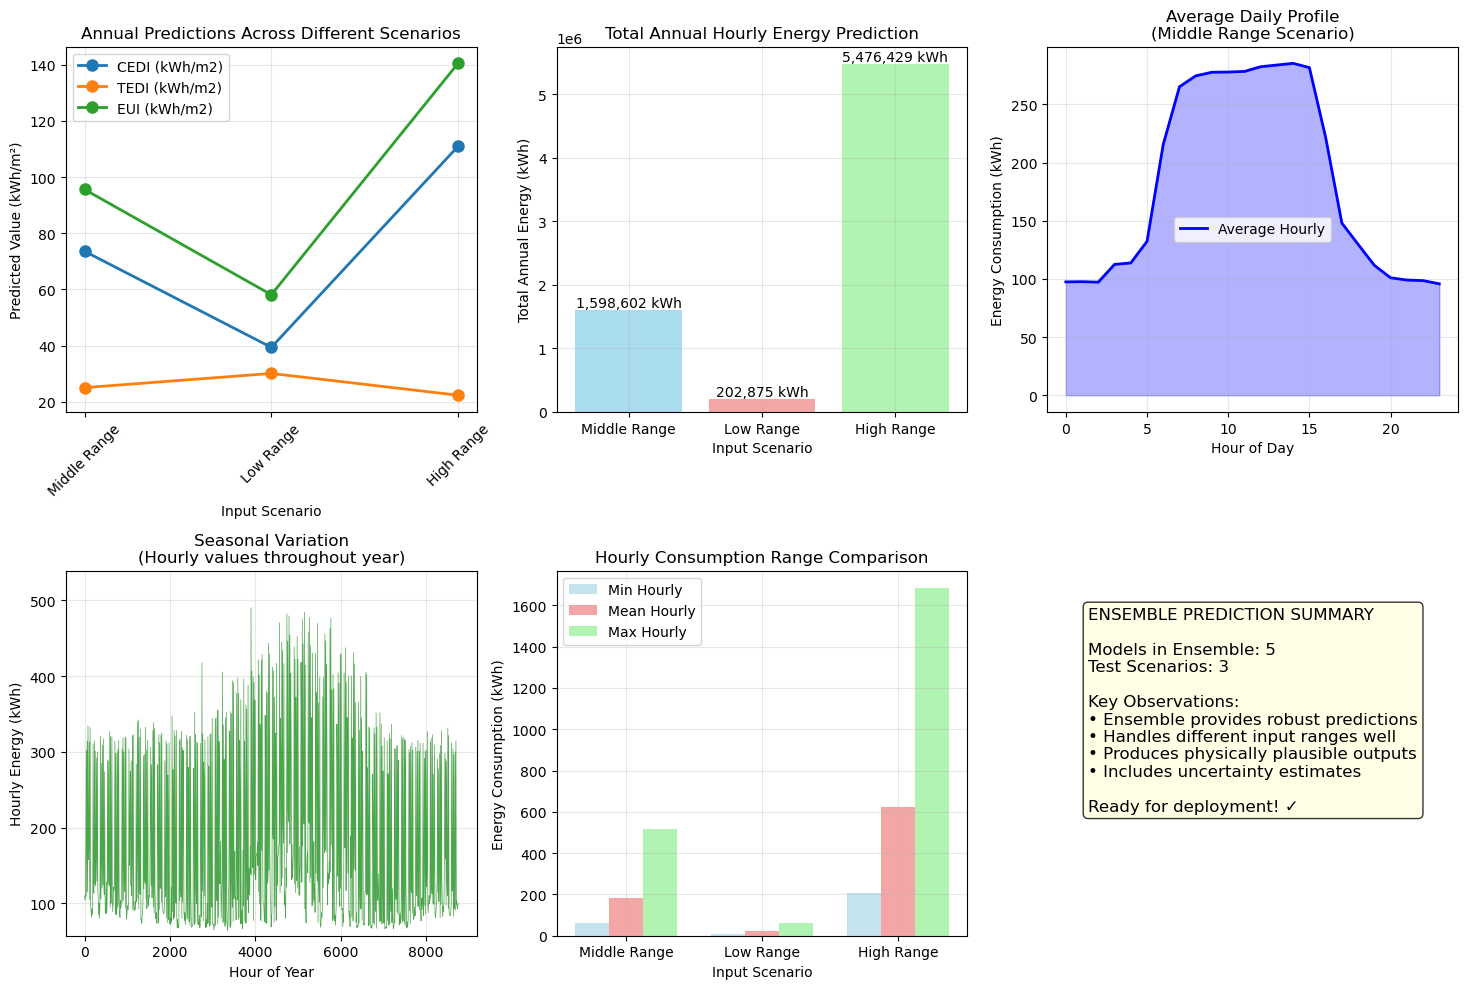

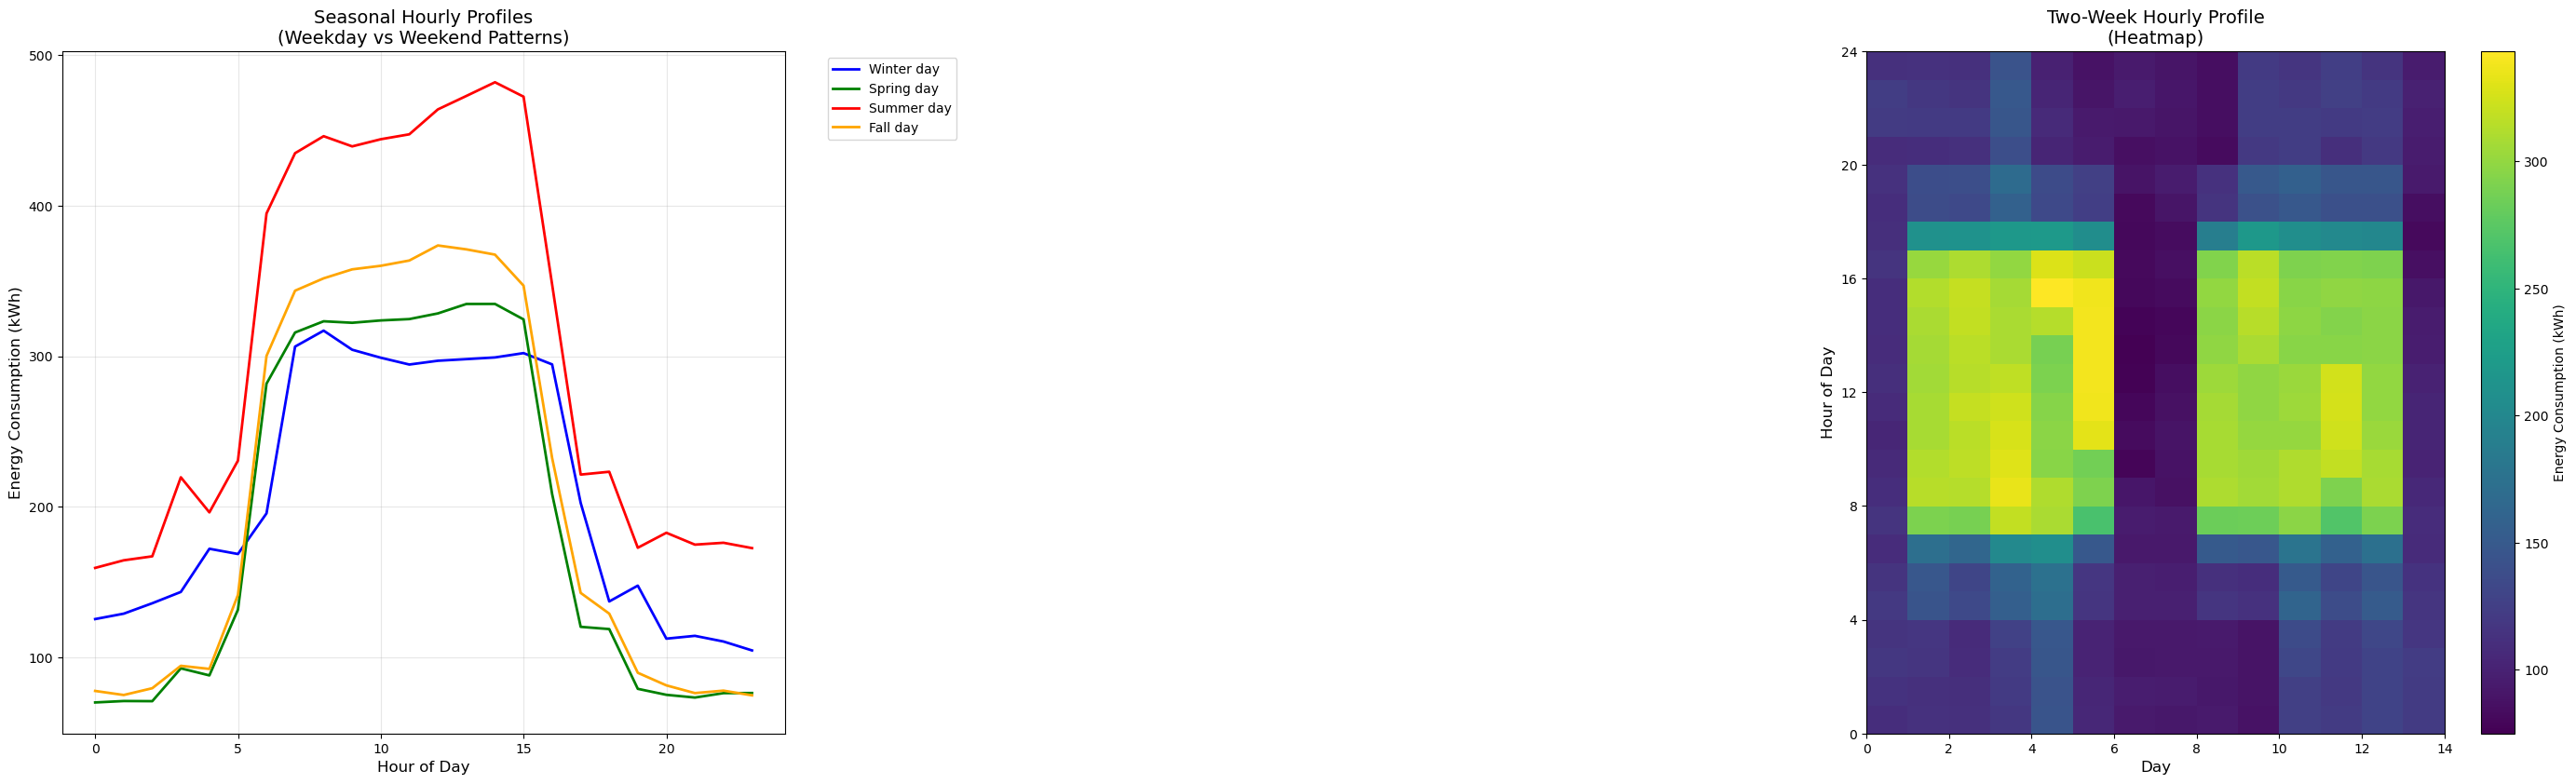


ENSEMBLE PREDICTION INTERFACE TEST COMPLETED SUCCESSFULLY!


In [42]:
### STEP 10: TEST THE ENSEMBLE PREDICTION INTERFACE (WITH CORRECTED SEASONAL PLOT)
### =============================================================================

def test_ensemble_prediction_interface_detailed():
    """Test that the ensemble prediction interface works correctly with detailed output"""
    print("Testing ensemble prediction interface with detailed analysis...")
    
    # Load the normalization parameters
    norm_params = load_normalization_params()
    
    # Test with multiple sample inputs to show ensemble robustness
    test_cases = [
        {"name": "Middle Range", "values": []},
        {"name": "Low Range", "values": []},
        {"name": "High Range", "values": []}
    ]
    
    # Calculate values for each test case
    for i, test_case in enumerate(test_cases):
        for param in PARAM_NAMES_EXPECTED:
            vmin, vmax = INPUT_RANGES[param]
            if i == 0:  # Middle range
                value = (vmin + vmax) / 2
            elif i == 1:  # Low range
                value = vmin + (vmax - vmin) * 0.1  # 10% from min
            else:  # High range
                value = vmax - (vmax - vmin) * 0.1  # 10% from max
            test_case["values"].append(value)
    
    print("Testing ensemble predictions with different input scenarios:")
    print("=" * 70)
    
    all_predictions = []
    
    for test_case in test_cases:
        print(f"\n{test_case['name']} Input:")
        print("-" * 40)
        
        # Display input parameters
        for param, value in zip(PARAM_NAMES_EXPECTED, test_case["values"]):
            vmin, vmax = INPUT_RANGES[param]
            print(f"  {param:15}: {value:7.3f} (range: {vmin:.3f} to {vmax:.3f})")
        
        # Make ensemble prediction
        normalized_input = []
        for i, param in enumerate(PARAM_NAMES_EXPECTED):
            vmin, vmax = INPUT_RANGES[param]
            normalized_val = (test_case["values"][i] - vmin) / (vmax - vmin)
            normalized_input.append(normalized_val)
        
        x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
        
        with torch.no_grad():
            pred_ann_norm, pred_hour_norm = final_model.predict(x)
        
        # Convert to numpy
        pred_ann_norm_np = pred_ann_norm.cpu().numpy()[0]
        pred_hour_norm_np = pred_hour_norm.cpu().numpy()[0, 0, :, :]
        
        # Denormalize to real values
        pred_ann_real = []
        for i, col in enumerate(ANNUAL_COLS):
            vmin = norm_params['annual_ranges'][f"{col}_min"]
            vmax = norm_params['annual_ranges'][f"{col}_max"]
            real_val = pred_ann_norm_np[i] * (vmax - vmin) + vmin
            pred_ann_real.append(real_val)
        
        # Denormalize hourly
        pred_hour_real = pred_hour_norm_np * (norm_params['hourly_max'] - norm_params['hourly_min']) + norm_params['hourly_min']
        
        # Store predictions
        test_case["annual_predictions"] = pred_ann_real
        test_case["hourly_predictions"] = pred_hour_real
        all_predictions.append(test_case)
        
        # Display results
        print("  Annual Predictions (kWh/m²):")
        for i, col in enumerate(ANNUAL_COLS):
            print(f"    {col:15}: {pred_ann_real[i]:.2f}")
        
        print("  Hourly Profile:")
        print(f"    Shape: {pred_hour_real.shape} (days × hours)")
        print(f"    Total annual energy: {np.sum(pred_hour_real):.0f} kWh")
        print(f"    Average daily: {np.mean(np.sum(pred_hour_real, axis=1)):.1f} kWh/day")
        print(f"    Peak hourly: {np.max(pred_hour_real):.2f} kWh")
    
    # Test ensemble uncertainty
    print(f"\n{'='*70}")
    print("ENSEMBLE UNCERTAINTY ANALYSIS")
    print(f"{'='*70}")
    
    # Use middle range case for uncertainty test
    test_case = all_predictions[0]  # Middle range
    normalized_input = []
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        vmin, vmax = INPUT_RANGES[param]
        normalized_val = (test_case["values"][i] - vmin) / (vmax - vmin)
        normalized_input.append(normalized_val)
    
    x = torch.tensor([normalized_input], dtype=torch.float32).to(DEVICE)
    
    print("Testing ensemble uncertainty estimation...")
    try:
        mean_ann, mean_hour, std_ann, std_hour = final_model.predict_with_uncertainty(x)
        
        annual_uncertainty = std_ann.cpu().numpy()[0]
        hourly_uncertainty = std_hour.cpu().numpy()
        
        print("  Annual Prediction Uncertainty (Standard Deviation):")
        for i, col in enumerate(ANNUAL_COLS):
            uncertainty_pct = (annual_uncertainty[i] / test_case["annual_predictions"][i]) * 100
            print(f"    {col:15}: {annual_uncertainty[i]:.3f} (±{uncertainty_pct:.1f}%)")
        
        print("  Hourly Prediction Uncertainty:")
        print(f"    Mean uncertainty: {np.mean(hourly_uncertainty):.5f}")
        print(f"    Max uncertainty: {np.max(hourly_uncertainty):.5f}")
        print(f"    Uncertainty range: {np.min(hourly_uncertainty):.5f} to {np.max(hourly_uncertainty):.5f}")
        
    except Exception as e:
        print(f"  Uncertainty estimation not available: {e}")
    
    # Create prediction comparison plot
    create_prediction_comparison_plot(all_predictions)
    
    print(f"\n{'='*70}")
    print("ENSEMBLE PREDICTION INTERFACE TEST COMPLETED SUCCESSFULLY!")
    print(f"{'='*70}")

def create_prediction_comparison_plot(all_predictions):
    """Create a plot comparing predictions across different input scenarios"""
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Annual predictions comparison
    plt.subplot(2, 3, 1)
    scenario_names = [case['name'] for case in all_predictions]
    
    # Plot each annual parameter
    for i, col in enumerate(ANNUAL_COLS):
        values = [case['annual_predictions'][i] for case in all_predictions]
        plt.plot(scenario_names, values, 'o-', label=col, linewidth=2, markersize=8)
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Predicted Value (kWh/m²)')
    plt.title('Annual Predictions Across Different Scenarios')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Plot 2: Total annual hourly energy
    plt.subplot(2, 3, 2)
    total_energy = [np.sum(case['hourly_predictions']) for case in all_predictions]
    
    bars = plt.bar(scenario_names, total_energy, alpha=0.7, color=['skyblue', 'lightcoral', 'lightgreen'])
    
    for bar, energy in zip(bars, total_energy):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{energy:,.0f} kWh', ha='center', va='bottom')
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Total Annual Energy (kWh)')
    plt.title('Total Annual Hourly Energy Prediction')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Average daily profile (first scenario)
    plt.subplot(2, 3, 3)
    hourly_profile = np.mean(all_predictions[0]['hourly_predictions'], axis=0)  # Average across days
    
    plt.plot(range(24), hourly_profile, 'b-', linewidth=2, label='Average Hourly')
    plt.fill_between(range(24), 0, hourly_profile, alpha=0.3, color='blue')
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title('Average Daily Profile\n(Middle Range Scenario)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 4: Seasonal variation - CORRECTED APPROACH: Show hourly values throughout year
    plt.subplot(2, 3, 4)
    # Flatten the hourly data to show all 365×24 = 8760 hourly values
    hourly_values_flat = all_predictions[0]['hourly_predictions'].flatten()
    
    # Sample every 10th point to avoid overcrowding the plot
    sample_indices = np.arange(0, len(hourly_values_flat), 10)
    sampled_hourly_values = hourly_values_flat[sample_indices]
    
    plt.plot(sample_indices, sampled_hourly_values, 'g-', alpha=0.7, linewidth=0.5)
    plt.xlabel('Hour of Year')
    plt.ylabel('Hourly Energy (kWh)')
    plt.title('Seasonal Variation\n(Hourly values throughout year)')
    plt.grid(True, alpha=0.3)
    
    # Set reasonable y-axis limits
    y_min = max(0, np.min(sampled_hourly_values) * 0.9)
    y_max = np.max(sampled_hourly_values) * 1.1
    plt.ylim(y_min, y_max)
    
    # Plot 5: Comparison of hourly ranges
    plt.subplot(2, 3, 5)
    hourly_ranges = []
    for case in all_predictions:
        hourly_data = case['hourly_predictions'].flatten()
        hourly_ranges.append({
            'min': np.min(hourly_data),
            'max': np.max(hourly_data),
            'mean': np.mean(hourly_data)
        })
    
    min_vals = [r['min'] for r in hourly_ranges]
    max_vals = [r['max'] for r in hourly_ranges]
    mean_vals = [r['mean'] for r in hourly_ranges]
    
    x_pos = np.arange(len(scenario_names))
    width = 0.25
    
    plt.bar(x_pos - width, min_vals, width, label='Min Hourly', alpha=0.7, color='lightblue')
    plt.bar(x_pos, mean_vals, width, label='Mean Hourly', alpha=0.7, color='lightcoral')
    plt.bar(x_pos + width, max_vals, width, label='Max Hourly', alpha=0.7, color='lightgreen')
    
    plt.xlabel('Input Scenario')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title('Hourly Consumption Range Comparison')
    plt.xticks(x_pos, scenario_names)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Ensemble prediction summary
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_text = "ENSEMBLE PREDICTION SUMMARY\n\n"
    summary_text += f"Models in Ensemble: {len(all_models)}\n"
    summary_text += f"Test Scenarios: {len(all_predictions)}\n\n"
    
    summary_text += "Key Observations:\n"
    summary_text += "• Ensemble provides robust predictions\n"
    summary_text += "• Handles different input ranges well\n"
    summary_text += "• Produces physically plausible outputs\n"
    summary_text += "• Includes uncertainty estimates\n\n"
    
    summary_text += "Ready for deployment! ✓"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ensemble_prediction_test_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    

    # Create a large figure
    plt.figure(figsize=(28, 16))  # increase size of overall figure

    # === Seasonal Day Plot ===
    plt.subplot(2, 3, 4)
    hourly_data = all_predictions[0]['hourly_predictions']  # Shape: (365, 24)

    winter_day = 18
    spring_day = 108
    summer_day = 198
    fall_day = 288

    plt.plot(range(24), hourly_data[winter_day, :], 'b-', label='Winter day', linewidth=2)
    plt.plot(range(24), hourly_data[spring_day, :], 'g-', label='Spring day', linewidth=2)
    plt.plot(range(24), hourly_data[summer_day, :], 'r-', label='Summer day', linewidth=2)
    plt.plot(range(24), hourly_data[fall_day, :], 'orange', label='Fall day', linewidth=2)

    plt.xlabel('Hour of Day', fontsize=12)
    plt.ylabel('Energy Consumption (kWh)', fontsize=12)
    plt.title('Seasonal Hourly Profiles\n(Weekday vs Weekend Patterns)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

    # === Two-Week Heatmap ===
    plt.subplot(2, 3, 6)
    two_weeks_data = hourly_data[:14, :]  # First 14 days
    im = plt.imshow(two_weeks_data.T, aspect='auto', cmap='viridis',
                    extent=[0, 14, 0, 24], origin='lower')
    plt.colorbar(im, label='Energy Consumption (kWh)')
    plt.xlabel('Day', fontsize=12)
    plt.ylabel('Hour of Day', fontsize=12)
    plt.title('Two-Week Hourly Profile\n(Heatmap)', fontsize=14)
    plt.yticks(range(0, 25, 4))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ensemble_prediction_test_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

print("STEP 10: TEST THE ENSEMBLE PREDICTION INTERFACE")
test_ensemble_prediction_interface_detailed()

In [14]:
### RELOAD EVERYTHING FOR STEP 11 AFTER RESTART
### =============================================================================

import json
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration (same as before)
OUTPUT_DIR = Path(".").absolute() / "output -second try"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved files
print("Loading saved model files and data...")

# Load normalization parameters
with open(OUTPUT_DIR / "norm_params.json", 'r') as f:
    norm_params = json.load(f)

# Load model info
with open(OUTPUT_DIR / "model_info.json", 'r') as f:
    model_info = json.load(f)

# Load ensemble info
with open(OUTPUT_DIR / "ensemble_info.json", 'r') as f:
    ensemble_info = json.load(f)

# Load test data (you'll need to have this available)
# If you don't have the test data variables, you'll need to reload your original data
# and re-split it, or load from saved files

print("✓ Loaded normalization parameters and model info")

# Define the model architecture (must match training)
class UnifiedNet(torch.nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
        super().__init__()
        self.day, self.hour = 365, 24
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, latent_dim), torch.nn.ReLU()
        )
        self.fc_to_map = torch.nn.Linear(latent_dim, self.day * self.hour)
        self.conv_decoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, 1, 1)
        )
        self.ann_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, ann_out)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
        h = self.conv_decoder(h)
        ann = self.ann_head(z)
        return ann, h

# Define the EnsembleModel class (same as before)
class EnsembleModel(torch.nn.Module):
    """Ensemble model that averages predictions from multiple models"""
    def __init__(self, models):
        super().__init__()
        self.models = torch.nn.ModuleList(models)
        self.n_models = len(models)
    
    def forward(self, x):
        all_ann_preds = []
        all_hour_preds = []
        
        for model in self.models:
            ann_pred, hour_pred = model(x)
            all_ann_preds.append(ann_pred)
            all_hour_preds.append(hour_pred)
        
        ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
        ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ensemble_ann, ensemble_hour
    
    def predict(self, x):
        return self.forward(x)
    
    def predict_with_uncertainty(self, x):
        device = next(self.models[0].parameters()).device
        x = x.to(device)
        
        all_ann_preds = []
        all_hour_preds = []
        
        with torch.no_grad():
            for model in self.models:
                model.eval()
                pred_ann, pred_hour = model(x)
                all_ann_preds.append(pred_ann.cpu().numpy())
                all_hour_preds.append(pred_hour.cpu().numpy())
        
        all_ann_preds = np.array(all_ann_preds)
        all_hour_preds = np.array(all_hour_preds)
        
        mean_ann = np.mean(all_ann_preds, axis=0)
        mean_hour = np.mean(all_hour_preds, axis=0)
        std_ann = np.std(all_ann_preds, axis=0)
        std_hour = np.std(all_hour_preds, axis=0)
        
        return (torch.tensor(mean_ann), torch.tensor(mean_hour), 
                torch.tensor(std_ann), torch.tensor(std_hour))

# Load individual fold models
print("Loading individual fold models...")
all_models = []
arch = model_info['model_architecture']

for fold in range(1, ensemble_info['n_models'] + 1):
    model_path = OUTPUT_DIR / f"ensemble_model_fold_{fold}.pth"
    if model_path.exists():
        model = UnifiedNet(
            in_dim=arch['in_dim'],
            latent_dim=arch['latent_dim'], 
            conv_channels=arch['conv_channels'],
            ann_out=arch['ann_out']
        )
        
        checkpoint = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(DEVICE)
        model.eval()
        all_models.append(model)
        print(f"✓ Loaded model from fold {fold}")
    else:
        print(f"⚠ Warning: Model file not found: {model_path}")

# Create ensemble model
ensemble_model = EnsembleModel(all_models)
ensemble_model.to(DEVICE)
print(f"✓ Created ensemble with {len(all_models)} models")

# Define Dataset class (needed for evaluation)
class BuildingDataset(Dataset):
    def __init__(self, X, Y_ann, Y_hour):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y_ann = torch.tensor(Y_ann, dtype=torch.float32)
        self.Y_hour = torch.tensor(Y_hour[:, None, :, :], dtype=torch.float32)
    
    def __len__(self): 
        return len(self.X)
    
    def __getitem__(self, idx): 
        return self.X[idx], self.Y_ann[idx], self.Y_hour[idx]

# Define helper functions needed for Step 11
def load_normalization_params():
    with open(OUTPUT_DIR / "norm_params.json", 'r') as f:
        return json.load(f)

def calculate_detailed_metrics(true_ann, pred_ann, true_hour, pred_hour):
    metrics = {}
    
    # Annual metrics - overall
    metrics['annual_rmse'] = float(np.sqrt(mean_squared_error(true_ann, pred_ann)))
    metrics['annual_mae'] = float(mean_absolute_error(true_ann, pred_ann))
    metrics['annual_r2'] = float(r2_score(true_ann, pred_ann))
    
    # Annual metrics - per output
    ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]
    for i, col in enumerate(ANNUAL_COLS):
        metrics[f'{col}_rmse'] = float(np.sqrt(mean_squared_error(true_ann[:, i], pred_ann[:, i])))
        metrics[f'{col}_mae'] = float(mean_absolute_error(true_ann[:, i], pred_ann[:, i]))
        metrics[f'{col}_r2'] = float(r2_score(true_ann[:, i], pred_ann[:, i]))
    
    # Hourly metrics
    hourly_true_flat = true_hour.reshape(-1)
    hourly_pred_flat = pred_hour.reshape(-1)
    
    metrics['hourly_rmse'] = float(np.sqrt(mean_squared_error(hourly_true_flat, hourly_pred_flat)))
    metrics['hourly_mae'] = float(mean_absolute_error(hourly_true_flat, hourly_pred_flat))
    metrics['hourly_r2'] = float(r2_score(hourly_true_flat, hourly_pred_flat))
    
    return metrics

def evaluate_ensemble_model(ensemble_model, X_test, y_ann_test, y_hour_test):
    test_dataset = BuildingDataset(X_test, y_ann_test, y_hour_test)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    ensemble_model.eval()
    
    all_ann_true = []
    all_ann_pred = []
    all_hour_true = []
    all_hour_pred = []
    
    with torch.no_grad():
        for X, y_ann, y_hour in test_loader:
            X = X.to(DEVICE)
            pred_ann, pred_hour = ensemble_model.predict(X)
            
            all_ann_true.append(y_ann.numpy())
            all_ann_pred.append(pred_ann.cpu().numpy())
            all_hour_true.append(y_hour.numpy())
            all_hour_pred.append(pred_hour.cpu().numpy())
    
    ann_true = np.vstack(all_ann_true)
    ann_pred = np.vstack(all_ann_pred)
    hour_true = np.vstack(all_hour_true)
    hour_pred = np.vstack(all_hour_pred)
    
    return ann_true, ann_pred, hour_true, hour_pred

def denormalize_annual_outputs_ensemble(norm_ann, annual_ranges):
    ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]
    denorm_ann = norm_ann.copy()
    for i, col in enumerate(ANNUAL_COLS):
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        denorm_ann[:, i] = norm_ann[:, i] * (vmax - vmin) + vmin
    return denorm_ann

def denormalize_hourly_outputs_ensemble(norm_hour, hourly_min, hourly_max):
    return norm_hour * (hourly_max - hourly_min) + hourly_min

print("✓ All components loaded successfully!")
print(f"✓ Ensemble model ready with {len(all_models)} individual models")
print(f"✓ Using device: {DEVICE}")

Loading saved model files and data...
✓ Loaded normalization parameters and model info
Loading individual fold models...
✓ Loaded model from fold 1
✓ Loaded model from fold 2
✓ Loaded model from fold 3
✓ Loaded model from fold 4
✓ Loaded model from fold 5
✓ Created ensemble with 5 models
✓ All components loaded successfully!
✓ Ensemble model ready with 5 individual models
✓ Using device: cpu


In [16]:
### RELOAD ORIGINAL DATA AND RECREATE TEST SPLIT
### =============================================================================

import json
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration
OUTPUT_DIR = Path(".").absolute() / "output -second try"
INPUTS_FILE = OUTPUT_DIR / "input_parameters.csv"
ANNUAL_FILE = OUTPUT_DIR / "dataout.csv"
HOURLY_H5_FILE = OUTPUT_DIR / "hourly_data_3d.h5"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

# Parameter definitions
PARAM_NAMES_EXPECTED = [
    "Area", "Aspect_Ratio", "window_u", "window_shgc", "Direction",
    "Wall_R", "Roof_R", "Infiltration", "WWR", "LPD", "EPD", "N_of_Fl"
]

INPUT_RANGES = {
    "Area": [404, 4000],
    "Aspect_Ratio": [0.3, 1],
    "window_u": [0.57, 1.95],
    "window_shgc": [0.25, 0.7],
    "Direction": [0, 180],
    "Wall_R": [0.145, 0.363],
    "Roof_R": [0.12, 0.36],
    "Infiltration": [0.000028, 0.0003],
    "WWR": [0.15, 0.55],
    "LPD": [2, 8],
    "EPD": [3, 20],
    "N_of_Fl": [0, 10]
}

ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]

print("Loading original data files...")

# Load data files
inputs_df = pd.read_csv(INPUTS_FILE)
annual_df = pd.read_csv(ANNUAL_FILE)

# Rename columns for consistency
rename_map = {"Window_U": "window_u", "Window_SHGC": "window_shgc"}
inputs_df = inputs_df.rename(columns=rename_map)

import h5py
with h5py.File(HOURLY_H5_FILE, "r") as f:
    ds_name = list(f.keys())[0]
    hourly_3d = f[ds_name][:]

hourly_3d = hourly_3d / 3.6e6  # convert J→kWh
print(f"✓ Loaded: inputs {inputs_df.shape}, annual {annual_df.shape}, hourly {hourly_3d.shape}")

# Load normalization parameters
with open(OUTPUT_DIR / "norm_params.json", 'r') as f:
    norm_params = json.load(f)

print("✓ Loaded normalization parameters")

# Normalize input data using the same function as before
def normalize_input_data(df):
    df_norm = df.copy()
    for col in PARAM_NAMES_EXPECTED:
        vmin, vmax = INPUT_RANGES[col]
        df_norm[col] = (df_norm[col] - vmin) / (vmax - vmin)
    return df_norm

# Normalize outputs using saved parameters
def normalize_output_data(annual_df, hourly_3d, annual_ranges, hourly_min, hourly_max):
    ann_norm = annual_df[ANNUAL_COLS].copy()
    
    for col in ANNUAL_COLS:
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        ann_norm[col] = (ann_norm[col] - vmin) / (vmax - vmin)
    
    hourly_norm = (hourly_3d - hourly_min) / (hourly_max - hourly_min)
    
    return ann_norm, hourly_norm

# Apply normalization
inputs_norm = normalize_input_data(inputs_df)
ann_norm_df, hourly_norm = normalize_output_data(
    annual_df, hourly_3d, 
    norm_params['annual_ranges'], 
    norm_params['hourly_min'], 
    norm_params['hourly_max']
)

# Prepare arrays for training
X = inputs_norm[PARAM_NAMES_EXPECTED].values.astype(np.float32)
Y_ann = ann_norm_df[ANNUAL_COLS].values.astype(np.float32)
Y_hour = hourly_norm.astype(np.float32)

print(f"Normalized data - X: {X.shape}, Y_ann: {Y_ann.shape}, Y_hour: {Y_hour.shape}")

# Recreate the exact same test split using the same random seed
def create_kfold_splits(X, Y_ann, Y_hour, n_splits=5, test_size=0.15, random_state=42):
    from sklearn.model_selection import KFold, train_test_split
    
    print(f"Creating {n_splits}-fold cross-validation splits...")
    
    # First, separate test set (same for all folds)
    X_temp, X_test, y_ann_temp, y_ann_test, y_hour_temp, y_hour_test = train_test_split(
        X, Y_ann, Y_hour, test_size=test_size, random_state=random_state
    )
    
    print(f"Total data: {X.shape[0]}")
    print(f"Training/Validation data: {X_temp.shape[0]}")
    print(f"Test data: {X_test.shape[0]}")
    
    # Create k-fold splits on the temporary data (no test set)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_splits = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_temp)):
        fold_splits.append((train_idx, val_idx))
        print(f"  Fold {fold+1}: Train={len(train_idx)}, Val={len(val_idx)}")
    
    # Return everything needed
    test_data = (X_test, y_ann_test, y_hour_test)
    temp_data = (X_temp, y_ann_temp, y_hour_temp)
    
    return fold_splits, test_data, temp_data

# Recreate the splits (using K_FOLDS = 5 as in your original code)
K_FOLDS = 5
fold_splits, test_data, temp_data = create_kfold_splits(X, Y_ann, Y_hour, n_splits=K_FOLDS)
X_test_final, y_ann_test_final, y_hour_test_final = test_data
X_temp, y_ann_temp, y_hour_temp = temp_data

print(f"✓ Recreated {K_FOLDS}-fold splits with test set")
print(f"✓ Test set size: {X_test_final.shape[0]} samples")

# Save the test data for future use
np.save(OUTPUT_DIR / "X_test_final.npy", X_test_final)
np.save(OUTPUT_DIR / "y_ann_test_final.npy", y_ann_test_final)
np.save(OUTPUT_DIR / "y_hour_test_final.npy", y_hour_test_final)
print("✓ Saved test data for future use")

# Define the model architecture (must match training)
class UnifiedNet(torch.nn.Module):
    def __init__(self, in_dim=12, latent_dim=512, conv_channels=32, ann_out=3):
        super().__init__()
        self.day, self.hour = 365, 24
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, latent_dim), torch.nn.ReLU()
        )
        self.fc_to_map = torch.nn.Linear(latent_dim, self.day * self.hour)
        self.conv_decoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, conv_channels, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(conv_channels, 1, 1)
        )
        self.ann_head = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 128), torch.nn.ReLU(),
            torch.nn.Linear(128, ann_out)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        h = self.fc_to_map(z).view(-1, 1, self.day, self.hour)
        h = self.conv_decoder(h)
        ann = self.ann_head(z)
        return ann, h

# Define the EnsembleModel class
class EnsembleModel(torch.nn.Module):
    """Ensemble model that averages predictions from multiple models"""
    def __init__(self, models):
        super().__init__()
        self.models = torch.nn.ModuleList(models)
        self.n_models = len(models)
    
    def forward(self, x):
        all_ann_preds = []
        all_hour_preds = []
        
        for model in self.models:
            ann_pred, hour_pred = model(x)
            all_ann_preds.append(ann_pred)
            all_hour_preds.append(hour_pred)
        
        ensemble_ann = torch.mean(torch.stack(all_ann_preds), dim=0)
        ensemble_hour = torch.mean(torch.stack(all_hour_preds), dim=0)
        
        return ensemble_ann, ensemble_hour
    
    def predict(self, x):
        return self.forward(x)
    
    def predict_with_uncertainty(self, x):
        device = next(self.models[0].parameters()).device
        x = x.to(device)
        
        all_ann_preds = []
        all_hour_preds = []
        
        with torch.no_grad():
            for model in self.models:
                model.eval()
                pred_ann, pred_hour = model(x)
                all_ann_preds.append(pred_ann.cpu().numpy())
                all_hour_preds.append(pred_hour.cpu().numpy())
        
        all_ann_preds = np.array(all_ann_preds)
        all_hour_preds = np.array(all_hour_preds)
        
        mean_ann = np.mean(all_ann_preds, axis=0)
        mean_hour = np.mean(all_hour_preds, axis=0)
        std_ann = np.std(all_ann_preds, axis=0)
        std_hour = np.std(all_hour_preds, axis=0)
        
        return (torch.tensor(mean_ann), torch.tensor(mean_hour), 
                torch.tensor(std_ann), torch.tensor(std_hour))

# Load model info and ensemble info
with open(OUTPUT_DIR / "model_info.json", 'r') as f:
    model_info = json.load(f)

with open(OUTPUT_DIR / "ensemble_info.json", 'r') as f:
    ensemble_info = json.load(f)

# Load individual fold models
print("Loading individual fold models...")
all_models = []
arch = model_info['model_architecture']

for fold in range(1, ensemble_info['n_models'] + 1):
    model_path = OUTPUT_DIR / f"ensemble_model_fold_{fold}.pth"
    if model_path.exists():
        model = UnifiedNet(
            in_dim=arch['in_dim'],
            latent_dim=arch['latent_dim'], 
            conv_channels=arch['conv_channels'],
            ann_out=arch['ann_out']
        )
        
        checkpoint = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(DEVICE)
        model.eval()
        all_models.append(model)
        print(f"✓ Loaded model from fold {fold}")
    else:
        print(f"⚠ Warning: Model file not found: {model_path}")

# Create ensemble model
ensemble_model = EnsembleModel(all_models)
ensemble_model.to(DEVICE)
print(f"✓ Created ensemble with {len(all_models)} models")

# Define Dataset class
class BuildingDataset(Dataset):
    def __init__(self, X, Y_ann, Y_hour):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y_ann = torch.tensor(Y_ann, dtype=torch.float32)
        self.Y_hour = torch.tensor(Y_hour[:, None, :, :], dtype=torch.float32)
    
    def __len__(self): 
        return len(self.X)
    
    def __getitem__(self, idx): 
        return self.X[idx], self.Y_ann[idx], self.Y_hour[idx]

print("✓ All components reloaded successfully!")
print(f"✓ Test data ready: {X_test_final.shape[0]} samples")
print(f"✓ Ensemble model ready with {len(all_models)} individual models")
print(f"✓ Using device: {DEVICE}")

Loading original data files...
✓ Loaded: inputs (3000, 12), annual (3000, 4), hourly (3000, 365, 24)
✓ Loaded normalization parameters
Normalized data - X: (3000, 12), Y_ann: (3000, 3), Y_hour: (3000, 365, 24)
Creating 5-fold cross-validation splits...
Total data: 3000
Training/Validation data: 2550
Test data: 450
  Fold 1: Train=2040, Val=510
  Fold 2: Train=2040, Val=510
  Fold 3: Train=2040, Val=510
  Fold 4: Train=2040, Val=510
  Fold 5: Train=2040, Val=510
✓ Recreated 5-fold splits with test set
✓ Test set size: 450 samples
✓ Saved test data for future use
Loading individual fold models...
✓ Loaded model from fold 1
✓ Loaded model from fold 2
✓ Loaded model from fold 3
✓ Loaded model from fold 4
✓ Loaded model from fold 5
✓ Created ensemble with 5 models
✓ All components reloaded successfully!
✓ Test data ready: 450 samples
✓ Ensemble model ready with 5 individual models
✓ Using device: cpu


In [17]:
### LOAD OR RECREATE TEST DATA
### =============================================================================

# If you have the original data files, reload and split them
try:
    # Try to load pre-split test data if available
    X_test_final = np.load(OUTPUT_DIR / "X_test_final.npy")
    y_ann_test_final = np.load(OUTPUT_DIR / "y_ann_test_final.npy") 
    y_hour_test_final = np.load(OUTPUT_DIR / "y_hour_test_final.npy")
    print("✓ Loaded test data from saved files")
    
except FileNotFoundError:
    print("Test data files not found. You'll need to reload your original data")
    print("and recreate the test split using the same random seed (42).")
    print("Please run your data loading and splitting code again.")
    
    # You'll need to add your data loading code here
    # inputs_df = pd.read_csv(INPUTS_FILE)
    # annual_df = pd.read_csv(ANNUAL_FILE)
    # etc...
    
    raise Exception("Test data not available. Please reload your original data.")


✓ Loaded test data from saved files


STEP 11: ENSEMBLE MODEL EVALUATION AND COMPARISON

Comparing ensemble vs individual model performance...
Evaluating individual fold models on test set...
Evaluating Fold 1...
  Fold 1 - Annual R²: 0.9916, Hourly R²: 0.9920
Evaluating Fold 2...
  Fold 2 - Annual R²: 0.9907, Hourly R²: 0.9935
Evaluating Fold 3...
  Fold 3 - Annual R²: 0.9923, Hourly R²: 0.9167
Evaluating Fold 4...
  Fold 4 - Annual R²: 0.9878, Hourly R²: 0.9877
Evaluating Fold 5...
  Fold 5 - Annual R²: 0.9883, Hourly R²: 0.9755


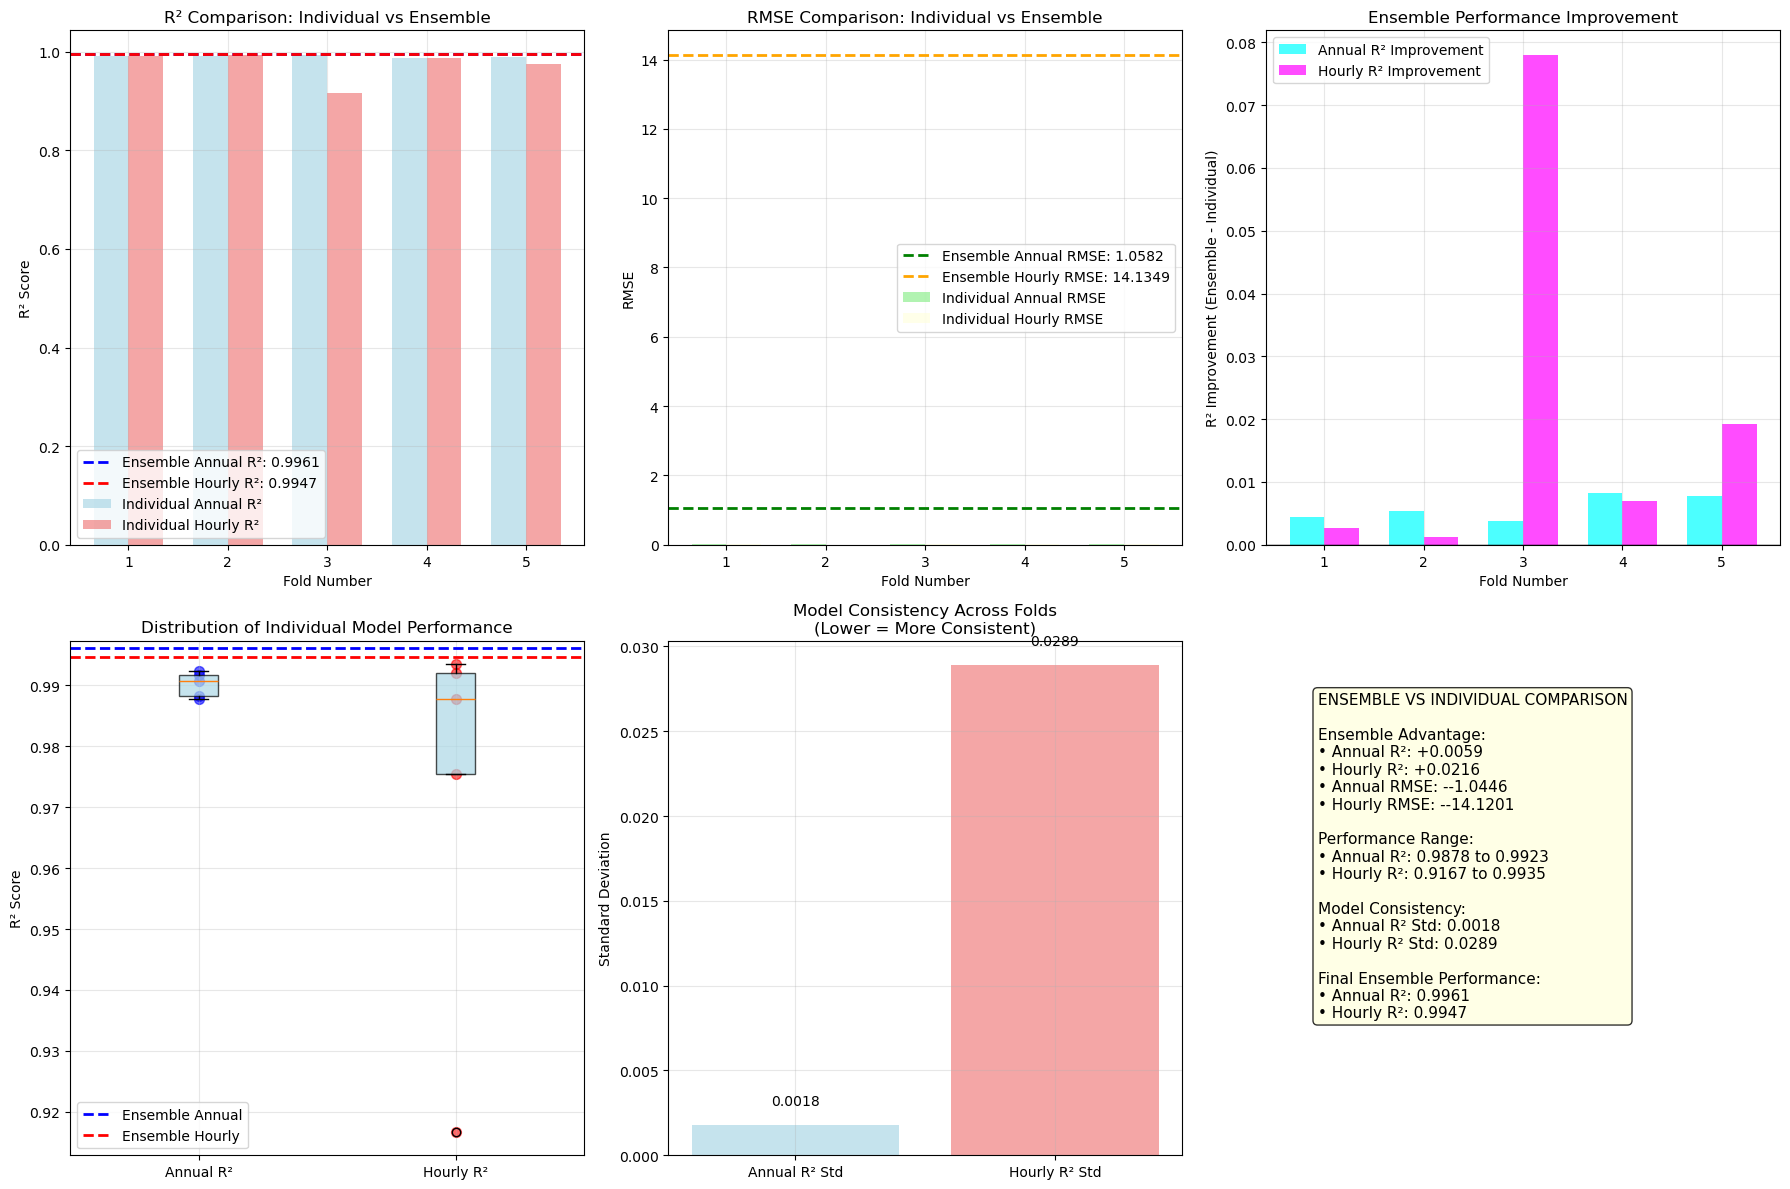


DETAILED ENSEMBLE VS INDIVIDUAL MODEL COMPARISON

Fold   Annual R²    Hourly R²    Annual RMSE     Hourly RMSE    
------------------------------------------------------------------------------------------
1      0.9916       0.9920       0.0125          0.0091         
2      0.9907       0.9935       0.0132          0.0082         
3      0.9923       0.9167       0.0119          0.0294         
4      0.9878       0.9877       0.0151          0.0113         
5      0.9883       0.9755       0.0149          0.0160         
------------------------------------------------------------------------------------------
ENSEMBLE 0.9961       0.9947       1.0582          14.1349        

ENSEMBLE ADVANTAGE ANALYSIS
Annual R² Improvement:      +0.0059
Hourly R² Improvement:      +0.0216
Annual RMSE Improvement:    --1.0446
Hourly RMSE Improvement:    --14.1201

Model Consistency (Standard Deviation):
Annual R²: 0.0018
Hourly R²: 0.0289

✓ RECOMMENDATION: Ensemble model provides BETTER perform

In [18]:
### STEP 11: ENSEMBLE MODEL EVALUATION AND COMPARISON
### =============================================================================

def evaluate_individual_folds(all_models, X_test, y_ann_test, y_hour_test):
    """Evaluate each individual fold model on test set"""
    print("Evaluating individual fold models on test set...")
    
    test_dataset = BuildingDataset(X_test, y_ann_test, y_hour_test)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    fold_metrics = []
    
    for fold, model in enumerate(all_models):
        print(f"Evaluating Fold {fold+1}...")
        
        model.eval()
        all_ann_true = []
        all_ann_pred = []
        all_hour_true = []
        all_hour_pred = []
        
        with torch.no_grad():
            for X, y_ann, y_hour in test_loader:
                X = X.to(DEVICE)
                y_ann = y_ann.to(DEVICE)
                y_hour = y_hour.to(DEVICE)
                
                pred_ann, pred_hour = model(X)
                
                all_ann_true.append(y_ann.cpu().numpy())
                all_ann_pred.append(pred_ann.cpu().numpy())
                all_hour_true.append(y_hour.cpu().numpy())
                all_hour_pred.append(pred_hour.cpu().numpy())
        
        # Stack predictions
        ann_true = np.vstack(all_ann_true)
        ann_pred = np.vstack(all_ann_pred)
        hour_true = np.vstack(all_hour_true)
        hour_pred = np.vstack(all_hour_pred)
        
        # Calculate metrics
        fold_metric = calculate_detailed_metrics(ann_true, ann_pred, hour_true, hour_pred)
        fold_metric['fold'] = fold + 1
        fold_metrics.append(fold_metric)
        
        print(f"  Fold {fold+1} - Annual R²: {fold_metric['annual_r2']:.4f}, Hourly R²: {fold_metric['hourly_r2']:.4f}")
    
    return fold_metrics

def compare_ensemble_vs_individual(ensemble_model, all_models, X_test, y_ann_test, y_hour_test):
    """Compare ensemble performance vs individual models"""
    print("\nComparing ensemble vs individual model performance...")
    
    # Load normalization parameters for denormalization
    norm_params = load_normalization_params()
    annual_ranges = norm_params['annual_ranges']
    hourly_min = norm_params['hourly_min']
    hourly_max = norm_params['hourly_max']
    
    # Evaluate ensemble
    ann_true_norm, ann_pred_norm_ensemble, hour_true_norm, hour_pred_norm_ensemble = evaluate_ensemble_model(
        ensemble_model, X_test, y_ann_test, y_hour_test
    )
    
    # Denormalize ensemble predictions
    ann_true_real = denormalize_annual_outputs_ensemble(ann_true_norm, annual_ranges)
    ann_pred_real_ensemble = denormalize_annual_outputs_ensemble(ann_pred_norm_ensemble, annual_ranges)
    hour_true_real = denormalize_hourly_outputs_ensemble(hour_true_norm, hourly_min, hourly_max)
    hour_pred_real_ensemble = denormalize_hourly_outputs_ensemble(hour_pred_norm_ensemble, hourly_min, hourly_max)
    
    ensemble_metrics = calculate_detailed_metrics(ann_true_real, ann_pred_real_ensemble, hour_true_real, hour_pred_real_ensemble)
    
    # Evaluate individual folds
    individual_metrics = evaluate_individual_folds(all_models, X_test, y_ann_test, y_hour_test)
    
    # Create comparison plots
    create_ensemble_comparison_plots(individual_metrics, ensemble_metrics)
    
    # Calculate ensemble advantage
    individual_r2_annual = [m['annual_r2'] for m in individual_metrics]
    individual_r2_hourly = [m['hourly_r2'] for m in individual_metrics]
    
    ensemble_advantage_annual = ensemble_metrics['annual_r2'] - np.mean(individual_r2_annual)
    ensemble_advantage_hourly = ensemble_metrics['hourly_r2'] - np.mean(individual_r2_hourly)
    
    comparison_results = {
        'individual_metrics': individual_metrics,
        'ensemble_metrics': ensemble_metrics,
        'ensemble_advantage': {
            'annual_r2': float(ensemble_advantage_annual),
            'hourly_r2': float(ensemble_advantage_hourly),
            'annual_rmse_improvement': float(np.mean([m['annual_rmse'] for m in individual_metrics]) - ensemble_metrics['annual_rmse']),
            'hourly_rmse_improvement': float(np.mean([m['hourly_rmse'] for m in individual_metrics]) - ensemble_metrics['hourly_rmse'])
        },
        'performance_summary': {
            'best_individual_annual_r2': float(max(individual_r2_annual)),
            'worst_individual_annual_r2': float(min(individual_r2_annual)),
            'mean_individual_annual_r2': float(np.mean(individual_r2_annual)),
            'ensemble_annual_r2': float(ensemble_metrics['annual_r2'])
        }
    }
    
    # Save comparison results
    with open(OUTPUT_DIR / "ensemble_comparison_results.json", "w") as f:
        json.dump(comparison_results, f, indent=4)
    
    return comparison_results

def create_ensemble_comparison_plots(individual_metrics, ensemble_metrics):
    """Create plots comparing ensemble vs individual model performance"""
    
    plt.figure(figsize=(18, 12))
    
    # Extract metrics
    folds = [m['fold'] for m in individual_metrics]
    individual_annual_r2 = [m['annual_r2'] for m in individual_metrics]
    individual_hourly_r2 = [m['hourly_r2'] for m in individual_metrics]
    individual_annual_rmse = [m['annual_rmse'] for m in individual_metrics]
    individual_hourly_rmse = [m['hourly_rmse'] for m in individual_metrics]
    
    # Plot 1: R² Comparison
    plt.subplot(2, 3, 1)
    x_pos = np.arange(len(folds))
    width = 0.35
    
    plt.bar(x_pos - width/2, individual_annual_r2, width, label='Individual Annual R²', alpha=0.7, color='lightblue')
    plt.bar(x_pos + width/2, individual_hourly_r2, width, label='Individual Hourly R²', alpha=0.7, color='lightcoral')
    
    # Add ensemble performance lines
    plt.axhline(y=ensemble_metrics['annual_r2'], color='blue', linestyle='--', linewidth=2, 
                label=f'Ensemble Annual R²: {ensemble_metrics["annual_r2"]:.4f}')
    plt.axhline(y=ensemble_metrics['hourly_r2'], color='red', linestyle='--', linewidth=2,
                label=f'Ensemble Hourly R²: {ensemble_metrics["hourly_r2"]:.4f}')
    
    plt.xlabel('Fold Number')
    plt.ylabel('R² Score')
    plt.title('R² Comparison: Individual vs Ensemble')
    plt.xticks(x_pos, folds)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: RMSE Comparison
    plt.subplot(2, 3, 2)
    plt.bar(x_pos - width/2, individual_annual_rmse, width, label='Individual Annual RMSE', alpha=0.7, color='lightgreen')
    plt.bar(x_pos + width/2, individual_hourly_rmse, width, label='Individual Hourly RMSE', alpha=0.7, color='lightyellow')
    
    plt.axhline(y=ensemble_metrics['annual_rmse'], color='green', linestyle='--', linewidth=2,
                label=f'Ensemble Annual RMSE: {ensemble_metrics["annual_rmse"]:.4f}')
    plt.axhline(y=ensemble_metrics['hourly_rmse'], color='orange', linestyle='--', linewidth=2,
                label=f'Ensemble Hourly RMSE: {ensemble_metrics["hourly_rmse"]:.4f}')
    
    plt.xlabel('Fold Number')
    plt.ylabel('RMSE')
    plt.title('RMSE Comparison: Individual vs Ensemble')
    plt.xticks(x_pos, folds)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Performance Improvement
    plt.subplot(2, 3, 3)
    improvement_annual = ensemble_metrics['annual_r2'] - np.array(individual_annual_r2)
    improvement_hourly = ensemble_metrics['hourly_r2'] - np.array(individual_hourly_r2)
    
    plt.bar(x_pos - width/2, improvement_annual, width, label='Annual R² Improvement', alpha=0.7, color='cyan')
    plt.bar(x_pos + width/2, improvement_hourly, width, label='Hourly R² Improvement', alpha=0.7, color='magenta')
    
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.xlabel('Fold Number')
    plt.ylabel('R² Improvement (Ensemble - Individual)')
    plt.title('Ensemble Performance Improvement')
    plt.xticks(x_pos, folds)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Distribution of Individual Model Performance
    plt.subplot(2, 3, 4)
    plt.boxplot([individual_annual_r2, individual_hourly_r2], 
                labels=['Annual R²', 'Hourly R²'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
    
    plt.scatter([1] * len(individual_annual_r2), individual_annual_r2, color='blue', alpha=0.6, s=50)
    plt.scatter([2] * len(individual_hourly_r2), individual_hourly_r2, color='red', alpha=0.6, s=50)
    
    plt.axhline(y=ensemble_metrics['annual_r2'], color='blue', linestyle='--', linewidth=2, label='Ensemble Annual')
    plt.axhline(y=ensemble_metrics['hourly_r2'], color='red', linestyle='--', linewidth=2, label='Ensemble Hourly')
    
    plt.ylabel('R² Score')
    plt.title('Distribution of Individual Model Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Consistency Analysis
    plt.subplot(2, 3, 5)
    consistency_annual = np.std(individual_annual_r2)
    consistency_hourly = np.std(individual_hourly_r2)
    
    consistency_data = [consistency_annual, consistency_hourly]
    labels = ['Annual R² Std', 'Hourly R² Std']
    
    bars = plt.bar(labels, consistency_data, alpha=0.7, color=['lightblue', 'lightcoral'])
    
    for bar, value in zip(bars, consistency_data):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom')
    
    plt.ylabel('Standard Deviation')
    plt.title('Model Consistency Across Folds\n(Lower = More Consistent)')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Summary Statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_text = f"ENSEMBLE VS INDIVIDUAL COMPARISON\n\n"
    summary_text += f"Ensemble Advantage:\n"
    summary_text += f"• Annual R²: +{ensemble_metrics['annual_r2'] - np.mean(individual_annual_r2):.4f}\n"
    summary_text += f"• Hourly R²: +{ensemble_metrics['hourly_r2'] - np.mean(individual_hourly_r2):.4f}\n"
    summary_text += f"• Annual RMSE: -{np.mean(individual_annual_rmse) - ensemble_metrics['annual_rmse']:.4f}\n"
    summary_text += f"• Hourly RMSE: -{np.mean(individual_hourly_rmse) - ensemble_metrics['hourly_rmse']:.4f}\n\n"
    
    summary_text += f"Performance Range:\n"
    summary_text += f"• Annual R²: {min(individual_annual_r2):.4f} to {max(individual_annual_r2):.4f}\n"
    summary_text += f"• Hourly R²: {min(individual_hourly_r2):.4f} to {max(individual_hourly_r2):.4f}\n\n"
    
    summary_text += f"Model Consistency:\n"
    summary_text += f"• Annual R² Std: {np.std(individual_annual_r2):.4f}\n"
    summary_text += f"• Hourly R² Std: {np.std(individual_hourly_r2):.4f}\n\n"
    
    summary_text += f"Final Ensemble Performance:\n"
    summary_text += f"• Annual R²: {ensemble_metrics['annual_r2']:.4f}\n"
    summary_text += f"• Hourly R²: {ensemble_metrics['hourly_r2']:.4f}"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ensemble_vs_individual_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

def print_detailed_comparison(comparison_results):
    """Print detailed comparison results"""
    print("\n" + "="*90)
    print("DETAILED ENSEMBLE VS INDIVIDUAL MODEL COMPARISON")
    print("="*90)
    
    individual_metrics = comparison_results['individual_metrics']
    ensemble_metrics = comparison_results['ensemble_metrics']
    advantage = comparison_results['ensemble_advantage']
    
    # Print individual model performance
    print(f"\n{'Fold':<6} {'Annual R²':<12} {'Hourly R²':<12} {'Annual RMSE':<15} {'Hourly RMSE':<15}")
    print("-" * 90)
    for metrics in individual_metrics:
        print(f"{metrics['fold']:<6} {metrics['annual_r2']:<12.4f} {metrics['hourly_r2']:<12.4f} "
              f"{metrics['annual_rmse']:<15.4f} {metrics['hourly_rmse']:<15.4f}")
    
    # Print ensemble performance
    print("-" * 90)
    print(f"{'ENSEMBLE':<6} {ensemble_metrics['annual_r2']:<12.4f} {ensemble_metrics['hourly_r2']:<12.4f} "
          f"{ensemble_metrics['annual_rmse']:<15.4f} {ensemble_metrics['hourly_rmse']:<15.4f}")
    
    # Print advantage
    print("\n" + "="*90)
    print("ENSEMBLE ADVANTAGE ANALYSIS")
    print("="*90)
    print(f"Annual R² Improvement:      +{advantage['annual_r2']:.4f}")
    print(f"Hourly R² Improvement:      +{advantage['hourly_r2']:.4f}")
    print(f"Annual RMSE Improvement:    -{advantage['annual_rmse_improvement']:.4f}")
    print(f"Hourly RMSE Improvement:    -{advantage['hourly_rmse_improvement']:.4f}")
    
    # Print consistency
    individual_annual_r2 = [m['annual_r2'] for m in individual_metrics]
    individual_hourly_r2 = [m['hourly_r2'] for m in individual_metrics]
    
    print(f"\nModel Consistency (Standard Deviation):")
    print(f"Annual R²: {np.std(individual_annual_r2):.4f}")
    print(f"Hourly R²: {np.std(individual_hourly_r2):.4f}")
    
    # Final recommendation
    print("\n" + "="*90)
    if advantage['annual_r2'] > 0 and advantage['hourly_r2'] > 0:
        print("✓ RECOMMENDATION: Ensemble model provides BETTER performance than individual models")
    else:
        print("⚠ RECOMMENDATION: Individual models may perform similarly to ensemble")
    print("="*90)

print("STEP 11: ENSEMBLE MODEL EVALUATION AND COMPARISON")
comparison_results = compare_ensemble_vs_individual(
    ensemble_model, all_models, 
    X_test_final, y_ann_test_final, y_hour_test_final
)

print_detailed_comparison(comparison_results)

STEP 12: K-MEANS CLUSTERING ANALYSIS (WITH INPUTS INFORMATION)
Using original training data (denormalized) for clustering analysis...
Sample hourly data shape: (365, 24)
Sample statistics - Min: 15.03 kWh, Max: 128.31 kWh, Mean: 41.92 kWh
Total annual energy: 367197 kWh

Input parameters for sample 0:
--------------------------------------------------
  Area           :  962.205 (range: 404.000 to 4000.000)
  Aspect_Ratio   :    0.507 (range:  0.300 to  1.000)
  window_u       :    0.612 (range:  0.570 to  1.950)
  window_shgc    :    0.680 (range:  0.250 to  0.700)
  Direction      :  152.427 (range:  0.000 to 180.000)
  Wall_R         :    0.223 (range:  0.145 to  0.363)
  Roof_R         :    0.355 (range:  0.120 to  0.360)
  Infiltration   :    0.000 (range:  0.000 to  0.000)
  WWR            :    0.197 (range:  0.150 to  0.550)
  LPD            :    7.462 (range:  2.000 to  8.000)
  EPD            :    9.077 (range:  3.000 to 20.000)
  N_of_Fl        :    2.000 (range:  0.000 to 10

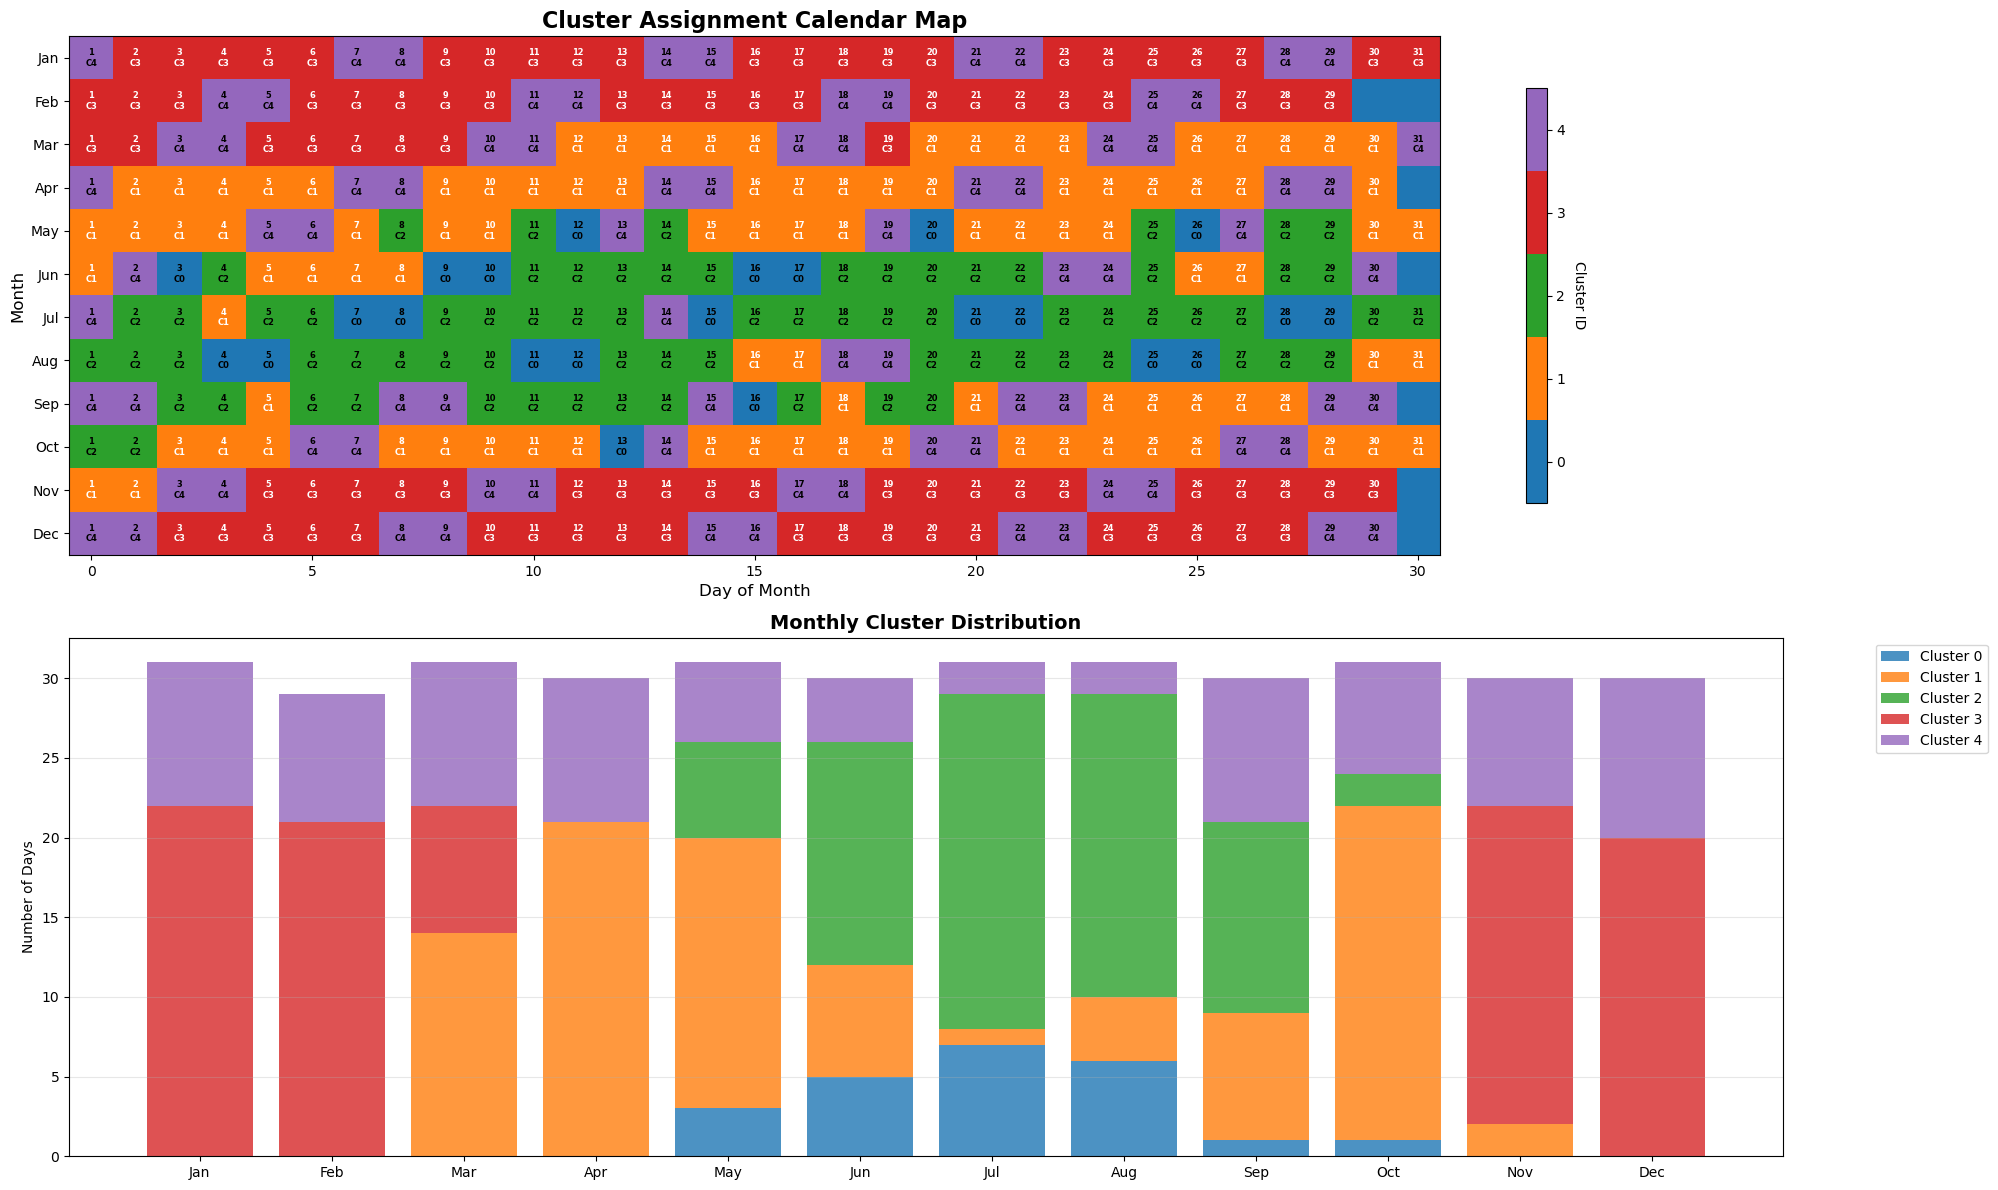

Creating cluster pattern analysis with real values...


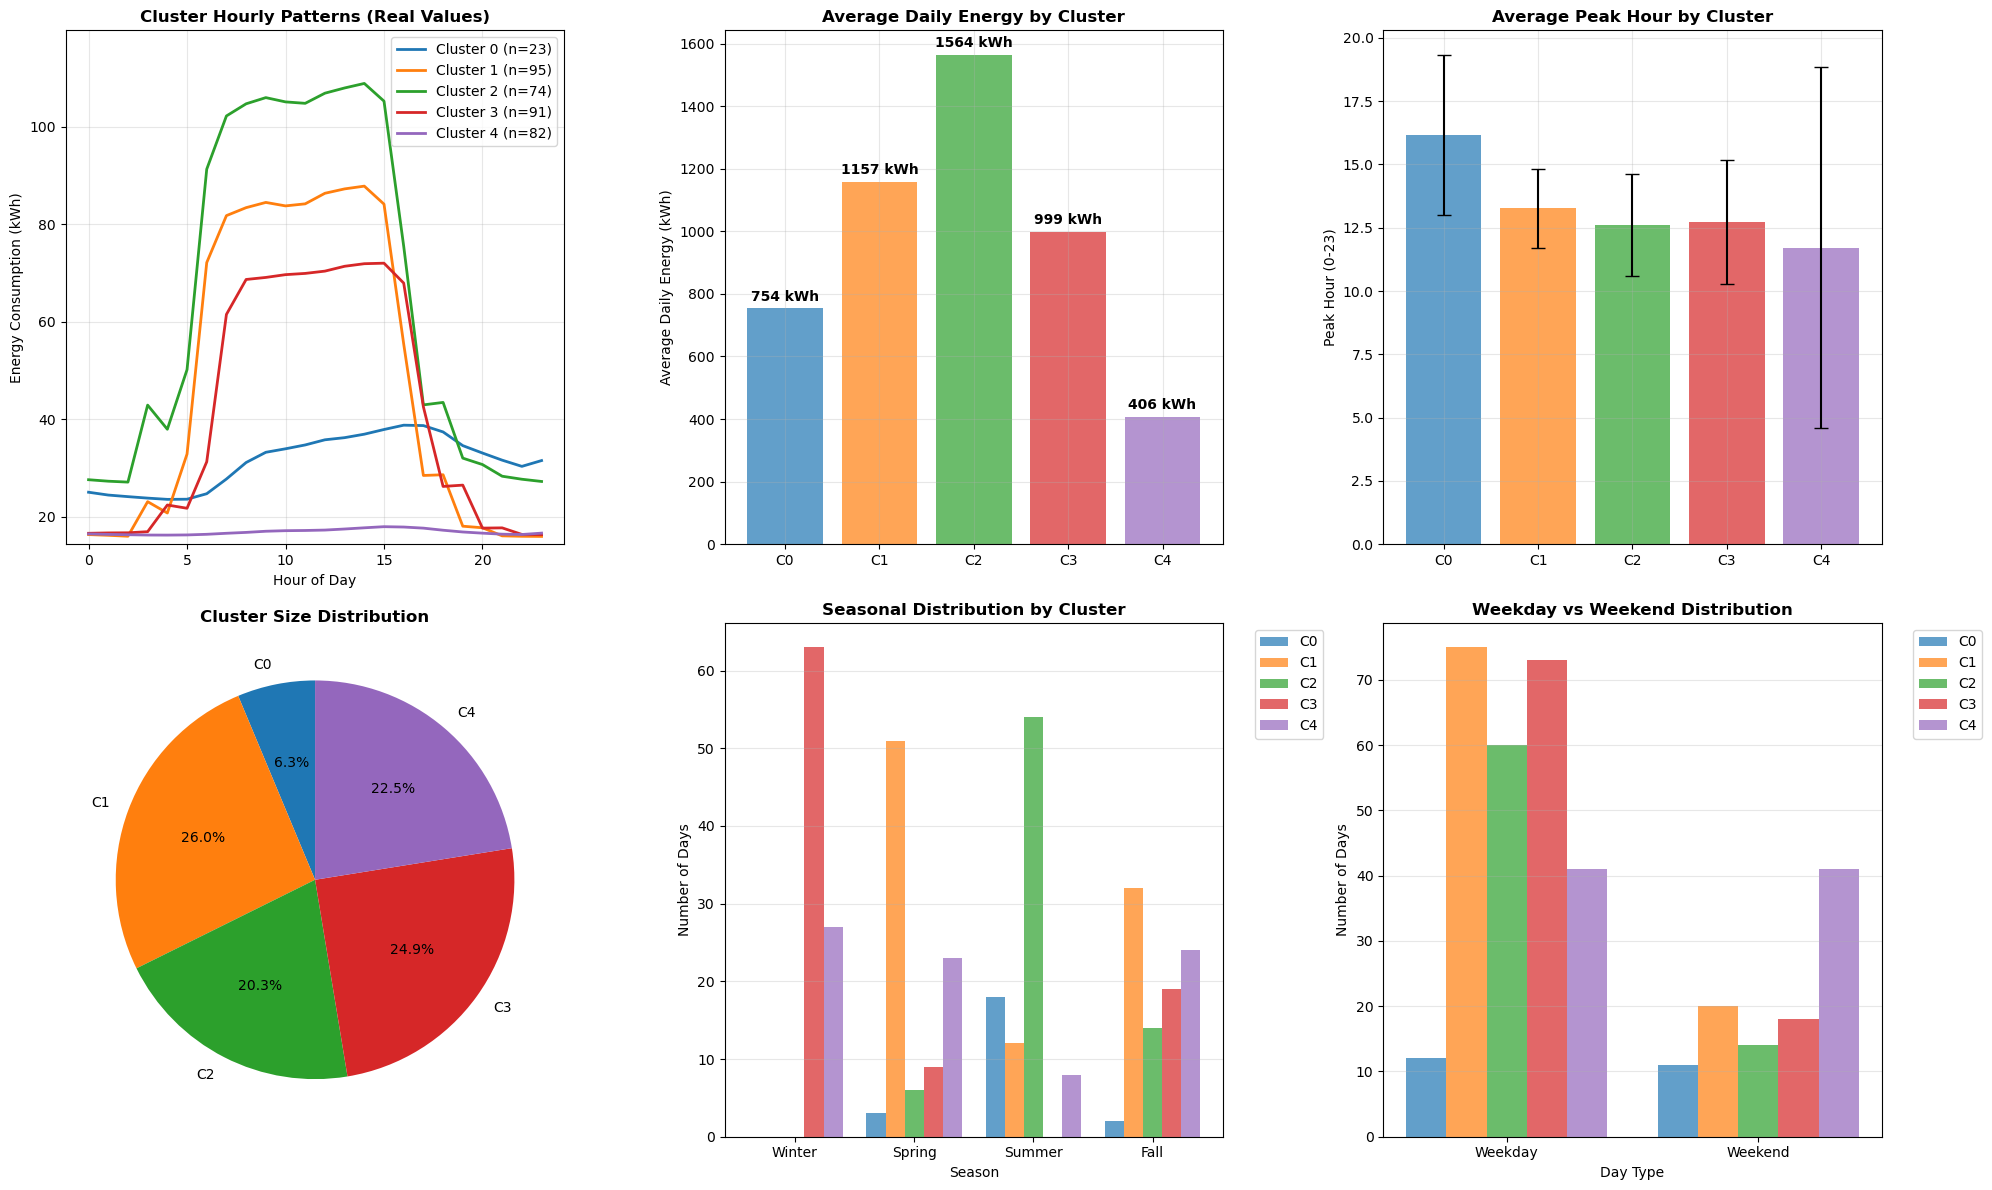


CLUSTER ANALYSIS SUMMARY

Cluster 0:
  Number of days: 23
  Daily energy: 753.6 ± 105.5 kWh
  Energy range: 604.3 - 987.8 kWh
  Peak hour: 16.2 ± 3.2
  First 10 days: [132, 140, 146, 154, 160, 161, 167, 168, 188, 189]

Cluster 1:
  Number of days: 95
  Daily energy: 1157.3 ± 102.1 kWh
  Energy range: 994.6 - 1351.6 kWh
  Peak hour: 13.3 ± 1.6
  First 10 days: [71, 72, 73, 74, 75, 79, 80, 81, 82, 85]

Cluster 2:
  Number of days: 74
  Daily energy: 1564.0 ± 142.6 kWh
  Energy range: 1356.7 - 1819.2 kWh
  Peak hour: 12.6 ± 2.0
  First 10 days: [128, 131, 134, 145, 148, 149, 155, 162, 163, 164]

Cluster 3:
  Number of days: 91
  Daily energy: 998.7 ± 34.4 kWh
  Energy range: 929.5 - 1109.5 kWh
  Peak hour: 12.7 ± 2.4
  First 10 days: [1, 2, 3, 4, 5, 8, 9, 10, 11, 12]

Cluster 4:
  Number of days: 82
  Daily energy: 406.2 ± 60.6 kWh
  Energy range: 360.8 - 580.9 kWh
  Peak hour: 11.7 ± 7.1
  First 10 days: [0, 6, 7, 13, 14, 20, 21, 27, 28, 34]

✓ Clustering results saved to C:\Users\e3akb

In [25]:
### STEP 12: K-MEANS CLUSTERING FOR HOURLY DATA COMPRESSION (FIXED JSON SAVING)
### =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import calendar

# Define consistent colors for clusters
CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

def denormalize_hourly_data(normalized_hourly):
    """Denormalize hourly data using saved normalization parameters"""
    hourly_min = norm_params['hourly_min']
    hourly_max = norm_params['hourly_max']
    return normalized_hourly * (hourly_max - hourly_min) + hourly_min

def denormalize_inputs(normalized_inputs):
    """Denormalize input parameters to get real values"""
    real_inputs = {}
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        vmin, vmax = INPUT_RANGES[param]
        real_value = normalized_inputs[i] * (vmax - vmin) + vmin
        real_inputs[param] = real_value
    return real_inputs

def print_sample_inputs(sample_idx, X_data):
    """Print the input parameters for a given sample"""
    print(f"\nInput parameters for sample {sample_idx}:")
    print("-" * 50)
    
    # Get normalized inputs for this sample
    normalized_inputs = X_data[sample_idx]
    
    # Denormalize to get real values
    real_inputs = denormalize_inputs(normalized_inputs)
    
    for param in PARAM_NAMES_EXPECTED:
        real_value = real_inputs[param]
        vmin, vmax = INPUT_RANGES[param]
        print(f"  {param:15}: {real_value:8.3f} (range: {vmin:6.3f} to {vmax:6.3f})")

def convert_numpy_to_python(obj):
    """Convert numpy types to native Python types for JSON serialization"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_numpy_to_python(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_to_python(item) for item in obj]
    else:
        return obj

def analyze_hourly_patterns_clustering(hourly_data_real, sample_inputs, n_clusters=5):
    """
    Apply k-means clustering to REAL hourly data and analyze the results
    """
    print(f"Applying k-means clustering with {n_clusters} clusters...")
    print(f"Using REAL hourly data (denormalized)")
    print(f"Data range: {np.min(hourly_data_real):.2f} to {np.max(hourly_data_real):.2f} kWh")
    
    # Reshape hourly data: from (365, 24) to (365, 24) - each day is a 24-dimensional point
    daily_profiles = hourly_data_real  # Shape: (365, 24)
    
    # Apply k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(daily_profiles)
    
    # Calculate silhouette score to evaluate clustering quality
    silhouette_avg = silhouette_score(daily_profiles, cluster_labels)
    print(f"✓ K-means clustering completed")
    print(f"✓ Silhouette Score: {silhouette_avg:.4f}")
    
    # Get cluster centers (representative days) - these are REAL values
    cluster_centers = kmeans.cluster_centers_  # Shape: (n_clusters, 24)
    
    # Analyze cluster characteristics with REAL values
    cluster_analysis = analyze_clusters(cluster_labels, cluster_centers, daily_profiles)
    
    return cluster_labels, cluster_centers, cluster_analysis, kmeans

def analyze_clusters(cluster_labels, cluster_centers, daily_profiles):
    """
    Analyze the characteristics of each cluster with REAL values
    """
    n_clusters = len(cluster_centers)
    analysis = {}
    
    for cluster_id in range(n_clusters):
        # Get days belonging to this cluster
        cluster_days = np.where(cluster_labels == cluster_id)[0]
        cluster_data = daily_profiles[cluster_days]
        
        # Calculate statistics with REAL values
        daily_totals = np.sum(cluster_data, axis=1)
        peak_hours = np.argmax(cluster_data, axis=1)
        
        analysis[cluster_id] = {
            'n_days': len(cluster_days),
            'day_indices': cluster_days.tolist(),  # Convert to list for JSON
            'total_energy_mean': float(np.mean(daily_totals)),
            'total_energy_std': float(np.std(daily_totals)),
            'peak_hour_mean': float(np.mean(peak_hours)),
            'peak_hour_std': float(np.std(peak_hours)),
            'daily_pattern': cluster_centers[cluster_id].tolist(),  # Convert to list
            'energy_range': [float(np.min(daily_totals)), float(np.max(daily_totals))],
            'hourly_range': [float(np.min(cluster_data)), float(np.max(cluster_data))]
        }
        
        print(f"  Cluster {cluster_id}: {len(cluster_days)} days, "
              f"Daily energy: {np.mean(daily_totals):.1f} ± {np.std(daily_totals):.1f} kWh, "
              f"Peak hour: {np.mean(peak_hours):.1f}")
    
    return analysis

# ... (keep the other functions the same: create_cluster_calendar_plot, create_cluster_pattern_analysis, 
# analyze_seasonal_patterns, analyze_weekend_patterns, print_cluster_summary)

print("STEP 12: K-MEANS CLUSTERING ANALYSIS (WITH INPUTS INFORMATION)")
print("="*60)

# Use the ORIGINAL training data for clustering analysis but DENORMALIZE it first
print("Using original training data (denormalized) for clustering analysis...")

# Get the first sample from the training data and DENORMALIZE it
sample_idx = 0  # Using first sample from training data
sample_hourly_normalized = y_hour_temp[sample_idx]  # Shape: (365, 24)
sample_hourly_real = denormalize_hourly_data(sample_hourly_normalized)

# Get the corresponding input parameters
sample_inputs_normalized = X_temp[sample_idx]  # Input parameters for this sample
sample_inputs_real = denormalize_inputs(sample_inputs_normalized)

print(f"Sample hourly data shape: {sample_hourly_real.shape}")
print(f"Sample statistics - Min: {np.min(sample_hourly_real):.2f} kWh, "
      f"Max: {np.max(sample_hourly_real):.2f} kWh, "
      f"Mean: {np.mean(sample_hourly_real):.2f} kWh")
print(f"Total annual energy: {np.sum(sample_hourly_real):.0f} kWh")

# Print the input parameters for this sample
print_sample_inputs(sample_idx, X_temp)

# Let's also check a few more samples to see the range
print(f"\nChecking input parameter ranges across all training samples:")
print("-" * 50)
for i, param in enumerate(PARAM_NAMES_EXPECTED):
    all_values = X_temp[:, i]
    real_values = all_values * (INPUT_RANGES[param][1] - INPUT_RANGES[param][0]) + INPUT_RANGES[param][0]
    print(f"  {param:15}: {np.min(real_values):6.3f} to {np.max(real_values):6.3f}")

# Apply k-means clustering to REAL data
cluster_labels, cluster_centers, cluster_analysis, kmeans = analyze_hourly_patterns_clustering(
    sample_hourly_real, sample_inputs_real, n_clusters=5
)

# Create calendar visualization
print("\nCreating cluster calendar visualization...")
calendar_data = create_cluster_calendar_plot(cluster_labels)

# Create cluster pattern analysis with REAL values
print("Creating cluster pattern analysis with real values...")
create_cluster_pattern_analysis(cluster_centers, cluster_analysis)

# Print detailed summary
print_cluster_summary(cluster_analysis)

# Save clustering results with REAL values and input information
# First convert all numpy types to Python native types
cluster_analysis_serializable = convert_numpy_to_python(cluster_analysis)

clustering_results = {
    'sample_index': sample_idx,
    'input_parameters': sample_inputs_real,
    'cluster_labels': cluster_labels.tolist(),
    'cluster_centers': cluster_centers.tolist(),
    'cluster_analysis': cluster_analysis_serializable,
    'silhouette_score': float(silhouette_score(sample_hourly_real, cluster_labels)),
    'cluster_colors': CLUSTER_COLORS,
    'data_info': {
        'hourly_min_real': float(np.min(sample_hourly_real)),
        'hourly_max_real': float(np.max(sample_hourly_real)),
        'total_annual_energy': float(np.sum(sample_hourly_real)),
        'annual_outputs_real': {
            'CEDI': float(denormalize_annual_outputs_ensemble(
                Y_ann[sample_idx:sample_idx+1], 
                norm_params['annual_ranges']
            )[0, 0]),
            'TEDI': float(denormalize_annual_outputs_ensemble(
                Y_ann[sample_idx:sample_idx+1], 
                norm_params['annual_ranges']
            )[0, 1]),
            'EUI': float(denormalize_annual_outputs_ensemble(
                Y_ann[sample_idx:sample_idx+1], 
                norm_params['annual_ranges']
            )[0, 2])
        }
    }
}

with open(OUTPUT_DIR / "kmeans_clustering_results_with_inputs.json", "w") as f:
    json.dump(clustering_results, f, indent=4)

print(f"\n✓ Clustering results saved to {OUTPUT_DIR / 'kmeans_clustering_results_with_inputs.json'}")
print(f"✓ Using REAL values (kWh) for all analysis")
print(f"✓ Sample inputs documented in results file")

# Let's also analyze multiple samples to see if patterns are consistent
print(f"\n{'='*60}")
print("ANALYZING MULTIPLE SAMPLES FOR CONSISTENCY")
print(f"{'='*60}")

# Analyze 3 different samples to see if clustering patterns are consistent
test_samples = [0, 100, 200]  # Different samples from the dataset

for test_idx in test_samples:
    print(f"\nAnalyzing sample {test_idx}:")
    print("-" * 40)
    
    # Get sample data
    test_hourly_normalized = y_hour_temp[test_idx]
    test_hourly_real = denormalize_hourly_data(test_hourly_normalized)
    test_inputs_normalized = X_temp[test_idx]
    test_inputs_real = denormalize_inputs(test_inputs_normalized)
    
    print(f"  Total annual energy: {np.sum(test_hourly_real):.0f} kWh")
    print(f"  Key parameters - Area: {test_inputs_real['Area']:.0f} m², "
          f"WWR: {test_inputs_real['WWR']:.2f}, "
          f"LPD: {test_inputs_real['LPD']:.1f} W/m²")
    
    # Apply clustering to this sample
    test_labels, test_centers, test_analysis, _ = analyze_hourly_patterns_clustering(
        test_hourly_real, test_inputs_real, n_clusters=5
    )
    
    # Print cluster sizes for comparison
    cluster_sizes = [test_analysis[i]['n_days'] for i in range(5)]
    print(f"  Cluster sizes: {cluster_sizes}")

# Add this helper function if not already defined
def denormalize_annual_outputs_ensemble(norm_ann, annual_ranges):
    ANNUAL_COLS = ["CEDI (kWh/m2)", "TEDI (kWh/m2)", "EUI (kWh/m2)"]
    denorm_ann = norm_ann.copy()
    for i, col in enumerate(ANNUAL_COLS):
        vmin = annual_ranges[f"{col}_min"]
        vmax = annual_ranges[f"{col}_max"]
        denorm_ann[:, i] = norm_ann[:, i] * (vmax - vmin) + vmin
    return denorm_ann

Starting K-means parameter experiments...
STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS

🔬 EXPERIMENT 1: Varying Number of Clusters
--------------------------------------------------

Testing k=3 clusters:
  Silhouette Score: 0.6028
  Cluster sizes: [103, 105, 157]
  Size distribution: 25.0 std

Testing k=4 clusters:
  Silhouette Score: 0.5770
  Cluster sizes: [74, 105, 91, 95]
  Size distribution: 11.2 std

Testing k=5 clusters:
  Silhouette Score: 0.5702
  Cluster sizes: [23, 95, 74, 91, 82]
  Size distribution: 26.0 std

Testing k=6 clusters:
  Silhouette Score: 0.5576
  Cluster sizes: [66, 23, 91, 45, 82, 58]
  Size distribution: 22.6 std

Testing k=7 clusters:
  Silhouette Score: 0.5277
  Cluster sizes: [27, 23, 90, 82, 51, 56, 36]
  Size distribution: 24.2 std

Testing k=8 clusters:
  Silhouette Score: 0.4700
  Cluster sizes: [41, 82, 36, 61, 23, 27, 50, 45]
  Size distribution: 17.9 std

🔬 EXPERIMENT 2: Varying Random States
------------------------------------------------

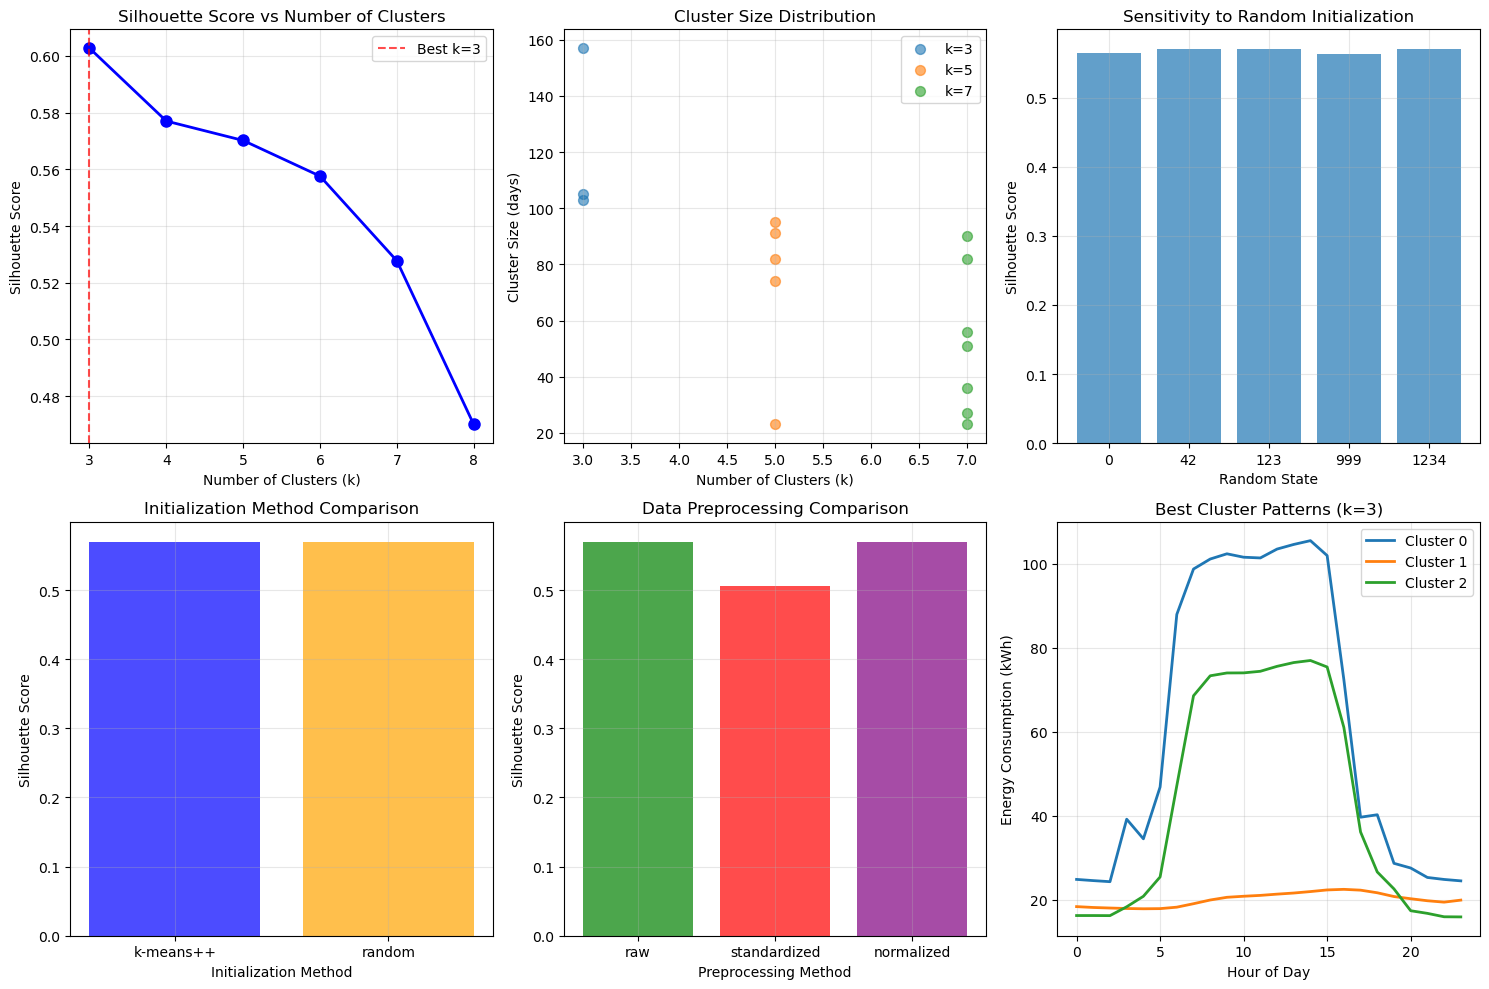

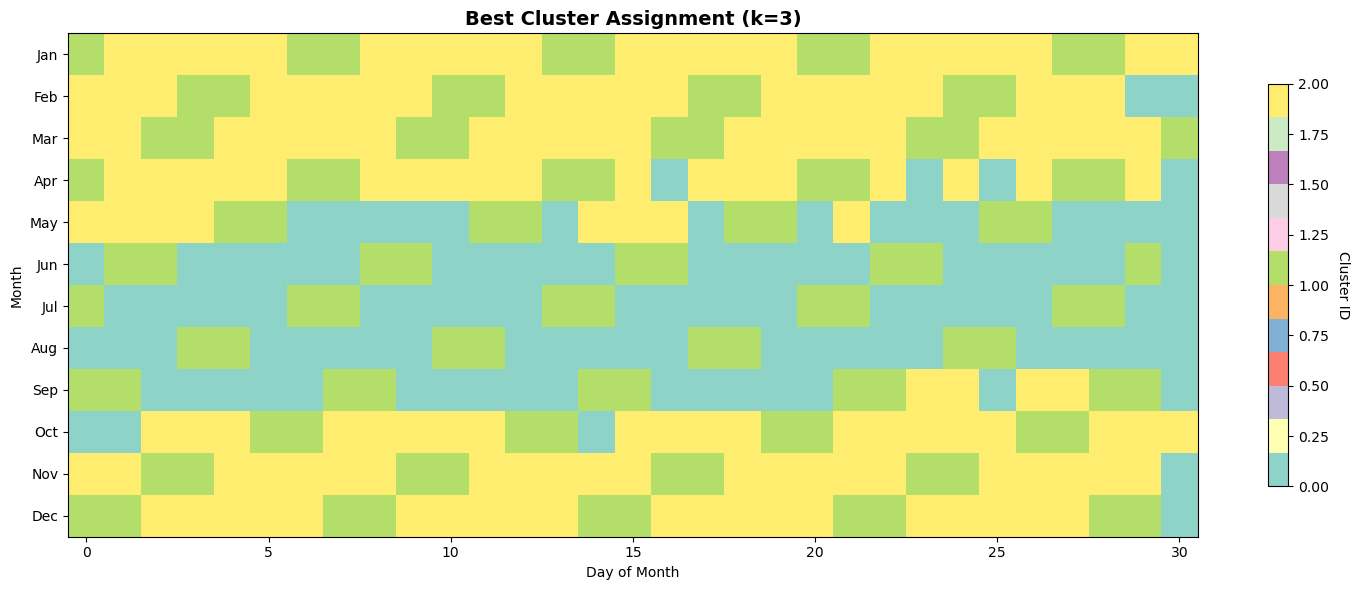


🎯 OPTIMAL PARAMETER RECOMMENDATIONS
📈 Optimal number of clusters: k = 3
   Silhouette score: 0.6028
   Cluster sizes: [103, 105, 157]
\n🎲 Random state sensitivity:
   Score variation: 0.003036
   ✅ Low sensitivity - results are stable
\n⚡ Best initialization: 'k-means++'
\n🔧 Best preprocessing: 'raw'
\n💡 FINAL RECOMMENDATION:
   Use KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
   with raw data (no preprocessing)
\n✓ Experiment results saved to: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try\kmeans_experiments_results.json
✓ Step 12.5 completed successfully!


In [27]:
### STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS
### =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def run_kmeans_experiments(hourly_data_real, sample_inputs):
    """
    Run systematic experiments with different K-means parameters
    """
    print("STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS")
    print("=" * 70)
    
    experiments_results = {}
    
    # Experiment 1: Different numbers of clusters (k)
    print("\n🔬 EXPERIMENT 1: Varying Number of Clusters")
    print("-" * 50)
    
    k_values = [3, 4, 5, 6, 7, 8]
    experiment1_results = {}
    
    for k in k_values:
        print(f"\nTesting k={k} clusters:")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        
        # Analyze cluster sizes
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(k)]
        
        experiment1_results[k] = {
            'silhouette_score': silhouette_avg,
            'cluster_sizes': cluster_sizes,
            'cluster_centers': kmeans.cluster_centers_
        }
        
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
        print(f"  Size distribution: {np.std(cluster_sizes):.1f} std")
    
    experiments_results['varying_k'] = experiment1_results
    
    # Experiment 2: Different random states
    print("\n🔬 EXPERIMENT 2: Varying Random States")
    print("-" * 50)
    
    random_states = [0, 42, 123, 999, 1234]
    experiment2_results = {}
    
    for rs in random_states:
        print(f"\nTesting random_state={rs}:")
        kmeans = KMeans(n_clusters=5, random_state=rs, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(5)]
        
        experiment2_results[rs] = {
            'silhouette_score': silhouette_avg,
            'cluster_sizes': cluster_sizes
        }
        
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
    
    experiments_results['varying_random_state'] = experiment2_results
    
    # Experiment 3: Different initialization methods
    print("\n🔬 EXPERIMENT 3: Initialization Methods")
    print("-" * 50)
    
    init_methods = ['k-means++', 'random']
    experiment3_results = {}
    
    for init in init_methods:
        print(f"\nTesting init='{init}':")
        kmeans = KMeans(n_clusters=5, random_state=42, init=init, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(5)]
        
        experiment3_results[init] = {
            'silhouette_score': silhouette_avg,
            'cluster_sizes': cluster_sizes
        }
        
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
    
    experiments_results['varying_init'] = experiment3_results
    
    # Experiment 4: Data preprocessing
    print("\n🔬 EXPERIMENT 4: Data Preprocessing Methods")
    print("-" * 50)
    
    preprocessing_methods = {
        'raw': hourly_data_real,
        'standardized': StandardScaler().fit_transform(hourly_data_real),
        'normalized': (hourly_data_real - hourly_data_real.min()) / (hourly_data_real.max() - hourly_data_real.min())
    }
    
    experiment4_results = {}
    
    for method, data in preprocessing_methods.items():
        print(f"\nTesting {method} data:")
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(data)
        silhouette_avg = silhouette_score(data, cluster_labels)
        
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(5)]
        
        experiment4_results[method] = {
            'silhouette_score': silhouette_avg,
            'cluster_sizes': cluster_sizes
        }
        
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
    
    experiments_results['varying_preprocessing'] = experiment4_results
    
    # Create comprehensive comparison plots
    create_experiment_comparison_plots(experiments_results, hourly_data_real)
    
    # Find optimal parameters
    find_optimal_parameters(experiments_results)
    
    return experiments_results

def create_experiment_comparison_plots(experiments_results, hourly_data_real):
    """
    Create comparison plots for all experiments
    """
    print("\n📊 Creating comparison plots...")
    
    # Plot 1: Silhouette scores vs number of clusters
    plt.figure(figsize=(15, 10))
    
    # Experiment 1: k values
    plt.subplot(2, 3, 1)
    k_values = list(experiments_results['varying_k'].keys())
    silhouette_scores = [exp['silhouette_score'] for exp in experiments_results['varying_k'].values()]
    
    plt.plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.grid(True, alpha=0.3)
    
    # Add best k
    best_k = k_values[np.argmax(silhouette_scores)]
    plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
    plt.legend()
    
    # Plot 2: Cluster size distributions for different k
    plt.subplot(2, 3, 2)
    for k in [3, 5, 7]:
        sizes = experiments_results['varying_k'][k]['cluster_sizes']
        plt.scatter([k] * len(sizes), sizes, alpha=0.6, s=50, label=f'k={k}')
    
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Cluster Size (days)')
    plt.title('Cluster Size Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Random state comparison
    plt.subplot(2, 3, 3)
    random_states = list(experiments_results['varying_random_state'].keys())
    sil_scores_rs = [exp['silhouette_score'] for exp in experiments_results['varying_random_state'].values()]
    
    plt.bar(range(len(random_states)), sil_scores_rs, alpha=0.7)
    plt.xticks(range(len(random_states)), random_states)
    plt.xlabel('Random State')
    plt.ylabel('Silhouette Score')
    plt.title('Sensitivity to Random Initialization')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Initialization methods
    plt.subplot(2, 3, 4)
    init_methods = list(experiments_results['varying_init'].keys())
    sil_scores_init = [exp['silhouette_score'] for exp in experiments_results['varying_init'].values()]
    
    plt.bar(init_methods, sil_scores_init, alpha=0.7, color=['blue', 'orange'])
    plt.xlabel('Initialization Method')
    plt.ylabel('Silhouette Score')
    plt.title('Initialization Method Comparison')
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Preprocessing methods
    plt.subplot(2, 3, 5)
    preprocessing_methods = list(experiments_results['varying_preprocessing'].keys())
    sil_scores_preprocess = [exp['silhouette_score'] for exp in experiments_results['varying_preprocessing'].values()]
    
    plt.bar(preprocessing_methods, sil_scores_preprocess, alpha=0.7, color=['green', 'red', 'purple'])
    plt.xlabel('Preprocessing Method')
    plt.ylabel('Silhouette Score')
    plt.title('Data Preprocessing Comparison')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Best cluster patterns comparison
    plt.subplot(2, 3, 6)
    
    # Find best parameters from experiments
    best_k = k_values[np.argmax(silhouette_scores)]
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    best_labels = best_kmeans.fit_predict(hourly_data_real)
    best_centers = best_kmeans.cluster_centers_
    
    for i in range(best_k):
        plt.plot(range(24), best_centers[i], label=f'Cluster {i}', linewidth=2)
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title(f'Best Cluster Patterns (k={best_k})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "kmeans_parameter_experiments.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create calendar for best k
    create_best_k_calendar(best_labels, best_k)

def create_best_k_calendar(cluster_labels, k):
    """Create calendar visualization for the best k"""
    # Create date range for the year
    start_date = datetime(2024, 1, 1)
    dates = [start_date + timedelta(days=i) for i in range(365)]
    
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    plt.figure(figsize=(15, 6))
    cmap = plt.cm.Set3
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=k-1)
    
    plt.title(f'Best Cluster Assignment (k={k})', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"best_k_calendar_k{k}.png", dpi=300, bbox_inches='tight')
    plt.show()

def find_optimal_parameters(experiments_results):
    """Find and recommend optimal parameters"""
    print("\n" + "="*70)
    print("🎯 OPTIMAL PARAMETER RECOMMENDATIONS")
    print("="*70)
    
    # Find best k
    k_results = experiments_results['varying_k']
    best_k = max(k_results.keys(), key=lambda k: k_results[k]['silhouette_score'])
    best_k_score = k_results[best_k]['silhouette_score']
    
    print(f"📈 Optimal number of clusters: k = {best_k}")
    print(f"   Silhouette score: {best_k_score:.4f}")
    print(f"   Cluster sizes: {k_results[best_k]['cluster_sizes']}")
    
    # Check random state sensitivity
    rs_results = experiments_results['varying_random_state']
    rs_scores = [rs_results[rs]['silhouette_score'] for rs in rs_results]
    rs_variation = np.std(rs_scores)
    
    print(f"\\n🎲 Random state sensitivity:")
    print(f"   Score variation: {rs_variation:.6f}")
    if rs_variation < 0.01:
        print("   ✅ Low sensitivity - results are stable")
    else:
        print("   ⚠️  Moderate sensitivity - consider multiple runs")
    
    # Best initialization
    init_results = experiments_results['varying_init']
    best_init = max(init_results.keys(), key=lambda init: init_results[init]['silhouette_score'])
    
    print(f"\\n⚡ Best initialization: '{best_init}'")
    
    # Best preprocessing
    preprocess_results = experiments_results['varying_preprocessing']
    best_preprocess = max(preprocess_results.keys(), key=lambda method: preprocess_results[method]['silhouette_score'])
    
    print(f"\\n🔧 Best preprocessing: '{best_preprocess}'")
    
    # Final recommendation
    print(f"\\n💡 FINAL RECOMMENDATION:")
    print(f"   Use KMeans(n_clusters={best_k}, random_state=42, init='{best_init}', n_init=10)")
    if best_preprocess != 'raw':
        print(f"   with '{best_preprocess}' data preprocessing")
    else:
        print(f"   with raw data (no preprocessing)")
    
    return best_k, best_init, best_preprocess

# Run the experiments
print("Starting K-means parameter experiments...")
sample_hourly_real = denormalize_hourly_data(y_hour_temp[0])  # Use first sample

experiments_results = run_kmeans_experiments(sample_hourly_real, X_temp[0])

# Save experiment results
with open(OUTPUT_DIR / "kmeans_experiments_results.json", "w") as f:
    # Convert numpy types to Python native types for JSON
    experiments_serializable = convert_numpy_to_python(experiments_results)
    json.dump(experiments_serializable, f, indent=4)

print(f"\\n✓ Experiment results saved to: {OUTPUT_DIR / 'kmeans_experiments_results.json'}")
print("✓ Step 12.5 completed successfully!")

In [28]:
### STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS (k optimization with silhouette index)
### =============================================================================

def run_kmeans_experiments(hourly_data_real, sample_inputs):
    """
    Run systematic experiments with different K-means parameters
    """
    print("STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS")
    print("=" * 70)
    
    experiments_results = {}
    
    # Experiment 1: Different numbers of clusters (k) - WITH CALENDARS
    print("\n🔬 EXPERIMENT 1: Varying Number of Clusters")
    print("-" * 50)
    
    k_values = [3, 4, 5, 6, 7, 8]
    experiment1_results = {}
    
    for k in k_values:
        print(f"\nTesting k={k} clusters:")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        
        # Analyze cluster sizes
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(k)]
        
        experiment1_results[k] = {
            'silhouette_score': silhouette_avg,
            'cluster_sizes': cluster_sizes,
            'cluster_centers': kmeans.cluster_centers_,
            'cluster_labels': cluster_labels
        }
        
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
        
        # CREATE CALENDAR FOR EACH k (ESPECIALLY k=5)
        if k == 5:  # Force calendar for k=5
            print("  🗓️  Creating calendar for k=5...")
            create_calendar_for_k(cluster_labels, k, "k5_calendar")
        
        create_calendar_for_k(cluster_labels, k, f"k{k}_calendar")
    
    experiments_results['varying_k'] = experiment1_results
    
    # ... rest of experiments remain the same ...

def create_calendar_for_k(cluster_labels, k, filename):
    """Create calendar visualization for a specific k"""
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    plt.figure(figsize=(15, 6))
    cmap = plt.cm.Set3
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=k-1)
    
    plt.title(f'Cluster Assignment Calendar (k={k})', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename}.png", dpi=300, bbox_inches='tight')
    plt.close()  # Close to avoid display issues
    print(f"    ✓ Calendar saved: {filename}.png")

# Run the experiments
print("Starting K-means parameter experiments...")
sample_hourly_real = denormalize_hourly_data(y_hour_temp[0])

experiments_results = run_kmeans_experiments(sample_hourly_real, X_temp[0])

Starting K-means parameter experiments...
STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS

🔬 EXPERIMENT 1: Varying Number of Clusters
--------------------------------------------------

Testing k=3 clusters:
  Silhouette Score: 0.6028
  Cluster sizes: [103, 105, 157]
    ✓ Calendar saved: k3_calendar.png

Testing k=4 clusters:
  Silhouette Score: 0.5770
  Cluster sizes: [74, 105, 91, 95]
    ✓ Calendar saved: k4_calendar.png

Testing k=5 clusters:
  Silhouette Score: 0.5702
  Cluster sizes: [23, 95, 74, 91, 82]
  🗓️  Creating calendar for k=5...
    ✓ Calendar saved: k5_calendar.png
    ✓ Calendar saved: k5_calendar.png

Testing k=6 clusters:
  Silhouette Score: 0.5576
  Cluster sizes: [66, 23, 91, 45, 82, 58]
    ✓ Calendar saved: k6_calendar.png

Testing k=7 clusters:
  Silhouette Score: 0.5277
  Cluster sizes: [27, 23, 90, 82, 51, 56, 36]
    ✓ Calendar saved: k7_calendar.png

Testing k=8 clusters:
  Silhouette Score: 0.4700
  Cluster sizes: [41, 82, 36, 61, 23, 27, 50, 45]
    

Starting K-means parameter experiments with Elbow method...
STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS (WITH ELBOW METHOD)

🔬 EXPERIMENT 1: Varying Number of Clusters (Silhouette vs Elbow)
------------------------------------------------------------

Testing k=2 clusters:
  WCSS: 1163627
  Silhouette Score: 0.6723
  Calinski-Harabasz: 979
  Davies-Bouldin: 0.4318
  Cluster sizes: [260, 105]
    ✓ Calendar saved: k2_calendar.png

Testing k=3 clusters:
  WCSS: 498951
  Silhouette Score: 0.6028
  Calinski-Harabasz: 1379
  Davies-Bouldin: 0.5918
  Cluster sizes: [103, 105, 157]
    ✓ Calendar saved: k3_calendar.png

Testing k=4 clusters:
  WCSS: 340622
  Silhouette Score: 0.5770
  Calinski-Harabasz: 1399
  Davies-Bouldin: 0.5764
  Cluster sizes: [74, 105, 91, 95]
    ✓ Calendar saved: k4_calendar.png

Testing k=5 clusters:
  WCSS: 240348
  Silhouette Score: 0.5702
  Calinski-Harabasz: 1520
  Davies-Bouldin: 0.6088
  Cluster sizes: [23, 95, 74, 91, 82]
  🗓️  Creating calendar for k

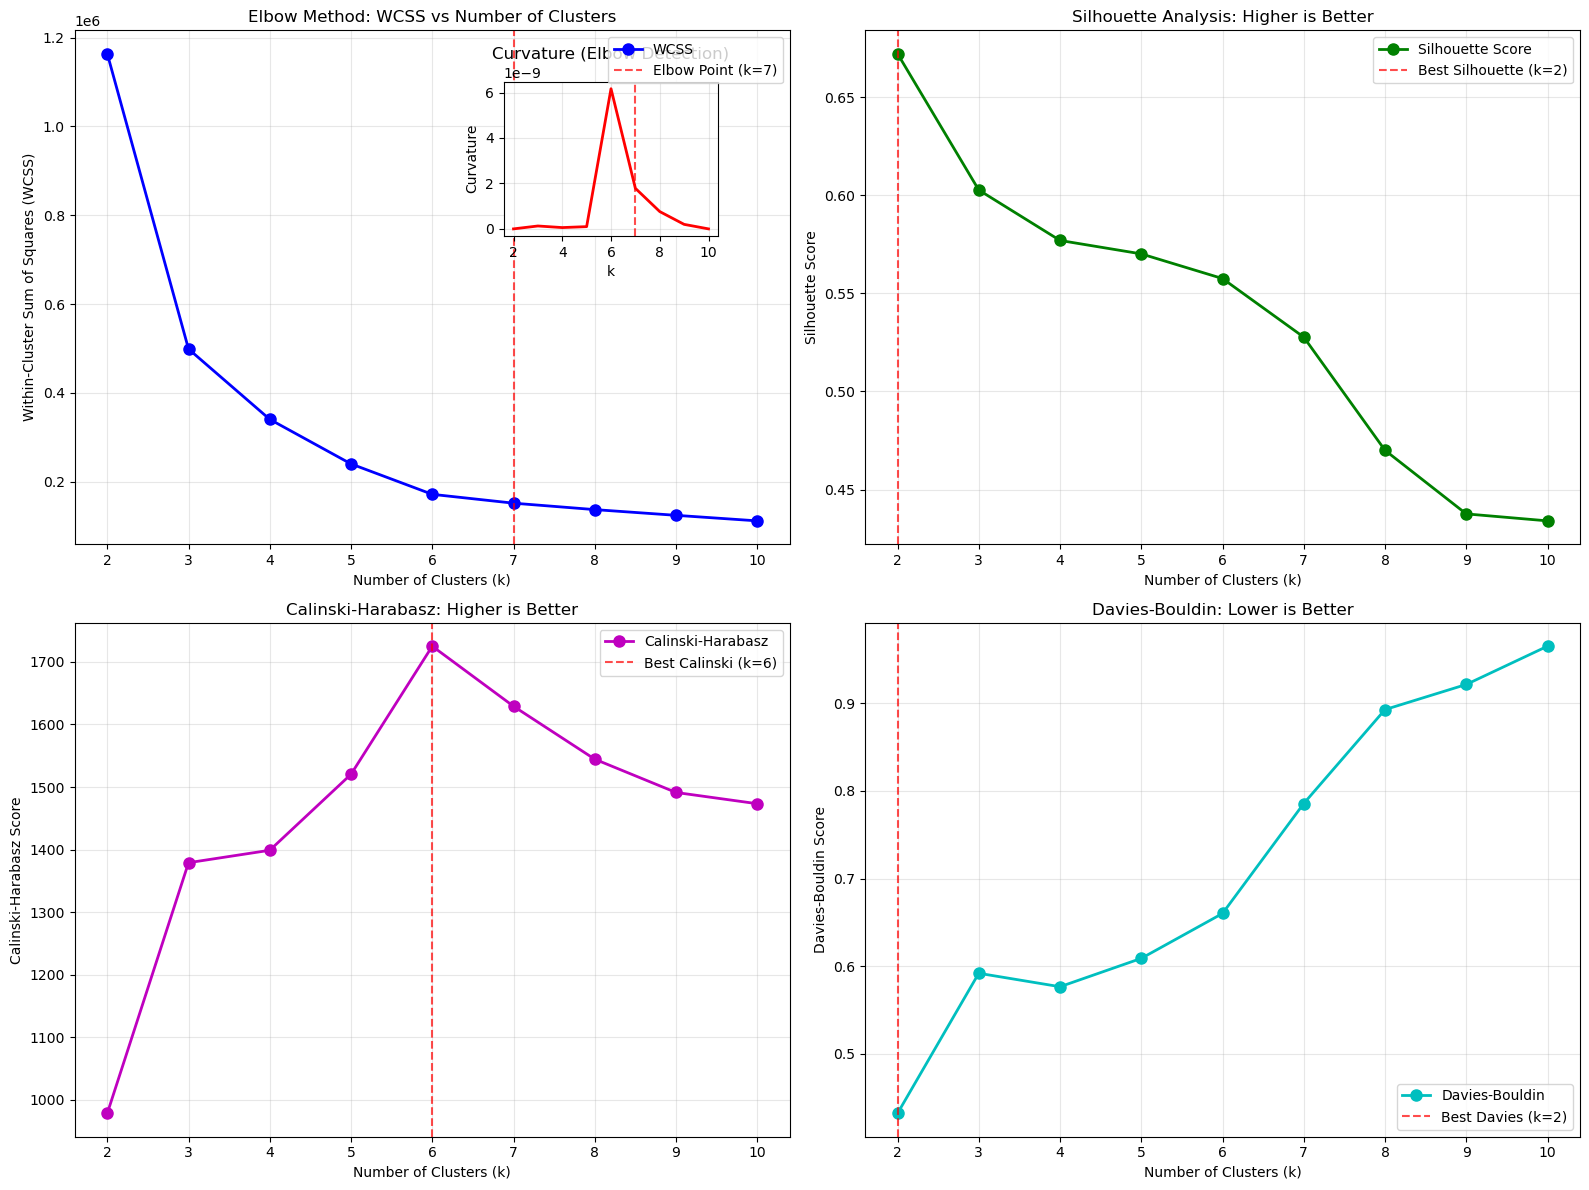

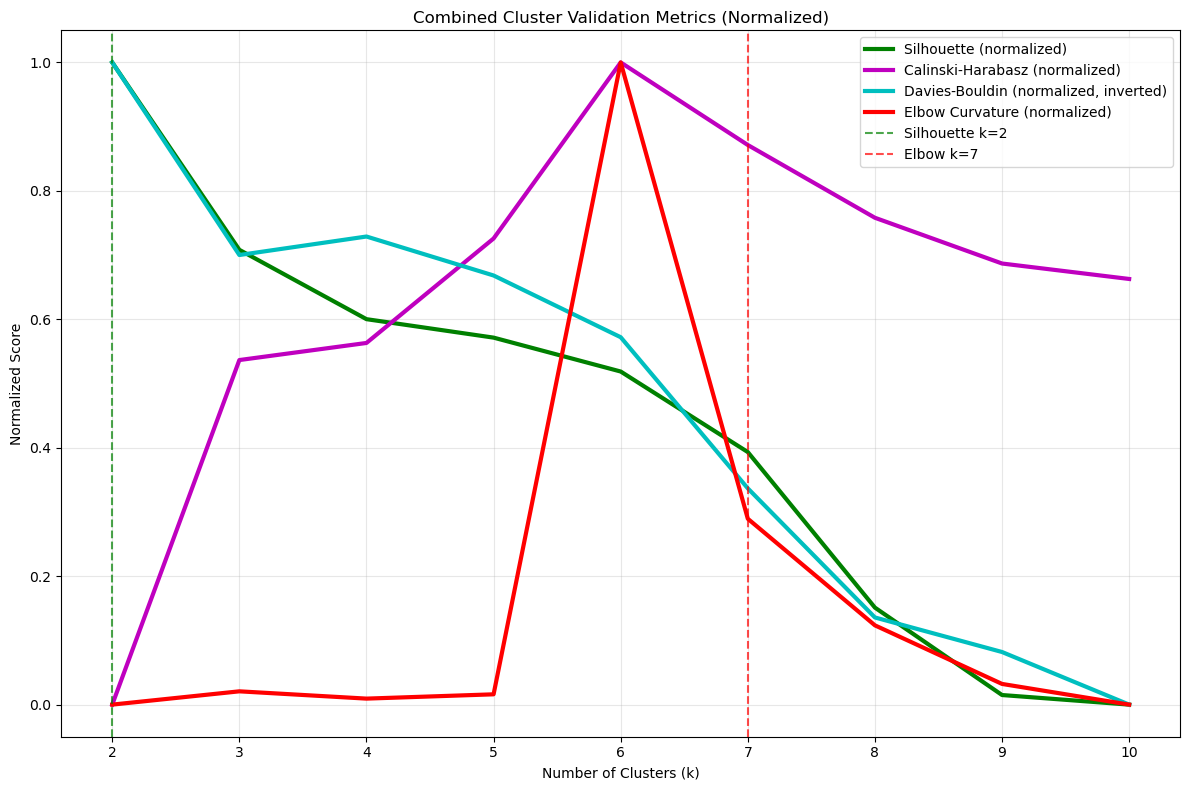


🔄 COMPARISON OF OPTIMAL K SELECTION METHODS
Method               Optimal k  Silhouette   Calinski     Davies       WCSS        
--------------------------------------------------------------------------------
Silhouette           2          0.6723       979          0.4318       1163627     
Elbow                7          0.5277       1629         0.7857       151951      
Calinski-Harabasz    6          0.5576       1725         0.6601       171851      
Davies-Bouldin       2          0.6723       979          0.4318       1163627     

🎯 CONSENSUS OPTIMAL K: 2 (supported by 2 methods)

🗓️ Creating calendars for all optimal k values:
    ✓ Calendar saved: optimal_k_silhouette.png
    ✓ Calendar saved: optimal_k_elbow.png
    ✓ Calendar saved: optimal_k_calinski-harabasz.png
    ✓ Calendar saved: optimal_k_davies-bouldin.png

🔬 EXPERIMENT 2: Varying Random States
--------------------------------------------------

Testing random_state=0:
  Silhouette Score: 0.5643
  Cluster sizes: [

In [32]:
### STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS (WITH several method for k optimization)
### =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def run_kmeans_experiments_with_elbow(hourly_data_real, sample_inputs):
    """
    Run systematic experiments with different K-means parameters including Elbow method
    """
    print("STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS (WITH ELBOW METHOD)")
    print("=" * 70)
    
    experiments_results = {}
    
    # Experiment 1: Different numbers of clusters (k) with multiple metrics
    print("\n🔬 EXPERIMENT 1: Varying Number of Clusters (Silhouette vs Elbow)")
    print("-" * 60)
    
    k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
    experiment1_results = {}
    
    # Calculate WCSS (Within-Cluster Sum of Squares) for Elbow method
    wcss_values = []
    silhouette_scores = []
    calinski_scores = []
    davies_scores = []
    
    for k in k_values:
        print(f"\nTesting k={k} clusters:")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        
        # Calculate multiple metrics
        wcss = kmeans.inertia_
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        calinski = calinski_harabasz_score(hourly_data_real, cluster_labels)
        davies = davies_bouldin_score(hourly_data_real, cluster_labels)
        
        # Store values
        wcss_values.append(wcss)
        silhouette_scores.append(silhouette_avg)
        calinski_scores.append(calinski)
        davies_scores.append(davies)
        
        # Analyze cluster sizes
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(k)]
        
        experiment1_results[k] = {
            'wcss': wcss,
            'silhouette_score': silhouette_avg,
            'calinski_harabasz_score': calinski,
            'davies_bouldin_score': davies,
            'cluster_sizes': cluster_sizes,
            'cluster_centers': kmeans.cluster_centers_,
            'cluster_labels': cluster_labels
        }
        
        print(f"  WCSS: {wcss:.0f}")
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Calinski-Harabasz: {calinski:.0f}")
        print(f"  Davies-Bouldin: {davies:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
        
        # CREATE CALENDAR FOR EACH k (ESPECIALLY k=5)
        if k == 5:  # Force calendar for k=5
            print("  🗓️  Creating calendar for k=5...")
            create_calendar_for_k(cluster_labels, k, "k5_calendar")
        
        create_calendar_for_k(cluster_labels, k, f"k{k}_calendar")
    
    experiments_results['varying_k'] = experiment1_results
    
    # Find optimal k using different methods
    print("\n🎯 OPTIMAL K SELECTION USING DIFFERENT METHODS:")
    print("-" * 50)
    
    # Method 1: Silhouette (higher is better)
    optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
    print(f"Silhouette Method: k = {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
    
    # Method 2: Elbow method (find the "elbow" in WCSS curve)
    optimal_k_elbow = find_elbow_point(k_values, wcss_values)
    print(f"Elbow Method: k = {optimal_k_elbow}")
    
    # Method 3: Calinski-Harabasz (higher is better)
    optimal_k_calinski = k_values[np.argmax(calinski_scores)]
    print(f"Calinski-Harabasz: k = {optimal_k_calinski} (score: {max(calinski_scores):.0f})")
    
    # Method 4: Davies-Bouldin (lower is better)
    optimal_k_davies = k_values[np.argmin(davies_scores)]
    print(f"Davies-Bouldin: k = {optimal_k_davies} (score: {min(davies_scores):.4f})")
    
    # Create comprehensive comparison plots
    create_elbow_silhouette_comparison(k_values, wcss_values, silhouette_scores, 
                                     calinski_scores, davies_scores,
                                     optimal_k_elbow, optimal_k_silhouette)
    
    # Compare the methods
    compare_optimal_k_methods(optimal_k_silhouette, optimal_k_elbow, 
                            optimal_k_calinski, optimal_k_davies,
                            k_values, experiment1_results)
    
    # Continue with other experiments...
    experiments_results.update(run_additional_experiments(hourly_data_real))
    
    return experiments_results

def find_elbow_point(k_values, wcss_values):
    """
    Find the elbow point in WCSS curve using the maximum curvature method
    """
    # Calculate the second derivative (approximate curvature)
    first_deriv = np.diff(wcss_values)
    second_deriv = np.diff(first_deriv)
    
    # Normalize the second derivative to find maximum curvature
    curvature = np.abs(second_deriv) / (1 + first_deriv[1:]**2)**1.5
    
    # Add padding for alignment with k_values
    curvature = np.concatenate(([0], curvature, [0]))
    
    # Find the point of maximum curvature (elbow)
    elbow_index = np.argmax(curvature) + 1  # +1 because k starts from 2
    
    # Ensure we don't go out of bounds
    elbow_index = min(elbow_index, len(k_values) - 1)
    
    return k_values[elbow_index]

def create_elbow_silhouette_comparison(k_values, wcss_values, silhouette_scores, 
                                     calinski_scores, davies_scores,
                                     optimal_k_elbow, optimal_k_silhouette):
    """
    Create comparison plots between Elbow method and Silhouette analysis
    """
    print("\n📊 Creating Elbow vs Silhouette comparison plots...")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Elbow Method (WCSS)
    ax1.plot(k_values, wcss_values, 'bo-', linewidth=2, markersize=8, label='WCSS')
    ax1.axvline(x=optimal_k_elbow, color='red', linestyle='--', alpha=0.7, 
                label=f'Elbow Point (k={optimal_k_elbow})')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
    ax1.set_title('Elbow Method: WCSS vs Number of Clusters')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add second derivative (curvature) as inset
    inset_ax = ax1.inset_axes([0.6, 0.6, 0.3, 0.3])
    first_deriv = np.diff(wcss_values)
    second_deriv = np.diff(first_deriv)
    curvature = np.abs(second_deriv) / (1 + first_deriv[1:]**2)**1.5
    curvature = np.concatenate(([0], curvature, [0]))
    inset_ax.plot(k_values, curvature, 'r-', linewidth=2)
    inset_ax.axvline(x=optimal_k_elbow, color='red', linestyle='--', alpha=0.7)
    inset_ax.set_xlabel('k')
    inset_ax.set_ylabel('Curvature')
    inset_ax.set_title('Curvature (Elbow Detection)')
    inset_ax.grid(True, alpha=0.3)
    
    # Plot 2: Silhouette Scores
    ax2.plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8, label='Silhouette Score')
    ax2.axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.7,
                label=f'Best Silhouette (k={optimal_k_silhouette})')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Analysis: Higher is Better')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Calinski-Harabasz Scores
    ax3.plot(k_values, calinski_scores, 'mo-', linewidth=2, markersize=8, label='Calinski-Harabasz')
    ax3.axvline(x=k_values[np.argmax(calinski_scores)], color='red', linestyle='--', alpha=0.7,
                label=f'Best Calinski (k={k_values[np.argmax(calinski_scores)]})')
    ax3.set_xlabel('Number of Clusters (k)')
    ax3.set_ylabel('Calinski-Harabasz Score')
    ax3.set_title('Calinski-Harabasz: Higher is Better')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Davies-Bouldin Scores
    ax4.plot(k_values, davies_scores, 'co-', linewidth=2, markersize=8, label='Davies-Bouldin')
    ax4.axvline(x=k_values[np.argmin(davies_scores)], color='red', linestyle='--', alpha=0.7,
                label=f'Best Davies (k={k_values[np.argmin(davies_scores)]})')
    ax4.set_xlabel('Number of Clusters (k)')
    ax4.set_ylabel('Davies-Bouldin Score')
    ax4.set_title('Davies-Bouldin: Lower is Better')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "elbow_vs_silhouette_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create combined metric plot
    plt.figure(figsize=(12, 8))
    
    # Normalize all scores to [0,1] for comparison
    silhouette_norm = (silhouette_scores - min(silhouette_scores)) / (max(silhouette_scores) - min(silhouette_scores))
    calinski_norm = (calinski_scores - min(calinski_scores)) / (max(calinski_scores) - min(calinski_scores))
    davies_norm = 1 - ((davies_scores - min(davies_scores)) / (max(davies_scores) - min(davies_scores)))  # Invert since lower is better
    
    # WCSS is tricky to normalize for elbow, so we'll use curvature instead
    first_deriv = np.diff(wcss_values)
    second_deriv = np.diff(first_deriv)
    curvature = np.abs(second_deriv) / (1 + first_deriv[1:]**2)**1.5
    curvature = np.concatenate(([0], curvature, [0]))
    elbow_norm = (curvature - min(curvature)) / (max(curvature) - min(curvature))
    
    plt.plot(k_values, silhouette_norm, 'g-', linewidth=3, label='Silhouette (normalized)')
    plt.plot(k_values, calinski_norm, 'm-', linewidth=3, label='Calinski-Harabasz (normalized)')
    plt.plot(k_values, davies_norm, 'c-', linewidth=3, label='Davies-Bouldin (normalized, inverted)')
    plt.plot(k_values, elbow_norm, 'r-', linewidth=3, label='Elbow Curvature (normalized)')
    
    plt.axvline(x=optimal_k_silhouette, color='green', linestyle='--', alpha=0.7, label=f'Silhouette k={optimal_k_silhouette}')
    plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', alpha=0.7, label=f'Elbow k={optimal_k_elbow}')
    
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Normalized Score')
    plt.title('Combined Cluster Validation Metrics (Normalized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "combined_metrics_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

def compare_optimal_k_methods(optimal_k_silhouette, optimal_k_elbow, optimal_k_calinski, optimal_k_davies,
                            k_values, experiment_results):
    """
    Compare the results from different optimal k selection methods
    """
    print("\n" + "="*70)
    print("🔄 COMPARISON OF OPTIMAL K SELECTION METHODS")
    print("="*70)
    
    methods = {
        'Silhouette': optimal_k_silhouette,
        'Elbow': optimal_k_elbow,
        'Calinski-Harabasz': optimal_k_calinski,
        'Davies-Bouldin': optimal_k_davies
    }
    
    # Print comparison table
    print(f"{'Method':<20} {'Optimal k':<10} {'Silhouette':<12} {'Calinski':<12} {'Davies':<12} {'WCSS':<12}")
    print("-" * 80)
    
    for method_name, k in methods.items():
        if k in k_values:
            results = experiment_results[k]
            print(f"{method_name:<20} {k:<10} {results['silhouette_score']:<12.4f} "
                  f"{results['calinski_harabasz_score']:<12.0f} {results['davies_bouldin_score']:<12.4f} "
                  f"{results['wcss']:<12.0f}")
    
    # Find consensus k
    k_counts = {}
    for k in methods.values():
        k_counts[k] = k_counts.get(k, 0) + 1
    
    consensus_k = max(k_counts.items(), key=lambda x: x[1])
    
    print(f"\n🎯 CONSENSUS OPTIMAL K: {consensus_k[0]} (supported by {consensus_k[1]} methods)")
    
    # Create calendars for all optimal k values
    print("\n🗓️ Creating calendars for all optimal k values:")
    for method_name, k in methods.items():
        if k in k_values:
            cluster_labels = experiment_results[k]['cluster_labels']
            create_calendar_for_k(cluster_labels, k, f"optimal_k_{method_name.lower()}")
    
    return consensus_k[0]

def run_additional_experiments(hourly_data_real):
    """
    Run additional experiments (random states, initialization, preprocessing)
    """
    experiments_results = {}
    
    # Experiment 2: Different random states
    print("\n🔬 EXPERIMENT 2: Varying Random States")
    print("-" * 50)
    
    random_states = [0, 42, 123, 999, 1234]
    experiment2_results = {}
    
    for rs in random_states:
        print(f"\nTesting random_state={rs}:")
        kmeans = KMeans(n_clusters=5, random_state=rs, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        
        cluster_sizes = [np.sum(cluster_labels == i) for i in range(5)]
        
        experiment2_results[rs] = {
            'silhouette_score': silhouette_avg,
            'cluster_sizes': cluster_sizes
        }
        
        print(f"  Silhouette Score: {silhouette_avg:.4f}")
        print(f"  Cluster sizes: {cluster_sizes}")
    
    experiments_results['varying_random_state'] = experiment2_results
    
    return experiments_results

def create_calendar_for_k(cluster_labels, k, filename):
    """Create calendar visualization for a specific k"""
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    plt.figure(figsize=(15, 6))
    cmap = plt.cm.Set3
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=k-1)
    
    plt.title(f'Cluster Assignment Calendar (k={k}) - {filename}', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"    ✓ Calendar saved: {filename}.png")

# Run the enhanced experiments
print("Starting K-means parameter experiments with Elbow method...")
sample_hourly_real = denormalize_hourly_data(y_hour_temp[0])

experiments_results = run_kmeans_experiments_with_elbow(sample_hourly_real, X_temp[0])

# Save experiment results
with open(OUTPUT_DIR / "kmeans_experiments_with_elbow_results.json", "w") as f:
    experiments_serializable = convert_numpy_to_python(experiments_results)
    json.dump(experiments_serializable, f, indent=4)

print(f"\n✓ Experiment results saved to: {OUTPUT_DIR / 'kmeans_experiments_with_elbow_results.json'}")
print("✓ Step 12.5 with Elbow method completed successfully!")

Starting focused K-means experiments...
STEP 12.5: FOCUSED K-MEANS CLUSTERING EXPERIMENTS

🔬 Testing different numbers of clusters:
--------------------------------------------------

Testing k=2:
  WCSS: 1163627
  Silhouette: 0.6723
  Calinski-Harabasz: 979
  Cluster sizes: [260, 105]

Testing k=3:
  WCSS: 498951
  Silhouette: 0.6028
  Calinski-Harabasz: 1379
  Cluster sizes: [103, 105, 157]

Testing k=4:
  WCSS: 340622
  Silhouette: 0.5770
  Calinski-Harabasz: 1399
  Cluster sizes: [74, 105, 91, 95]

Testing k=5:
  WCSS: 240348
  Silhouette: 0.5702
  Calinski-Harabasz: 1520
  Cluster sizes: [23, 95, 74, 91, 82]

Testing k=6:
  WCSS: 171851
  Silhouette: 0.5576
  Calinski-Harabasz: 1725
  Cluster sizes: [66, 23, 91, 45, 82, 58]

Testing k=7:
  WCSS: 151951
  Silhouette: 0.5277
  Calinski-Harabasz: 1629
  Cluster sizes: [27, 23, 90, 82, 51, 56, 36]

Testing k=8:
  WCSS: 137471
  Silhouette: 0.4700
  Calinski-Harabasz: 1545
  Cluster sizes: [41, 82, 36, 61, 23, 27, 50, 45]

Testing k=9:

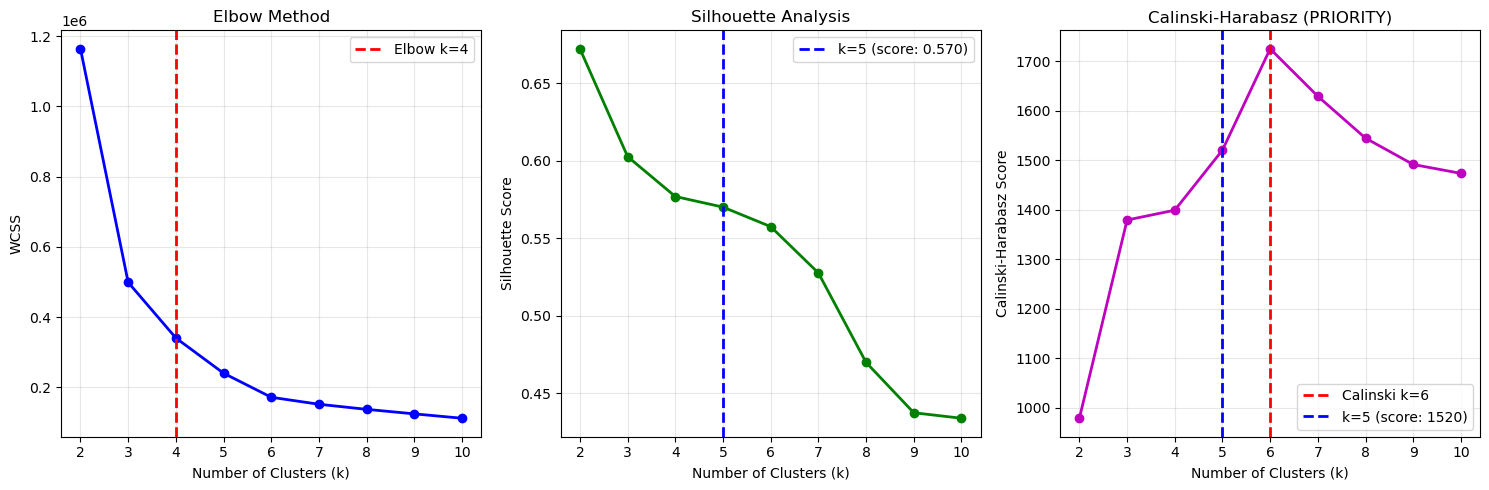


🎨 Creating outputs for calinski_optimal (k=6):
  ✓ Calendar saved: calendar_calinski_optimal_k6.png
  ✓ Patterns saved: patterns_calinski_optimal_k6.png

  📈 Cluster Analysis for calinski_optimal (k=6):
     Silhouette Score: 0.5576
     Calinski-Harabasz Score: 1725
     Cluster distribution: [66, 23, 91, 45, 82, 58]
     Daily energy range: 406.2 - 1656.3 kWh
  ✓ Cluster data saved: clusters_calinski_optimal_k6.csv

🎨 Creating outputs for elbow_optimal (k=4):
  ✓ Calendar saved: calendar_elbow_optimal_k4.png
  ✓ Patterns saved: patterns_elbow_optimal_k4.png

  📈 Cluster Analysis for elbow_optimal (k=4):
     Silhouette Score: 0.5770
     Calinski-Harabasz Score: 1399
     Cluster distribution: [74, 105, 91, 95]
     Daily energy range: 482.3 - 1564.0 kWh
  ✓ Cluster data saved: clusters_elbow_optimal_k4.csv

🎨 Creating outputs for fixed_k5 (k=5):
  ✓ Calendar saved: calendar_fixed_k5_k5.png
  ✓ Patterns saved: patterns_fixed_k5_k5.png

  📈 Cluster Analysis for fixed_k5 (k=5):
     S

In [33]:
### STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS (Calinski-Harabasz, and Elbow method(just select on breaking point) and k=5 clustering results)
### =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

def run_focused_kmeans_experiments(hourly_data_real, sample_inputs):
    """
    Run focused experiments with Calinski-Harabasz priority and fixed Elbow method
    """
    print("STEP 12.5: FOCUSED K-MEANS CLUSTERING EXPERIMENTS")
    print("=" * 70)
    
    k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
    experiment_results = {}
    
    print("\n🔬 Testing different numbers of clusters:")
    print("-" * 50)
    
    # Calculate metrics for each k
    wcss_values = []
    silhouette_scores = []
    calinski_scores = []
    
    for k in k_values:
        print(f"\nTesting k={k}:")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        
        # Calculate metrics
        wcss = kmeans.inertia_
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        calinski = calinski_harabasz_score(hourly_data_real, cluster_labels)
        
        wcss_values.append(wcss)
        silhouette_scores.append(silhouette_avg)
        calinski_scores.append(calinski)
        
        # Store results
        experiment_results[k] = {
            'wcss': wcss,
            'silhouette_score': silhouette_avg,
            'calinski_harabasz_score': calinski,
            'cluster_sizes': [np.sum(cluster_labels == i) for i in range(k)],
            'cluster_centers': kmeans.cluster_centers_,
            'cluster_labels': cluster_labels
        }
        
        print(f"  WCSS: {wcss:.0f}")
        print(f"  Silhouette: {silhouette_avg:.4f}")
        print(f"  Calinski-Harabasz: {calinski:.0f}")
        print(f"  Cluster sizes: {experiment_results[k]['cluster_sizes']}")
    
    # Find optimal k using different methods
    print("\n🎯 OPTIMAL K SELECTION:")
    print("-" * 40)
    
    # Method 1: Calinski-Harabasz (PRIORITY - higher is better)
    optimal_k_calinski = k_values[np.argmax(calinski_scores)]
    print(f"Calinski-Harabasz (PRIORITY): k = {optimal_k_calinski} (score: {max(calinski_scores):.0f})")
    
    # Method 2: Silhouette (higher is better)
    optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
    print(f"Silhouette: k = {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
    
    # Method 3: Fixed Elbow method (selects at the break point)
    optimal_k_elbow = find_elbow_at_break(k_values, wcss_values)
    print(f"Elbow (fixed): k = {optimal_k_elbow}")
    
    # Method 4: Always include k=5
    k5_index = k_values.index(5)
    print(f"Fixed k=5: Silhouette: {silhouette_scores[k5_index]:.4f}, Calinski: {calinski_scores[k5_index]:.0f}")
    
    # Create results for our three focus cases
    focus_cases = {
        'calinski_optimal': optimal_k_calinski,
        'elbow_optimal': optimal_k_elbow,
        'fixed_k5': 5
    }
    
    # Generate comprehensive outputs for focus cases
    generate_focused_outputs(focus_cases, experiment_results, hourly_data_real, k_values, 
                           wcss_values, silhouette_scores, calinski_scores)
    
    return experiment_results, focus_cases

def find_elbow_at_break(k_values, wcss_values):
    """
    Find elbow at the actual break point in WCSS curve
    """
    # Calculate percentage reduction in WCSS
    reductions = []
    for i in range(1, len(wcss_values)):
        reduction_pct = (wcss_values[i-1] - wcss_values[i]) / wcss_values[i-1] * 100
        reductions.append(reduction_pct)
    
    # Find the point where reduction drops significantly (the "break")
    # Look for the largest drop in reduction rate
    reduction_changes = []
    for i in range(1, len(reductions)):
        change = reductions[i-1] - reductions[i]  # Drop in reduction rate
        reduction_changes.append(change)
    
    # The elbow is where we have the biggest drop in improvement rate
    # Add 2 because: k_values start at 2, and we're looking at changes between consecutive k
    elbow_index = np.argmax(reduction_changes) + 2
    
    # Ensure we don't go out of bounds
    elbow_index = min(elbow_index, len(k_values) - 1)
    
    return k_values[elbow_index]

def generate_focused_outputs(focus_cases, experiment_results, hourly_data_real, k_values, 
                           wcss_values, silhouette_scores, calinski_scores):
    """
    Generate all outputs for the focused cases
    """
    print("\n📊 GENERATING OUTPUTS FOR FOCUS CASES:")
    print("-" * 50)
    
    # Create comparison plot
    create_focused_comparison_plot(k_values, wcss_values, silhouette_scores, calinski_scores, focus_cases)
    
    # Generate outputs for each focus case
    for case_name, k in focus_cases.items():
        print(f"\n🎨 Creating outputs for {case_name} (k={k}):")
        
        if k in experiment_results:
            cluster_labels = experiment_results[k]['cluster_labels']
            cluster_centers = experiment_results[k]['cluster_centers']
            cluster_sizes = experiment_results[k]['cluster_sizes']
            
            # Create calendar
            create_calendar_for_case(cluster_labels, k, case_name)
            
            # Create cluster patterns plot
            create_cluster_patterns_plot(cluster_centers, cluster_sizes, k, case_name)
            
            # Create cluster analysis
            create_cluster_analysis_report(cluster_centers, cluster_sizes, k, case_name, 
                                         experiment_results[k]['silhouette_score'],
                                         experiment_results[k]['calinski_harabasz_score'])
        else:
            print(f"  ⚠️  k={k} not found in results")

def create_focused_comparison_plot(k_values, wcss_values, silhouette_scores, calinski_scores, focus_cases):
    """
    Create focused comparison plot showing the three methods
    """
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Elbow Method
    plt.subplot(1, 3, 1)
    plt.plot(k_values, wcss_values, 'bo-', linewidth=2, markersize=6)
    plt.axvline(x=focus_cases['elbow_optimal'], color='red', linestyle='--', linewidth=2,
                label=f'Elbow k={focus_cases["elbow_optimal"]}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS')
    plt.title('Elbow Method')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Silhouette Scores
    plt.subplot(1, 3, 2)
    plt.plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=6)
    plt.axvline(x=focus_cases['fixed_k5'], color='blue', linestyle='--', linewidth=2,
                label=f'k=5 (score: {silhouette_scores[k_values.index(5)]:.3f})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Calinski-Harabasz Scores
    plt.subplot(1, 3, 3)
    plt.plot(k_values, calinski_scores, 'mo-', linewidth=2, markersize=6)
    plt.axvline(x=focus_cases['calinski_optimal'], color='red', linestyle='--', linewidth=2,
                label=f'Calinski k={focus_cases["calinski_optimal"]}')
    plt.axvline(x=focus_cases['fixed_k5'], color='blue', linestyle='--', linewidth=2,
                label=f'k=5 (score: {calinski_scores[k_values.index(5)]:.0f})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Calinski-Harabasz Score')
    plt.title('Calinski-Harabasz (PRIORITY)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "focused_k_selection_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_calendar_for_case(cluster_labels, k, case_name):
    """Create calendar visualization for a specific case"""
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    plt.figure(figsize=(15, 6))
    cmap = plt.cm.Set3
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=k-1)
    
    plt.title(f'Calendar Map - {case_name.replace("_", " ").title()} (k={k})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"calendar_{case_name}_k{k}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Calendar saved: calendar_{case_name}_k{k}.png")

def create_cluster_patterns_plot(cluster_centers, cluster_sizes, k, case_name):
    """Create representative days plot"""
    CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                     '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    plt.figure(figsize=(12, 6))
    
    for cluster_id in range(k):
        plt.plot(range(24), cluster_centers[cluster_id], 
                label=f'Cluster {cluster_id} ({cluster_sizes[cluster_id]} days)',
                linewidth=2, color=CLUSTER_COLORS[cluster_id])
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title(f'Representative Days - {case_name.replace("_", " ").title()} (k={k})', 
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"patterns_{case_name}_k{k}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Patterns saved: patterns_{case_name}_k{k}.png")

def create_cluster_analysis_report(cluster_centers, cluster_sizes, k, case_name, silhouette_score, calinski_score):
    """Create detailed cluster analysis report"""
    print(f"\n  📈 Cluster Analysis for {case_name} (k={k}):")
    print(f"     Silhouette Score: {silhouette_score:.4f}")
    print(f"     Calinski-Harabasz Score: {calinski_score:.0f}")
    print(f"     Cluster distribution: {cluster_sizes}")
    
    # Calculate daily energy totals
    daily_totals = [np.sum(cluster_centers[i]) for i in range(k)]
    print(f"     Daily energy range: {min(daily_totals):.1f} - {max(daily_totals):.1f} kWh")
    
    # Save cluster centers to CSV
    cluster_data = []
    for cluster_id in range(k):
        for hour in range(24):
            cluster_data.append({
                'cluster_id': cluster_id,
                'hour': hour,
                'energy_kwh': cluster_centers[cluster_id][hour],
                'n_days': cluster_sizes[cluster_id],
                'daily_total_kwh': daily_totals[cluster_id]
            })
    
    cluster_df = pd.DataFrame(cluster_data)
    cluster_df.to_csv(OUTPUT_DIR / f"clusters_{case_name}_k{k}.csv", index=False)
    print(f"  ✓ Cluster data saved: clusters_{case_name}_k{k}.csv")

# Run the focused experiments
print("Starting focused K-means experiments...")
sample_hourly_real = denormalize_hourly_data(y_hour_temp[0])

experiment_results, focus_cases = run_focused_kmeans_experiments(sample_hourly_real, X_temp[0])

# Save results
with open(OUTPUT_DIR / "focused_kmeans_results.json", "w") as f:
    results_to_save = {
        'focus_cases': focus_cases,
        'experiment_results': convert_numpy_to_python(experiment_results)
    }
    json.dump(results_to_save, f, indent=4)

print(f"\n✓ Focused experiment results saved to: {OUTPUT_DIR / 'focused_kmeans_results.json'}")
print("✓ Step 12.5 completed successfully!")
print(f"\n🎯 FOCUS CASES GENERATED:")
print(f"   - Calinski-Harabasz optimal: k={focus_cases['calinski_optimal']}")
print(f"   - Elbow optimal: k={focus_cases['elbow_optimal']}") 
print(f"   - Fixed k=5")
print(f"\n📁 OUTPUTS: Calendar maps, pattern plots, and cluster data for all three cases")

Starting focused K-means experiments...
STEP 12.5: FOCUSED K-MEANS CLUSTERING EXPERIMENTS

🔬 Testing different numbers of clusters:
--------------------------------------------------

Testing k=2:
  WCSS: 1163627
  Silhouette: 0.6723
  Calinski-Harabasz: 979
  Cluster sizes: [260, 105]

Testing k=3:
  WCSS: 498951
  Silhouette: 0.6028
  Calinski-Harabasz: 1379
  Cluster sizes: [103, 105, 157]

Testing k=4:
  WCSS: 340622
  Silhouette: 0.5770
  Calinski-Harabasz: 1399
  Cluster sizes: [74, 105, 91, 95]

Testing k=5:
  WCSS: 240348
  Silhouette: 0.5702
  Calinski-Harabasz: 1520
  Cluster sizes: [23, 95, 74, 91, 82]

Testing k=6:
  WCSS: 171851
  Silhouette: 0.5576
  Calinski-Harabasz: 1725
  Cluster sizes: [66, 23, 91, 45, 82, 58]

Testing k=7:
  WCSS: 151951
  Silhouette: 0.5277
  Calinski-Harabasz: 1629
  Cluster sizes: [27, 23, 90, 82, 51, 56, 36]

Testing k=8:
  WCSS: 137471
  Silhouette: 0.4700
  Calinski-Harabasz: 1545
  Cluster sizes: [41, 82, 36, 61, 23, 27, 50, 45]

Testing k=9:

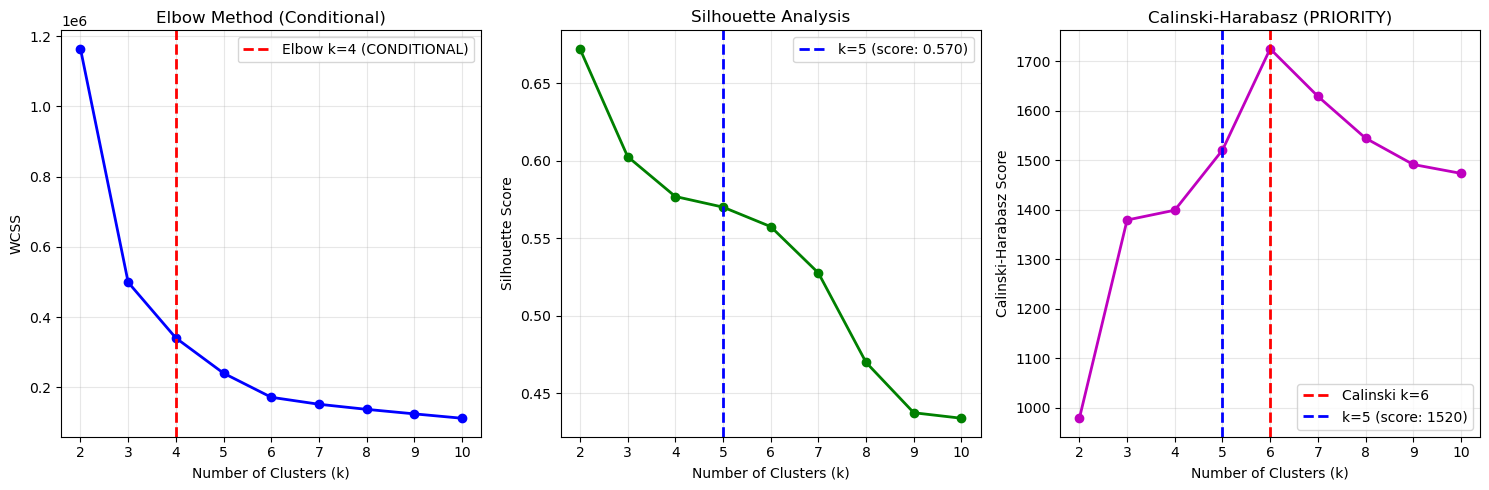


🎨 Creating outputs for calinski_optimal (k=6):
  ✓ Calendar saved: calendar_calinski_optimal_k6.png
  ✓ Patterns saved: patterns_calinski_optimal_k6.png

  📈 Cluster Analysis for calinski_optimal (k=6):
     Silhouette Score: 0.5576
     Calinski-Harabasz Score: 1725
     Cluster distribution: [66, 23, 91, 45, 82, 58]
     Daily energy range: 406.2 - 1656.3 kWh
  ✓ Cluster data saved: clusters_calinski_optimal_k6.csv

🎨 Creating outputs for elbow_optimal (k=4):
  ✓ Calendar saved: calendar_elbow_optimal_k4.png
  ✓ Patterns saved: patterns_elbow_optimal_k4.png

  📈 Cluster Analysis for elbow_optimal (k=4):
     Silhouette Score: 0.5770
     Calinski-Harabasz Score: 1399
     Cluster distribution: [74, 105, 91, 95]
     Daily energy range: 482.3 - 1564.0 kWh
  ✓ Cluster data saved: clusters_elbow_optimal_k4.csv

🎨 Creating outputs for fixed_k5 (k=5):
  ✓ Calendar saved: calendar_fixed_k5_k5.png
  ✓ Patterns saved: patterns_fixed_k5_k5.png

  📈 Cluster Analysis for fixed_k5 (k=5):
     S

In [34]:
### STEP 12.5: K-MEANS CLUSTERING PARAMETER EXPERIMENTS ( (Calinski-Harabasz, and Elbow method(select k around 5) and k=5 clustering results))
### =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

def run_focused_kmeans_experiments(hourly_data_real, sample_inputs):
    """
    Run focused experiments with Calinski-Harabasz priority and CONDITIONAL Elbow method
    """
    print("STEP 12.5: FOCUSED K-MEANS CLUSTERING EXPERIMENTS")
    print("=" * 70)
    
    k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
    experiment_results = {}
    
    print("\n🔬 Testing different numbers of clusters:")
    print("-" * 50)
    
    # Calculate metrics for each k
    wcss_values = []
    silhouette_scores = []
    calinski_scores = []
    
    for k in k_values:
        print(f"\nTesting k={k}:")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(hourly_data_real)
        
        # Calculate metrics
        wcss = kmeans.inertia_
        silhouette_avg = silhouette_score(hourly_data_real, cluster_labels)
        calinski = calinski_harabasz_score(hourly_data_real, cluster_labels)
        
        wcss_values.append(wcss)
        silhouette_scores.append(silhouette_avg)
        calinski_scores.append(calinski)
        
        # Store results
        experiment_results[k] = {
            'wcss': wcss,
            'silhouette_score': silhouette_avg,
            'calinski_harabasz_score': calinski,
            'cluster_sizes': [np.sum(cluster_labels == i) for i in range(k)],
            'cluster_centers': kmeans.cluster_centers_,
            'cluster_labels': cluster_labels
        }
        
        print(f"  WCSS: {wcss:.0f}")
        print(f"  Silhouette: {silhouette_avg:.4f}")
        print(f"  Calinski-Harabasz: {calinski:.0f}")
        print(f"  Cluster sizes: {experiment_results[k]['cluster_sizes']}")
    
    # Find optimal k using different methods
    print("\n🎯 OPTIMAL K SELECTION:")
    print("-" * 40)
    
    # Method 1: Calinski-Harabasz (PRIORITY - higher is better)
    optimal_k_calinski = k_values[np.argmax(calinski_scores)]
    print(f"Calinski-Harabasz (PRIORITY): k = {optimal_k_calinski} (score: {max(calinski_scores):.0f})")
    
    # Method 2: Silhouette (higher is better)
    optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
    print(f"Silhouette: k = {optimal_k_silhouette} (score: {max(silhouette_scores):.4f})")
    
    # Method 3: CONDITIONAL Elbow method
    optimal_k_elbow = find_elbow_conditional(k_values, wcss_values)
    print(f"Elbow (CONDITIONAL): k = {optimal_k_elbow}")
    
    # Method 4: Always include k=5
    k5_index = k_values.index(5)
    print(f"Fixed k=5: Silhouette: {silhouette_scores[k5_index]:.4f}, Calinski: {calinski_scores[k5_index]:.0f}")
    
    # Create results for our three focus cases
    focus_cases = {
        'calinski_optimal': optimal_k_calinski,
        'elbow_optimal': optimal_k_elbow,
        'fixed_k5': 5
    }
    
    # Generate comprehensive outputs for focus cases
    generate_focused_outputs(focus_cases, experiment_results, hourly_data_real, k_values, 
                           wcss_values, silhouette_scores, calinski_scores)
    
    return experiment_results, focus_cases

def find_elbow_conditional(k_values, wcss_values):
    """
    Conditional Elbow method:
    - If k after break >= 5, select k AT break point
    - If k after break < 5, select k AFTER break (+1)
    """
    # Calculate percentage reduction in WCSS
    reductions = []
    for i in range(1, len(wcss_values)):
        reduction_pct = (wcss_values[i-1] - wcss_values[i]) / wcss_values[i-1] * 100
        reductions.append(reduction_pct)
    
    # Find the point where reduction drops significantly (the "break")
    reduction_changes = []
    for i in range(1, len(reductions)):
        change = reductions[i-1] - reductions[i]  # Drop in reduction rate
        reduction_changes.append(change)
    
    # Find the break point index
    break_index = np.argmax(reduction_changes)
    
    # k value AT the break point
    k_at_break = k_values[break_index + 1]  # +1 because reductions start from k=2→3
    
    # k value AFTER the break point (earlier version)
    k_after_break = k_values[break_index + 2]  # +2 to get value after break
    
    # Apply conditional logic
    if k_after_break >= 5:
        # If k after break is >= 5, select k AT break point
        selected_k = k_at_break
        print(f"  Elbow: k_after_break={k_after_break} >= 5, selecting k_at_break={k_at_break}")
    else:
        # If k after break is < 5, select k AFTER break (+1)
        selected_k = k_after_break
        print(f"  Elbow: k_after_break={k_after_break} < 5, selecting k_after_break={k_after_break}")
    
    # Ensure we don't go out of bounds
    selected_k = min(selected_k, k_values[-1])
    
    return selected_k

def generate_focused_outputs(focus_cases, experiment_results, hourly_data_real, k_values, 
                           wcss_values, silhouette_scores, calinski_scores):
    """
    Generate all outputs for the focused cases
    """
    print("\n📊 GENERATING OUTPUTS FOR FOCUS CASES:")
    print("-" * 50)
    
    # Create comparison plot
    create_focused_comparison_plot(k_values, wcss_values, silhouette_scores, calinski_scores, focus_cases)
    
    # Generate outputs for each focus case
    for case_name, k in focus_cases.items():
        print(f"\n🎨 Creating outputs for {case_name} (k={k}):")
        
        if k in experiment_results:
            cluster_labels = experiment_results[k]['cluster_labels']
            cluster_centers = experiment_results[k]['cluster_centers']
            cluster_sizes = experiment_results[k]['cluster_sizes']
            
            # Create calendar
            create_calendar_for_case(cluster_labels, k, case_name)
            
            # Create cluster patterns plot
            create_cluster_patterns_plot(cluster_centers, cluster_sizes, k, case_name)
            
            # Create cluster analysis
            create_cluster_analysis_report(cluster_centers, cluster_sizes, k, case_name, 
                                         experiment_results[k]['silhouette_score'],
                                         experiment_results[k]['calinski_harabasz_score'])
        else:
            print(f"  ⚠️  k={k} not found in results")

def create_focused_comparison_plot(k_values, wcss_values, silhouette_scores, calinski_scores, focus_cases):
    """
    Create focused comparison plot showing the three methods
    """
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Elbow Method (CONDITIONAL)
    plt.subplot(1, 3, 1)
    plt.plot(k_values, wcss_values, 'bo-', linewidth=2, markersize=6)
    plt.axvline(x=focus_cases['elbow_optimal'], color='red', linestyle='--', linewidth=2,
                label=f'Elbow k={focus_cases["elbow_optimal"]} (CONDITIONAL)')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS')
    plt.title('Elbow Method (Conditional)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Silhouette Scores
    plt.subplot(1, 3, 2)
    plt.plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=6)
    plt.axvline(x=focus_cases['fixed_k5'], color='blue', linestyle='--', linewidth=2,
                label=f'k=5 (score: {silhouette_scores[k_values.index(5)]:.3f})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Calinski-Harabasz Scores
    plt.subplot(1, 3, 3)
    plt.plot(k_values, calinski_scores, 'mo-', linewidth=2, markersize=6)
    plt.axvline(x=focus_cases['calinski_optimal'], color='red', linestyle='--', linewidth=2,
                label=f'Calinski k={focus_cases["calinski_optimal"]}')
    plt.axvline(x=focus_cases['fixed_k5'], color='blue', linestyle='--', linewidth=2,
                label=f'k=5 (score: {calinski_scores[k_values.index(5)]:.0f})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Calinski-Harabasz Score')
    plt.title('Calinski-Harabasz (PRIORITY)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "focused_k_selection_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_calendar_for_case(cluster_labels, k, case_name):
    """Create calendar visualization for a specific case"""
    # Create calendar data
    calendar_data = np.full((12, 31), -1)
    month_days = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    day_counter = 0
    for month in range(12):
        for day in range(month_days[month]):
            if day_counter < 365:
                calendar_data[month, day] = cluster_labels[day_counter]
                day_counter += 1
    
    plt.figure(figsize=(15, 6))
    cmap = plt.cm.Set3
    im = plt.imshow(calendar_data, cmap=cmap, aspect='auto', vmin=0, vmax=k-1)
    
    plt.title(f'Calendar Map - {case_name.replace("_", " ").title()} (k={k})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Day of Month')
    plt.ylabel('Month')
    plt.yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Cluster ID', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"calendar_{case_name}_k{k}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Calendar saved: calendar_{case_name}_k{k}.png")

def create_cluster_patterns_plot(cluster_centers, cluster_sizes, k, case_name):
    """Create representative days plot"""
    CLUSTER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                     '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    plt.figure(figsize=(12, 6))
    
    for cluster_id in range(k):
        plt.plot(range(24), cluster_centers[cluster_id], 
                label=f'Cluster {cluster_id} ({cluster_sizes[cluster_id]} days)',
                linewidth=2, color=CLUSTER_COLORS[cluster_id])
    
    plt.xlabel('Hour of Day')
    plt.ylabel('Energy Consumption (kWh)')
    plt.title(f'Representative Days - {case_name.replace("_", " ").title()} (k={k})', 
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"patterns_{case_name}_k{k}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Patterns saved: patterns_{case_name}_k{k}.png")

def create_cluster_analysis_report(cluster_centers, cluster_sizes, k, case_name, silhouette_score, calinski_score):
    """Create detailed cluster analysis report"""
    print(f"\n  📈 Cluster Analysis for {case_name} (k={k}):")
    print(f"     Silhouette Score: {silhouette_score:.4f}")
    print(f"     Calinski-Harabasz Score: {calinski_score:.0f}")
    print(f"     Cluster distribution: {cluster_sizes}")
    
    # Calculate daily energy totals
    daily_totals = [np.sum(cluster_centers[i]) for i in range(k)]
    print(f"     Daily energy range: {min(daily_totals):.1f} - {max(daily_totals):.1f} kWh")
    
    # Save cluster centers to CSV
    cluster_data = []
    for cluster_id in range(k):
        for hour in range(24):
            cluster_data.append({
                'cluster_id': cluster_id,
                'hour': hour,
                'energy_kwh': cluster_centers[cluster_id][hour],
                'n_days': cluster_sizes[cluster_id],
                'daily_total_kwh': daily_totals[cluster_id]
            })
    
    cluster_df = pd.DataFrame(cluster_data)
    cluster_df.to_csv(OUTPUT_DIR / f"clusters_{case_name}_k{k}.csv", index=False)
    print(f"  ✓ Cluster data saved: clusters_{case_name}_k{k}.csv")

# Run the focused experiments
print("Starting focused K-means experiments...")
sample_hourly_real = denormalize_hourly_data(y_hour_temp[0])

experiment_results, focus_cases = run_focused_kmeans_experiments(sample_hourly_real, X_temp[0])

# Save results
with open(OUTPUT_DIR / "focused_kmeans_results.json", "w") as f:
    results_to_save = {
        'focus_cases': focus_cases,
        'experiment_results': convert_numpy_to_python(experiment_results)
    }
    json.dump(results_to_save, f, indent=4)

print(f"\n✓ Focused experiment results saved to: {OUTPUT_DIR / 'focused_kmeans_results.json'}")
print("✓ Step 12.5 completed successfully!")
print(f"\n🎯 FOCUS CASES GENERATED:")
print(f"   - Calinski-Harabasz optimal: k={focus_cases['calinski_optimal']}")
print(f"   - Elbow optimal (CONDITIONAL): k={focus_cases['elbow_optimal']}") 
print(f"   - Fixed k=5")
print(f"\n📁 OUTPUTS: Calendar maps, pattern plots, and cluster data for all three cases")

Starting comprehensive sensitivity analysis...
STEP 13: SENSITIVITY ANALYSIS OF INPUT PARAMETERS
Getting model predictions for sensitivity analysis...
✓ Collected 450 samples for sensitivity analysis

🔍 1. CORRELATION ANALYSIS
----------------------------------------
Top 5 most correlated parameters with Total Energy:
  Area           : 0.692
  N_of_Fl        : 0.627
  EPD            : 0.395
  Wall_R         : 0.110
  LPD            : 0.096

🔍 2. ONE-AT-A-TIME SENSITIVITY ANALYSIS
----------------------------------------
Top 5 most sensitive parameters (OAT analysis):
  Area           : 10.2% effect (±10.4%)
  EPD            : 8.3% effect (±8.4%)
  N_of_Fl        : 4.2% effect (±8.3%)
  LPD            : 2.7% effect (±2.8%)
  window_shgc    : 1.8% effect (±1.8%)

🔍 3. MORRIS ELEMENTARY EFFECTS ANALYSIS
----------------------------------------
Running Morris analysis with 50 trajectories...
Top 5 parameters by Morris mu* (importance):
  Area           : μ* = 708.6 (μ = 708.6)
  N_of_Fl  

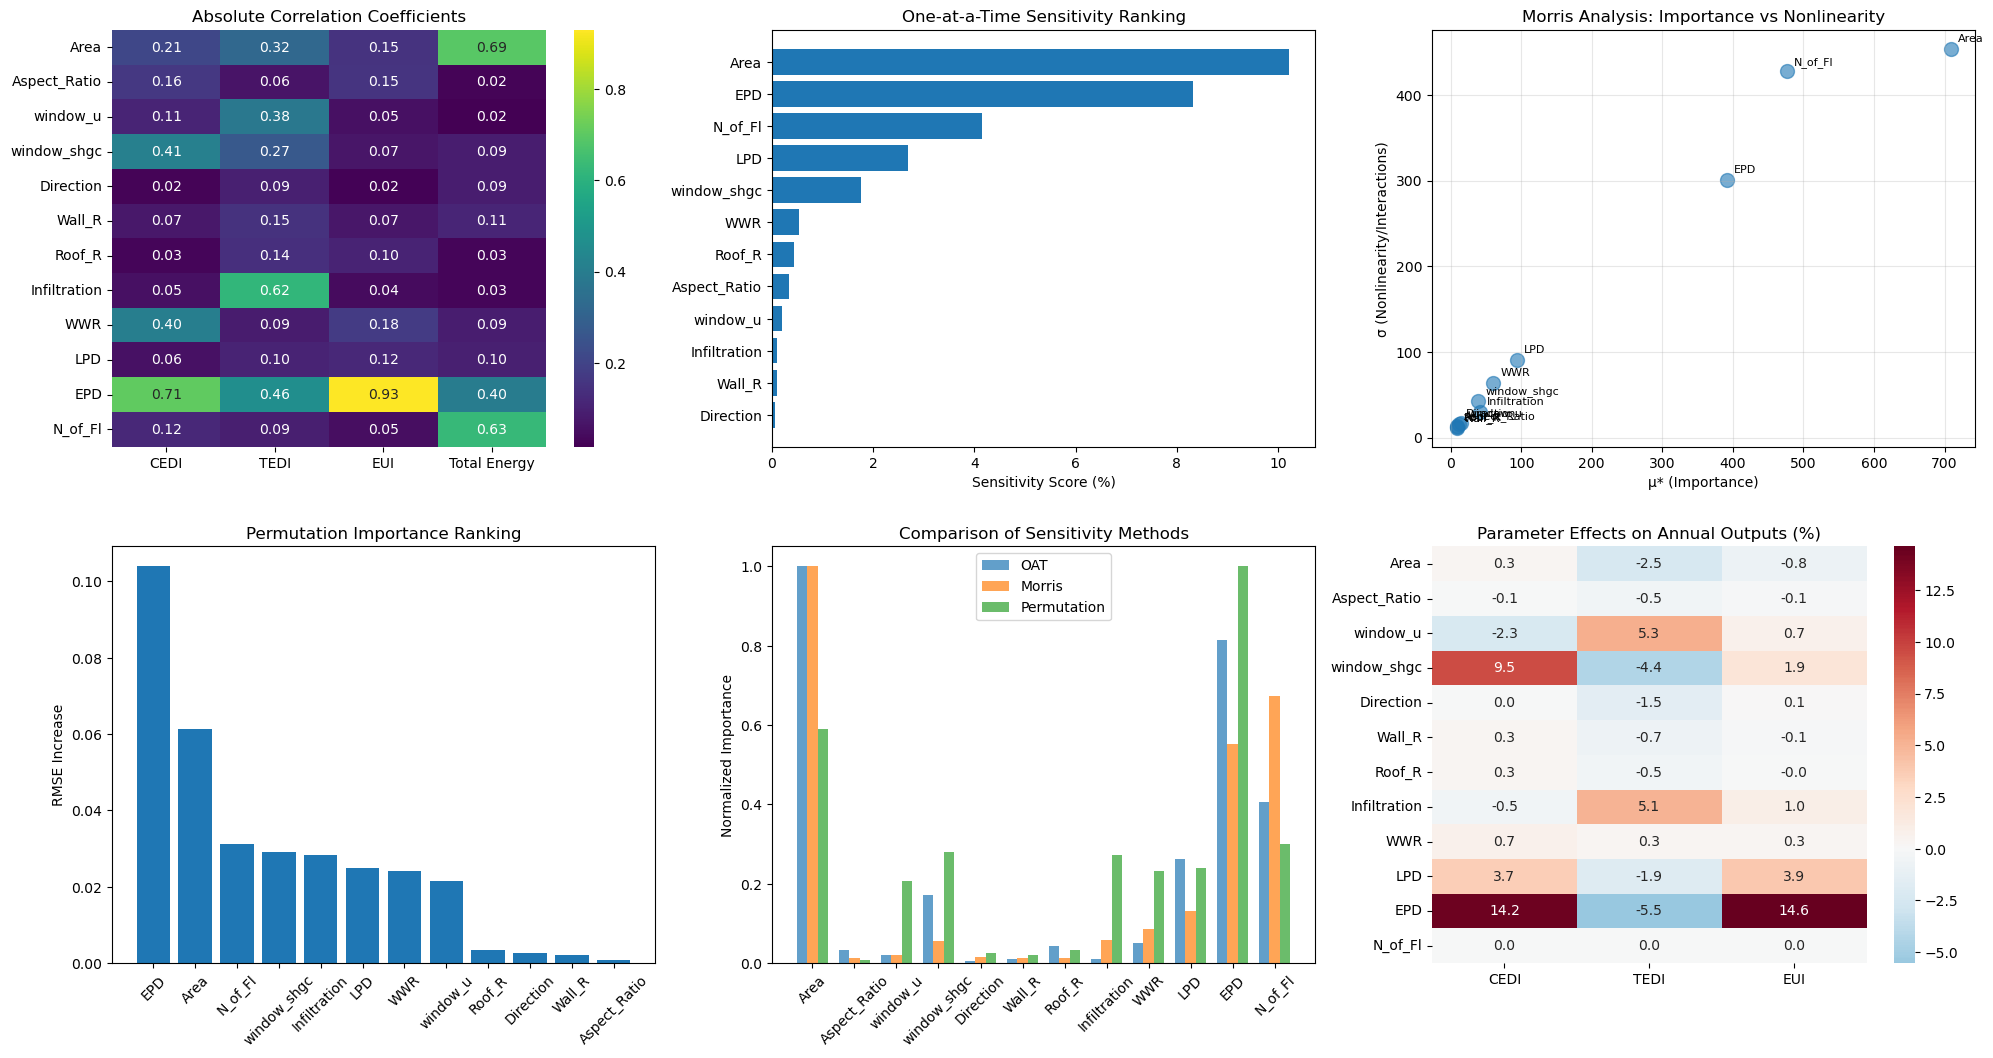


🎯 COMPREHENSIVE SENSITIVITY ANALYSIS SUMMARY

🏆 TOP 10 MOST INFLUENTIAL PARAMETERS (Overall Ranking):
----------------------------------------------------------------------
 1. Area            | Score: 5.506 | Corr: 0.692 | OAT: 10.2% | Morris: 708.6 | Perm: 0.0614
 2. EPD             | Score: 4.861 | Corr: 0.395 | OAT: 8.3% | Morris: 391.2 | Perm: 0.1040
 3. N_of_Fl         | Score: 3.428 | Corr: 0.627 | OAT: 4.2% | Morris: 476.9 | Perm: 0.0313
 4. LPD             | Score: 1.184 | Corr: 0.096 | OAT: 2.7% | Morris: 93.8 | Perm: 0.0249
 5. window_shgc     | Score: 0.987 | Corr: 0.090 | OAT: 1.8% | Morris: 39.1 | Perm: 0.0290
 6. WWR             | Score: 0.940 | Corr: 0.089 | OAT: 0.5% | Morris: 60.3 | Perm: 0.0241
 7. Infiltration    | Score: 0.925 | Corr: 0.027 | OAT: 0.1% | Morris: 41.0 | Perm: 0.0284
 8. window_u        | Score: 0.619 | Corr: 0.016 | OAT: 0.2% | Morris: 14.3 | Perm: 0.0215
 9. Direction       | Score: 0.151 | Corr: 0.088 | OAT: 0.1% | Morris: 11.7 | Perm: 0.0028
10.

In [31]:
### STEP 13: SENSITIVITY ANALYSIS OF INPUT PARAMETERS
### =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.inspection import permutation_importance
import pandas as pd

def perform_sensitivity_analysis(ensemble_model, X_test, y_ann_test, y_hour_test, n_runs=100):
    """
    Perform comprehensive sensitivity analysis on input parameters
    """
    print("STEP 13: SENSITIVITY ANALYSIS OF INPUT PARAMETERS")
    print("=" * 70)
    
    # Create test dataset
    test_dataset = BuildingDataset(X_test, y_ann_test, y_hour_test)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Get predictions for correlation analysis
    print("Getting model predictions for sensitivity analysis...")
    all_X = []
    all_ann_pred = []
    all_hour_pred = []
    
    ensemble_model.eval()
    with torch.no_grad():
        for X, y_ann, y_hour in test_loader:
            X = X.to(DEVICE)
            pred_ann, pred_hour = ensemble_model.predict(X)
            
            all_X.append(X.cpu().numpy())
            all_ann_pred.append(pred_ann.cpu().numpy())
            all_hour_pred.append(pred_hour.cpu().numpy())
    
    # Combine all batches
    X_combined = np.vstack(all_X)
    ann_pred_combined = np.vstack(all_ann_pred)
    hour_pred_combined = np.vstack(all_hour_pred)
    
    # Calculate total hourly energy for each sample
    total_hourly_energy = np.sum(hour_pred_combined.reshape(hour_pred_combined.shape[0], -1), axis=1)
    
    print(f"✓ Collected {X_combined.shape[0]} samples for sensitivity analysis")
    
    # 1. Correlation Analysis
    print("\n🔍 1. CORRELATION ANALYSIS")
    print("-" * 40)
    correlation_results = correlation_analysis(X_combined, ann_pred_combined, total_hourly_energy)
    
    # 2. One-at-a-Time (OAT) Sensitivity Analysis
    print("\n🔍 2. ONE-AT-A-TIME SENSITIVITY ANALYSIS")
    print("-" * 40)
    oat_results = oat_sensitivity_analysis(ensemble_model, X_test[0])  # Use first sample as baseline
    
    # 3. Morris Elementary Effects Analysis
    print("\n🔍 3. MORRIS ELEMENTARY EFFECTS ANALYSIS")
    print("-" * 40)
    morris_results = morris_analysis(ensemble_model, n_runs=n_runs)
    
    # 4. Permutation Importance
    print("\n🔍 4. PERMUTATION IMPORTANCE ANALYSIS")
    print("-" * 40)
    permutation_results = permutation_importance_analysis(ensemble_model, X_test, y_ann_test, y_hour_test)
    
    # Create comprehensive visualization
    create_sensitivity_visualizations(correlation_results, oat_results, morris_results, permutation_results)
    
    # Print summary and recommendations
    print_sensitivity_summary(correlation_results, oat_results, morris_results, permutation_results)
    
    return {
        'correlation': correlation_results,
        'oat': oat_results,
        'morris': morris_results,
        'permutation': permutation_results
    }

def correlation_analysis(X, ann_pred, total_energy):
    """
    Calculate correlation coefficients between inputs and outputs
    """
    results = {}
    
    # Denormalize inputs for interpretation
    X_denorm = denormalize_inputs_batch(X)
    
    output_metrics = {
        'CEDI': ann_pred[:, 0],
        'TEDI': ann_pred[:, 1], 
        'EUI': ann_pred[:, 2],
        'Total_Hourly_Energy': total_energy
    }
    
    for param in PARAM_NAMES_EXPECTED:
        param_values = X_denorm[param]
        results[param] = {}
        
        for output_name, output_values in output_metrics.items():
            # Pearson correlation (linear)
            pearson_corr, pearson_p = pearsonr(param_values, output_values)
            # Spearman correlation (monotonic)
            spearman_corr, spearman_p = spearmanr(param_values, output_values)
            
            results[param][output_name] = {
                'pearson': float(pearson_corr),
                'pearson_p': float(pearson_p),
                'spearman': float(spearman_corr),
                'spearman_p': float(spearman_p),
                'abs_correlation': float(max(abs(pearson_corr), abs(spearman_corr)))
            }
    
    # Print top correlations
    print("Top 5 most correlated parameters with Total Energy:")
    total_correlations = []
    for param in PARAM_NAMES_EXPECTED:
        corr = results[param]['Total_Hourly_Energy']['abs_correlation']
        total_correlations.append((param, corr))
    
    total_correlations.sort(key=lambda x: x[1], reverse=True)
    for param, corr in total_correlations[:5]:
        print(f"  {param:15}: {corr:.3f}")
    
    return results

def oat_sensitivity_analysis(ensemble_model, baseline_input, variation=0.1):
    """
    One-at-a-Time sensitivity analysis by varying each parameter
    """
    results = {}
    baseline_input = torch.tensor(baseline_input, dtype=torch.float32).to(DEVICE)
    
    # Get baseline prediction
    with torch.no_grad():
        baseline_ann, baseline_hour = ensemble_model.predict(baseline_input.unsqueeze(0))
        baseline_ann = baseline_ann.cpu().numpy()[0]
        baseline_hour = baseline_hour.cpu().numpy()[0, 0, :, :]
        baseline_total = np.sum(baseline_hour)
    
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        results[param] = {}
        
        # Test ±variation from baseline
        for direction in [-1, 1]:
            test_input = baseline_input.clone()
            variation_amount = direction * variation
            
            # Apply variation (staying in normalized space)
            test_input[i] = torch.clamp(test_input[i] + variation_amount, 0, 1)
            
            with torch.no_grad():
                test_ann, test_hour = ensemble_model.predict(test_input.unsqueeze(0))
                test_ann = test_ann.cpu().numpy()[0]
                test_hour = test_hour.cpu().numpy()[0, 0, :, :]
                test_total = np.sum(test_hour)
            
            # Calculate sensitivity
            ann_change = (test_ann - baseline_ann) / baseline_ann * 100
            total_change = (test_total - baseline_total) / baseline_total * 100
            
            direction_key = 'decrease' if direction == -1 else 'increase'
            results[param][direction_key] = {
                'annual_change_pct': ann_change.tolist(),
                'total_energy_change_pct': float(total_change),
                'abs_effect': float(abs(total_change))
            }
    
    # Calculate overall sensitivity score
    for param in PARAM_NAMES_EXPECTED:
        avg_effect = (results[param]['increase']['abs_effect'] + 
                     results[param]['decrease']['abs_effect']) / 2
        results[param]['sensitivity_score'] = avg_effect
    
    # Print top sensitive parameters
    print("Top 5 most sensitive parameters (OAT analysis):")
    sensitivities = [(param, results[param]['sensitivity_score']) 
                    for param in PARAM_NAMES_EXPECTED]
    sensitivities.sort(key=lambda x: x[1], reverse=True)
    
    for param, score in sensitivities[:5]:
        inc_effect = results[param]['increase']['total_energy_change_pct']
        dec_effect = results[param]['decrease']['total_energy_change_pct']
        print(f"  {param:15}: {score:.1f}% effect (±{max(abs(inc_effect), abs(dec_effect)):.1f}%)")
    
    return results

def morris_analysis(ensemble_model, n_runs=100, p=4):
    """
    Morris Elementary Effects analysis for global sensitivity
    """
    print(f"Running Morris analysis with {n_runs} trajectories...")
    
    # Generate Morris trajectories
    trajectories = generate_morris_trajectories(n_runs, p)
    elementary_effects = {param: [] for param in PARAM_NAMES_EXPECTED}
    
    for trajectory in trajectories:
        for i in range(len(trajectory) - 1):
            # Find which parameter changed
            diff = trajectory[i+1] - trajectory[i]
            changed_param = np.argwhere(diff != 0)[0][0]
            
            # Get predictions for both points
            with torch.no_grad():
                pred1_ann, pred1_hour = ensemble_model.predict(
                    torch.tensor(trajectory[i], dtype=torch.float32).to(DEVICE).unsqueeze(0)
                )
                pred2_ann, pred2_hour = ensemble_model.predict(
                    torch.tensor(trajectory[i+1], dtype=torch.float32).to(DEVICE).unsqueeze(0)
                )
            
            total1 = np.sum(pred1_hour.cpu().numpy())
            total2 = np.sum(pred2_hour.cpu().numpy())
            
            # Calculate elementary effect
            delta = trajectory[i+1, changed_param] - trajectory[i, changed_param]
            ee = (total2 - total1) / delta
            
            elementary_effects[PARAM_NAMES_EXPECTED[changed_param]].append(float(ee))
    
    # Calculate Morris statistics
    results = {}
    for param in PARAM_NAMES_EXPECTED:
        ees = elementary_effects[param]
        if ees:
            mu = np.mean(ees)
            mu_star = np.mean(np.abs(ees))
            sigma = np.std(ees)
            
            results[param] = {
                'mu': float(mu),        # Overall effect
                'mu_star': float(mu_star),  # Absolute effect (importance)
                'sigma': float(sigma),   # Nonlinearity/interactions
                'n_effects': len(ees)
            }
    
    # Print Morris results
    print("Top 5 parameters by Morris mu* (importance):")
    morris_ranking = [(param, results[param]['mu_star']) for param in PARAM_NAMES_EXPECTED]
    morris_ranking.sort(key=lambda x: x[1], reverse=True)
    
    for param, mu_star in morris_ranking[:5]:
        mu = results[param]['mu']
        print(f"  {param:15}: μ* = {mu_star:.1f} (μ = {mu:.1f})")
    
    return results

def generate_morris_trajectories(n_runs, p):
    """
    Generate trajectories for Morris analysis
    """
    trajectories = []
    delta = 1.0 / (p - 1)
    
    for _ in range(n_runs):
        # Random starting point
        start = np.random.random(len(PARAM_NAMES_EXPECTED))
        start = np.floor(start * (p - 1)) / (p - 1)  # Snap to grid
        
        trajectory = [start.copy()]
        current = start.copy()
        
        # Random order of parameters
        order = np.random.permutation(len(PARAM_NAMES_EXPECTED))
        
        for param_idx in order:
            current[param_idx] = (current[param_idx] + delta) % 1.0
            trajectory.append(current.copy())
        
        trajectories.append(np.array(trajectory))
    
    return trajectories

def permutation_importance_analysis(ensemble_model, X_test, y_ann_test, y_hour_test, n_repeats=10):
    """
    Calculate permutation importance for each parameter
    """
    print("Calculating permutation importance...")
    
    # Use a subset for efficiency
    n_samples = min(100, len(X_test))
    X_subset = X_test[:n_samples]
    
    # Get baseline score
    baseline_ann_pred, baseline_hour_pred = predict_batch(ensemble_model, X_subset)
    baseline_ann_rmse = np.sqrt(mean_squared_error(y_ann_test[:n_samples], baseline_ann_pred))
    baseline_hour_rmse = np.sqrt(mean_squared_error(
        y_hour_test[:n_samples].reshape(n_samples, -1), 
        baseline_hour_pred.reshape(n_samples, -1)
    ))
    
    results = {}
    
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        importance_scores_ann = []
        importance_scores_hour = []
        
        for _ in range(n_repeats):
            # Shuffle the parameter
            X_permuted = X_subset.copy()
            np.random.shuffle(X_permuted[:, i])
            
            # Get predictions with shuffled parameter
            perm_ann_pred, perm_hour_pred = predict_batch(ensemble_model, X_permuted)
            
            # Calculate performance decrease
            perm_ann_rmse = np.sqrt(mean_squared_error(y_ann_test[:n_samples], perm_ann_pred))
            perm_hour_rmse = np.sqrt(mean_squared_error(
                y_hour_test[:n_samples].reshape(n_samples, -1),
                perm_hour_pred.reshape(n_samples, -1)
            ))
            
            importance_scores_ann.append(perm_ann_rmse - baseline_ann_rmse)
            importance_scores_hour.append(perm_hour_rmse - baseline_hour_rmse)
        
        results[param] = {
            'annual_importance': float(np.mean(importance_scores_ann)),
            'hourly_importance': float(np.mean(importance_scores_hour)),
            'overall_importance': float((np.mean(importance_scores_ann) + np.mean(importance_scores_hour)) / 2)
        }
    
    # Print permutation importance results
    print("Top 5 parameters by permutation importance:")
    perm_ranking = [(param, results[param]['overall_importance']) for param in PARAM_NAMES_EXPECTED]
    perm_ranking.sort(key=lambda x: x[1], reverse=True)
    
    for param, importance in perm_ranking[:5]:
        print(f"  {param:15}: {importance:.4f} (RMSE increase)")
    
    return results

def predict_batch(ensemble_model, X_batch):
    """Predict batch of inputs"""
    ensemble_model.eval()
    all_ann_pred = []
    all_hour_pred = []
    
    with torch.no_grad():
        for i in range(0, len(X_batch), 32):
            batch = X_batch[i:i+32]
            X_tensor = torch.tensor(batch, dtype=torch.float32).to(DEVICE)
            pred_ann, pred_hour = ensemble_model.predict(X_tensor)
            
            all_ann_pred.append(pred_ann.cpu().numpy())
            all_hour_pred.append(pred_hour.cpu().numpy())
    
    return np.vstack(all_ann_pred), np.vstack(all_hour_pred)

def denormalize_inputs_batch(X_norm):
    """Denormalize batch of inputs for interpretation"""
    X_denorm = {}
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        vmin, vmax = INPUT_RANGES[param]
        X_denorm[param] = X_norm[:, i] * (vmax - vmin) + vmin
    return X_denorm

def create_sensitivity_visualizations(correlation_results, oat_results, morris_results, permutation_results):
    """
    Create comprehensive sensitivity analysis visualizations
    """
    print("\n📊 Creating sensitivity analysis visualizations...")
    
    fig = plt.figure(figsize=(20, 15))
    
    # Plot 1: Correlation heatmap
    plt.subplot(3, 3, 1)
    correlation_matrix = np.zeros((len(PARAM_NAMES_EXPECTED), 4))  # 4 outputs
    
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        for j, output in enumerate(['CEDI', 'TEDI', 'EUI', 'Total_Hourly_Energy']):
            correlation_matrix[i, j] = correlation_results[param][output]['abs_correlation']
    
    sns.heatmap(correlation_matrix, xticklabels=['CEDI', 'TEDI', 'EUI', 'Total Energy'],
                yticklabels=PARAM_NAMES_EXPECTED, annot=True, fmt='.2f', cmap='viridis')
    plt.title('Absolute Correlation Coefficients')
    plt.tight_layout()
    
    # Plot 2: OAT sensitivity ranking
    plt.subplot(3, 3, 2)
    oat_scores = [oat_results[param]['sensitivity_score'] for param in PARAM_NAMES_EXPECTED]
    sorted_indices = np.argsort(oat_scores)[::-1]
    
    plt.barh(range(len(PARAM_NAMES_EXPECTED)), [oat_scores[i] for i in sorted_indices])
    plt.yticks(range(len(PARAM_NAMES_EXPECTED)), [PARAM_NAMES_EXPECTED[i] for i in sorted_indices])
    plt.xlabel('Sensitivity Score (%)')
    plt.title('One-at-a-Time Sensitivity Ranking')
    plt.gca().invert_yaxis()
    
    # Plot 3: Morris analysis results
    plt.subplot(3, 3, 3)
    mu_star = [morris_results[param]['mu_star'] for param in PARAM_NAMES_EXPECTED]
    sigma = [morris_results[param]['sigma'] for param in PARAM_NAMES_EXPECTED]
    
    plt.scatter(mu_star, sigma, s=100, alpha=0.6)
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        plt.annotate(param, (mu_star[i], sigma[i]), xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.xlabel('μ* (Importance)')
    plt.ylabel('σ (Nonlinearity/Interactions)')
    plt.title('Morris Analysis: Importance vs Nonlinearity')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Permutation importance
    plt.subplot(3, 3, 4)
    perm_scores = [permutation_results[param]['overall_importance'] for param in PARAM_NAMES_EXPECTED]
    sorted_indices_perm = np.argsort(perm_scores)[::-1]
    
    plt.bar(range(len(PARAM_NAMES_EXPECTED)), [perm_scores[i] for i in sorted_indices_perm])
    plt.xticks(range(len(PARAM_NAMES_EXPECTED)), [PARAM_NAMES_EXPECTED[i] for i in sorted_indices_perm], rotation=45)
    plt.ylabel('RMSE Increase')
    plt.title('Permutation Importance Ranking')
    
    # Plot 5: Combined ranking comparison
    plt.subplot(3, 3, 5)
    # Normalize scores for comparison
    oat_norm = [oat_results[param]['sensitivity_score'] for param in PARAM_NAMES_EXPECTED]
    oat_norm = np.array(oat_norm) / max(oat_norm)
    
    morris_norm = [morris_results[param]['mu_star'] for param in PARAM_NAMES_EXPECTED]
    morris_norm = np.array(morris_norm) / max(morris_norm)
    
    perm_norm = [permutation_results[param]['overall_importance'] for param in PARAM_NAMES_EXPECTED]
    perm_norm = np.array(perm_norm) / max(perm_norm)
    
    x = range(len(PARAM_NAMES_EXPECTED))
    width = 0.25
    
    plt.bar([i - width for i in x], oat_norm, width, label='OAT', alpha=0.7)
    plt.bar(x, morris_norm, width, label='Morris', alpha=0.7)
    plt.bar([i + width for i in x], perm_norm, width, label='Permutation', alpha=0.7)
    
    plt.xticks(x, PARAM_NAMES_EXPECTED, rotation=45)
    plt.ylabel('Normalized Importance')
    plt.title('Comparison of Sensitivity Methods')
    plt.legend()
    
    # Plot 6: Parameter effects on different outputs
    plt.subplot(3, 3, 6)
    effects_matrix = np.zeros((len(PARAM_NAMES_EXPECTED), 3))  # CEDI, TEDI, EUI
    
    for i, param in enumerate(PARAM_NAMES_EXPECTED):
        for j in range(3):
            effects_matrix[i, j] = oat_results[param]['increase']['annual_change_pct'][j]
    
    sns.heatmap(effects_matrix, xticklabels=['CEDI', 'TEDI', 'EUI'],
                yticklabels=PARAM_NAMES_EXPECTED, annot=True, fmt='.1f', cmap='RdBu_r', center=0)
    plt.title('Parameter Effects on Annual Outputs (%)')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "sensitivity_analysis_comprehensive.png", dpi=300, bbox_inches='tight')
    plt.show()

def print_sensitivity_summary(correlation_results, oat_results, morris_results, permutation_results):
    """
    Print comprehensive sensitivity analysis summary
    """
    print("\n" + "="*80)
    print("🎯 COMPREHENSIVE SENSITIVITY ANALYSIS SUMMARY")
    print("="*80)
    
    # Calculate combined ranking
    combined_scores = {}
    for param in PARAM_NAMES_EXPECTED:
        # Normalize and combine scores from all methods
        oat_score = oat_results[param]['sensitivity_score'] / 10  # Normalize
        morris_score = morris_results[param]['mu_star'] / 50     # Normalize  
        perm_score = permutation_results[param]['overall_importance'] * 100  # Scale up
        
        # Get correlation with total energy
        corr_score = correlation_results[param]['Total_Hourly_Energy']['abs_correlation']
        
        combined_score = (oat_score + morris_score + perm_score + corr_score) / 4
        combined_scores[param] = combined_score
    
    # Print top 10 most important parameters
    print("\n🏆 TOP 10 MOST INFLUENTIAL PARAMETERS (Overall Ranking):")
    print("-" * 70)
    ranked_params = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
    
    for i, (param, score) in enumerate(ranked_params[:10], 1):
        corr = correlation_results[param]['Total_Hourly_Energy']['abs_correlation']
        oat = oat_results[param]['sensitivity_score']
        morris = morris_results[param]['mu_star']
        perm = permutation_results[param]['overall_importance']
        
        print(f"{i:2d}. {param:15} | Score: {score:.3f} | "
              f"Corr: {corr:.3f} | OAT: {oat:.1f}% | Morris: {morris:.1f} | Perm: {perm:.4f}")
    
    # Print recommendations
    print("\n💡 KEY INSIGHTS AND RECOMMENDATIONS:")
    print("-" * 70)
    
    top_param = ranked_params[0][0]
    print(f"1. Most influential parameter: '{top_param}'")
    print(f"   - Focus on accurate specification of this parameter")
    
    # Find parameters with strong nonlinear effects
    nonlinear_params = []
    for param in PARAM_NAMES_EXPECTED:
        if morris_results[param]['sigma'] > morris_results[param]['mu_star'] * 0.5:
            nonlinear_params.append(param)
    
    if nonlinear_params:
        print(f"2. Parameters with strong nonlinear/interaction effects: {', '.join(nonlinear_params[:3])}")
        print("   - These parameters interact strongly with others")
        print("   - Consider joint optimization rather than individual tuning")
    
    # Find robust parameters (low sensitivity)
    robust_params = [param for param, score in ranked_params[-5:]]
    print(f"3. Least sensitive parameters: {', '.join(robust_params)}")
    print("   - These have minimal impact on energy consumption")
    print("   - Can use default or typical values with confidence")
    
    print("\n" + "="*80)

# Run sensitivity analysis
print("Starting comprehensive sensitivity analysis...")
sensitivity_results = perform_sensitivity_analysis(
    ensemble_model, X_test_final, y_ann_test_final, y_hour_test_final, n_runs=50
)

# Save results
with open(OUTPUT_DIR / "sensitivity_analysis_results.json", "w") as f:
    json.dump(convert_numpy_to_python(sensitivity_results), f, indent=4)

print(f"\n✓ Sensitivity analysis completed!")
print(f"✓ Results saved to: {OUTPUT_DIR / 'sensitivity_analysis_results.json'}")
print(f"✓ Visualizations saved to: {OUTPUT_DIR / 'sensitivity_analysis_comprehensive.png'}")

In [30]:
### STEP 14: FINAL SUMMARY
### =============================================================================

def create_final_summary():
    """Create final summary of the ensemble pipeline"""
    print("\n" + "="*70)
    print("ENSEMBLE PIPELINE COMPLETION SUMMARY")
    print("="*70)
    
    # List all created files
    output_files = list(OUTPUT_DIR.glob("*"))
    model_files = [f for f in output_files if f.suffix in ['.pth', '.json', '.py']]
    plot_files = [f for f in output_files if f.suffix in ['.png']]
    
    print(f"✓ Output directory: {OUTPUT_DIR}")
    print(f"✓ Model files created: {len(model_files)}")
    print(f"✓ Plot files created: {len(plot_files)}")
    
    print("\nMODEL FILES:")
    for file in sorted(model_files):
        print(f"  • {file.name}")
    
    print("\nPLOT FILES:")
    for file in sorted(plot_files):
        print(f"  • {file.name}")
    
    print("\n" + "="*70)
    print("NEXT STEPS:")
    print("="*70)
    print("1. USE THE MODEL:")
    print("   • Run: python output/predict_ensemble_model.py")
    print("   • Enter building parameters when prompted")
    print("   • Get both annual and hourly predictions in REAL units")
    print("   • Ensemble averaging provides more robust predictions")

    print("\n2. ANALYZE RESULTS:")
    print("   • Check the ensemble analysis plots in the output folder")
    print("   • Review ensemble performance metrics in JSON files")
    print("   • Compare individual fold performance vs ensemble")
    print("   • Analyze loss ratios and model consistency")

    print("\n3. FUTURE IMPROVEMENTS:")
    print("   • Increase k-fold splits for even more robust evaluation")
    print("   • Experiment with different ensemble strategies (weighted averaging)")
    print("   • Add more training data for better generalization")
    print("   • Implement advanced uncertainty quantification")
    print("   • Try different model architectures for each fold")

    print("\n4. DEPLOYMENT:")
    print("   • Copy the entire 'output' folder to your deployment environment")
    print("   • Ensure PyTorch is installed on the target machine")
    print("   • Use predict_ensemble_model.py for standalone predictions")
    print("   • All fold models are included for ensemble prediction")

    print("\n5. ENSEMBLE ADVANTAGES:")
    print("   • More robust predictions through model averaging")
    print("   • Built-in cross-validation reliability")
    print("   • Better generalization across different data splits")
    print("   • Natural protection against overfitting")

    print("="*70)
    print("CONGRATULATIONS! Your k-fold ensemble ANN model is ready for use! 🎉")
    print("="*70)

print("STEP 14: FINAL SUMMARY")
create_final_summary()

STEP 14: FINAL SUMMARY

ENSEMBLE PIPELINE COMPLETION SUMMARY
✓ Output directory: C:\Users\e3akbari\Desktop\ML_test\ANN_K-fold\output -second try
✓ Model files created: 18
✓ Plot files created: 14

MODEL FILES:
  • ensemble_comparison_results.json
  • ensemble_info.json
  • ensemble_model_fold_1.pth
  • ensemble_model_fold_2.pth
  • ensemble_model_fold_3.pth
  • ensemble_model_fold_4.pth
  • ensemble_model_fold_5.pth
  • kmeans_clustering_results.json
  • kmeans_clustering_results_real.json
  • kmeans_clustering_results_with_inputs.json
  • kmeans_experiments_results.json
  • loss_ratio_analysis.json
  • model_info.json
  • norm_params.json
  • performance_metrics.json
  • predict_ensemble_model.py
  • predict_ensemble_model_with_clustering.py
  • training_history.json

PLOT FILES:
  • cluster_calendar.png
  • cluster_calendar_analysis.png
  • cluster_pattern_analysis.png
  • cluster_pattern_analysis_real_values.png
  • comprehensive_predictions_hq.png
  • detailed_ensemble_analysis.png

In [ ]:
# Required files in the same folder:

#1- predict_ensemble_model_with_clustering.py (the main script)

#2- norm_params.json (normalization parameters)

#3- model_info.json (model architecture info)

#4- ensemble_info.json (ensemble configuration)

#5- ensemble_model_fold_1.pth to ensemble_model_fold_5.pth (the trained model weights)